<h1>Predicting Rain in Australia</h1>

<h2>Table of Contents</h2>
<ul>
  <li><a href="#section1">1. Project Description</a></li>
  <li><a href="#section2">2. Data Understanding</a></li>
  <li><a href="#section3">3. Exploratory Data Analysis (EDA)</a></li>
  <li><a href="#section4">4. Data Preprocessing</a></li>
  <li><a href="#section5">5. Model Selection and Hyperparameter Tuning</a></li>
  <li><a href="#section6">6. Final Models Training & Evaluation</a></li>
  <li><a href="#section7">7. Feature Importance / Explainability</a></li>
  <li><a href="#section8">8. Conclusions & Next Steps</a></li>
</ul>

<a id='section1'></a>
## 1. Project Description
Contribution: Tsz Ching Chan (03814373)


**Domain and Data Understanding**

The dataset our group uses is called “Rain in Australia.” It originates from the Australian Bureau of Meteorology and comprises about 10 years (2007–2017) of daily weather observations from locations across Australia. The data were collected from multiple weather stations and are openly accessible online (https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package). The dataset consists of 23 attributes and approximatly 145,000 observations, including both numerical and categorical variables. Example feature groups include date and location, temperature, rainfall and related indicators, humidity, pressure, wind, and cloud cover. The main target variable (the last column) is RainTomorrow, which indicates whether it will rain on the following day. Several variables contain a substantial amount of missing values, which we will need to address during data cleaning.

**Project Statement and Goals**

Predicting rain in Australia is crucial for several reasons. Accurate rainfall forecasts are essential for planning daily activities and managing city operations, making life more predictable and convenient (Sarasa-Cabezuelo, 2022). The farming and food sectors highly depend on rainfall for planting, scheduling, and crop protection (Banik & Biswas, 2025). Because these sectors provide basic necessities for survival, farmers need to have accurate data to plan and react to upcoming weather.

Rainfall data are also important for predicting and managing extreme hydrological events (Lettenmaier, 2024). Understanding rainfall trends helps with the future prevention of flood risk and drought. Australia is a country with high climate variability; its rainfall is characterized by periods of extremely heavy rain and drought. For example, it experienced its driest 24-month period on record in the lead-up to the end of June 2020. In contrast, the country also experienced severe flooding during the 2022 eastern Australia floods, which caused widespread damage to infrastructure, communities, and ecosystems. Such a climate has strong impacts on both the environment and society (ARC Centre of Excellence for Climate Extremes, 2022).

Based on the reasons above, our main research question is:

**Given today’s weather conditions at a specific Australian location, can we predict whether it will rain tomorrow?**

We treat this as a supervised binary classification problem, where the target variable RainTomorrow indicates whether at least 1 mm of rain will fall on the following day. We also aim to identify which variables most strongly influence this dependent variable and, if necessary, to build new features by combining existing ones.

Our project consists of the following goals:
1. Understand and prepare data - Exploratory data analysis, handle missing data, and conduct additional features for later analysis
2. Build, train, and compare several machine learning models
3. Evaluate and compare model performances using suitable classification metrics
4. Interpret results and identify key weather variables strongly associated with the targeted variable

<a id='section2'></a>
## 2. Data Understanding
Contribution: Nils Becker (03817505)

The data understanding phase aims to build an overview of the dataset by examining its structure, variable types, and basic characteristics in order to inform subsequent preprocessing, exploratory data analysis, and modelling decisions.

### 2.1 Loading Data and Imports
The loading data and imports step establishes the foundation of the analysis by importing the required libraries and loading the dataset into the working environment for subsequent data analysis steps.

In [1]:
# Installing needed packages
!pip install numpy pandas matplotlib seaborn folium geopy scikit-learn category-encoders lightgbm scipy

In [2]:
# CORE LIBRARIES
import numpy as np
import pandas as pd
import time

# DATA VISUALIZATION
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import folium
from geopy.geocoders import Nominatim

# PYTHON STANDARD LIBRARY / TYPING
from typing import Iterable, Optional, Tuple

# DATA PREPROCESSING
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    LabelEncoder
)
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# MODEL SELECTION & SPLITTING
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_val_predict
)

# MACHINE LEARNING MODELS
from sklearn.ensemble import (
    RandomForestClassifier,
    IsolationForest,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier

# METRICS
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    roc_auc_score,
    accuracy_score,
    make_scorer
)

# OTHER UTILITIES
from scipy import stats
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
# Reads the dataset and assigns it do a dataframe.
df = pd.read_csv("weatherAUS.csv")
print(df.head())

         Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  2008-12-01   Albury     13.4     22.9       0.6          NaN       NaN   
1  2008-12-02   Albury      7.4     25.1       0.0          NaN       NaN   
2  2008-12-03   Albury     12.9     25.7       0.0          NaN       NaN   
3  2008-12-04   Albury      9.2     28.0       0.0          NaN       NaN   
4  2008-12-05   Albury     17.5     32.3       1.0          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity9am  Humidity3pm  \
0           W           44.0          W  ...        71.0         22.0   
1         WNW           44.0        NNW  ...        44.0         25.0   
2         WSW           46.0          W  ...        38.0         30.0   
3          NE           24.0         SE  ...        45.0         16.0   
4           W           41.0        ENE  ...        82.0         33.0   

   Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  \
0       1007.7    

### 2.2 Inspecting Dataset
In the following we provide an overview of the dataset and its variables. According to Kaggle documentation (Kaggle, n.d.), the dataset contains a range of meteorological features recorded at different weather stations across Australia, as well as a binary target variable indicating whether rainfall occurred on the following day. Tabel 1 summarises the description and measurement units of each feature and the target variable as documented in the original dataset source.

| Feature       | Description                                                               | Unit / Type      |
|---------------|---------------------------------------------------------------------------|------------------|
| Date          | Date of the weather observation.                                          | Date             |
| Location      | Common name of the weather station location.                              | Categorical      |
| MinTemp       | Minimum air temperature recorded during the day.                          | °C               |
| MaxTemp       | Maximum air temperature recorded during the day.                          | °C               |
| Rainfall      | Amount of rainfall recorded for the day.                                  | mm               |
| Evaporation   | The so-called Class A pan evaporation over the previous 24 hours to 9 am. | mm               |
| Sunshine      | Number of hours of bright sunshine recorded during the day.               | hours            |
| WindGustDir   | Compass direction of the strongest wind gust in the previous 24 h.        | Categorical      |
| WindGustSpeed | Speed of the strongest wind gust in the previous 24 h.                    | km/h             |
| WindDir9am    | Wind direction at 9 am.                                                   | Categorical      |
| WindDir3pm    | Wind direction at 3 pm.                                                   | Categorical      |
| WindSpeed9am  | Average wind speed (10 min prior to 9 am).                                | km/h             |
| WindSpeed3pm  | Average wind speed (10 min prior to 3 pm).                                | km/h             |
| Humidity9am   | Relative humidity at 9 am.                                                | %                |
| Humidity3pm   | Relative humidity at 3 pm.                                                | %                |
| Pressure9am   | Atmospheric pressure at 9 am (reduced to mean sea level).                 | hPa              |
| Pressure3pm   | Atmospheric pressure at 3 pm (reduced to mean sea level).                 | hPa              |
| Cloud9am      | Cloud cover fraction at 9 am (in “oktas”: eighths of sky).                | OKTAS (0–8)      |
| Cloud3pm      | Cloud cover fraction at 3 pm (in “oktas”: eighths of sky).                | OKTAS (0–8)      |
| Temp9am       | Air temperature at 9 am.                                                  | °C               |
| Temp3pm       | Air temperature at 3 pm.                                                  | °C               |
| RainToday     | Indicator if it rained today (Yes/No or 1/0).                             | Categorical/Bool |
| RainTomorrow  | Target variable: did it rain the next day?                                | Categorical/Bool |

Table 1: Summary of the description and measurement units of each feature and target variable (Kaggle, n.d.)

In [4]:
# Number of observation and variables.
nRows, nCols = df.shape
print(f"Number of Rows: {nRows} \nNumber of Columns: {nCols}")

Number of Rows: 145460 
Number of Columns: 23


In [5]:
# Checking if there are duplicated rows.
print("Number of duplicated rows:", df.duplicated().sum())

Number of duplicated rows: 0


#### Target Variable
RainTomorrow is a binary variable: Yes or No.

In [6]:
# Shows the target variable.
target = "RainTomorrow"
print("Target values:", df[target].unique())

Target values: ['No' 'Yes' nan]


#### Features

In [7]:
# Shows all features.
print("Features: ", [col for col in df.columns if col != "RainTomorrow"])

Features:  ['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday']


In [8]:
# Checks the data types of features and target
df.dtypes

Date              object
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
RainTomorrow      object
dtype: object

#### Descriptive Statistics

In [9]:
# Shows descriptive statistics for each feature
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


#### Checking Features Data Type

In [10]:
# Function to inspect the structure and content of a dataframe.
# It provides an overview of data types, cardinality, inferred variable type, and the most frequent values per column.
def inspect_dataframe(df, top_n=5):
    summary = []

    # Iterate over all columns in the dataframe.
    for col in df.columns:
        series = df[col]
        dtype = series.dtype
        
        # Cardinality: number of unique values.
        cardinality = series.nunique(dropna=True)
        
        # Identify the most frequent values, including missing values.
        # This helps to detect dominant categories or imbalance.
        common_vals = series.value_counts(dropna=False).head(top_n)
        
        # Heuristic to infer variable type based on data type and cardinality.
        # Numeric and datetime columns are detected directly.
        # Object/string columns are classified based on the ratio of unique values.
        if pd.api.types.is_numeric_dtype(series):
            inferred_type = "numeric"
        elif pd.api.types.is_datetime64_any_dtype(series):
            inferred_type = "datetime"
        else:
            # Low cardinality relative to dataset size suggests categorical data, while high cardinality indicates free text or identifier-like variables.
            ratio = cardinality / len(series)
            inferred_type = "categorical" if ratio < 0.5 else "high‑cardinality text"

        # Store inspection results for the current column.
        summary.append({
            "column": col,
            "dtype": str(dtype),
            "cardinality": cardinality,
            "inferred_type": inferred_type,
            "most_common": common_vals.to_dict()
        })

    # Return a summary dataframe for further inspection or reporting.
    return pd.DataFrame(summary)

# Return a summary dataframe for further inspection or reporting.
inspect_dataframe(df)

,column,dtype,cardinality,inferred_type,most_common
0,Date,object,3436,categorical,"{'2017-06-18': 49, '2017-06-19': 49, '2017-06-..."
1,Location,object,49,categorical,"{'Canberra': 3436, 'Sydney': 3344, 'Adelaide':..."
2,MinTemp,float64,389,numeric,"{nan: 1485, 11.0: 899, 10.2: 898, 9.6: 896, 10..."
3,MaxTemp,float64,505,numeric,"{nan: 1261, 20.0: 885, 19.0: 843, 19.8: 840, 2..."
4,Rainfall,float64,681,numeric,"{0.0: 91080, 0.2: 8761, 0.4: 3782, nan: 3261, ..."
5,Evaporation,float64,358,numeric,"{nan: 62790, 4.0: 3339, 8.0: 2609, 2.2: 2095, ..."
6,Sunshine,float64,145,numeric,"{nan: 69835, 0.0: 2359, 10.7: 1101, 11.0: 1094..."
7,WindGustDir,object,16,categorical,"{nan: 10326, 'W': 9915, 'SE': 9418, 'N': 9313,..."
8,WindGustSpeed,float64,67,numeric,"{nan: 10263, 35.0: 9215, 39.0: 8794, 31.0: 842..."
9,WindDir9am,object,16,categorical,"{'N': 11758, nan: 10566, 'SE': 9287, 'E': 9176..."


Most features data type seem to be correct, except for Cloud9am and Cloud3pm.

In [11]:
# Double-checks the data type of Cloud9am and Cloud3pm
print(df["Cloud9am"].unique())
print(df["Cloud3pm"].unique())

[ 8. nan  7.  1.  0.  5.  4.  2.  6.  3.  9.]
[nan  2.  8.  7.  1.  5.  4.  6.  3.  0.  9.]


We can clearly see that Cloud is a ordinal variable. We thus set its type as 'object'.

In [12]:
# Changing Cloud data types
df[["Cloud9am", "Cloud3pm"]] = df[["Cloud9am", "Cloud3pm"]].astype(object)

# Checking the data types again
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

### 2.3 Definition of General Variables

In [13]:
# Defines the target variable for prediction.
target = "RainTomorrow"

# Selects all remaining columns as features.
features = [col for col in df.columns if col != target]

# Identify numerical features.
# Numerical features are detected based on their float data type, which is appropriate for continuous meteorological measurements.
numerical_features = [
    col for col in df.columns
    if col in features and df[col].dtype == "float64"
]

# Identifies categorical features as all non-numerical features (excluding the target).
categorical_features = [
    col for col in df.columns
    if col in features and col not in numerical_features
]

# Removes the date column from categorical features.
# Although stored as a categorical-like variable, Date represents temporal information and is therefore excluded from categorical analysis.
if "Date" in categorical_features:
    categorical_features.remove("Date")

# Defines ordinal categorical features.
# These variables have an inherent order (e.g., cloud coverage measured in oktas).
ordinal_categorical_features = ["Cloud3pm", "Cloud9am"]

# Defines nominal categorical features.
# These variables have no intrinsic ordering (e.g., wind direction, location).
nominal_categorical_features = list(
    set(categorical_features) - set(ordinal_categorical_features)
)

# Creates a structured table summarizing target and feature groups.
feature_overview = pd.DataFrame({
    "Category": [
        "Target variable",
        "All features",
        "Numerical features",
        "Categorical features",
        "Ordinal categorical features",
        "Nominal categorical features",
    ],
    "Variables": [
        target,
        ", ".join(features),
        ", ".join(numerical_features),
        ", ".join(categorical_features),
        ", ".join(ordinal_categorical_features),
        ", ".join(nominal_categorical_features),
    ]
})

feature_overview

,Category,Variables
0,Target variable,RainTomorrow
1,All features,"Date, Location, MinTemp, MaxTemp, Rainfall, Ev..."
2,Numerical features,"MinTemp, MaxTemp, Rainfall, Evaporation, Sunsh..."
3,Categorical features,"Location, WindGustDir, WindDir9am, WindDir3pm,..."
4,Ordinal categorical features,"Cloud3pm, Cloud9am"
5,Nominal categorical features,"WindDir9am, WindDir3pm, RainToday, WindGustDir..."


### 2.4 Helper Function: Model Evaluation

We have chosen to use specific metrics to evaluate our models for the following reasons:
1.	**Recall** (Sensitivity) answers: “Out of all actual rainy days, how many did the model detect?”
    * Missing a rainy day (false negative) can be more harmful than a false alarm.
    * Low recall means the model is failing at its core purpose: identifying rain events.
    * In safety critical or planning contexts (farming, transportation, outdoor events), recall is essential.
    * Weather patterns can be subtle and noisy — recall helps ensure the model doesn’t become overly conservative.
2.	**Precision** answers: “When the model predicts rain, how often is it right?”
    * False positives (“predicting rain when it won’t rain”) can cause unnecessary operational or personal decisions — carrying umbrellas, delaying activities, or triggering automated systems.
    * High precision ensures that a “Yes” prediction is credible and not just noise.
3.	**F1 Score**, the harmonic mean of precision and recall, which makes it ideal when the positive class (“Rain Tomorrow = Yes”) is less frequent than the negative class.
    * A model can achieve high accuracy simply by predicting “No” all the time — F1 prevents this illusion of performance.
    * F1 rewards models that both detect rainy days (recall) and avoid too many false alarms (precision).
4.	**Balanced Accuracy** averages the recall of both classes, giving equal weight to “Yes” and “No”.
    * The dataset is imbalanced: “No rain” dominates.
    * Standard accuracy would be misleading — a model predicting “No” 80% of the time could still score 80% accuracy.
    * Balanced accuracy ensures the model is evaluated fairly, not biased toward the majority class.
    * It helps compare models objectively, especially when tuning hyperparameters.

In [14]:
# Function to evaluate a classification model using standard performance metrics.
# The function automatically detects the positive class label to ensure compatibility with both numeric (0/1) and categorical (Yes/No) target encodings.
def evaluate_model(model_name, y_true, y_pred):
    # Detect the positive class label.
    # If the target is numeric, assume 1 represents the positive class.
    # If the target is categorical, assume "Yes" represents the positive class.
    positive_label = 1 if y_true.dtype != object else "Yes"

    # Compute evaluation metrics relevant for imbalanced classification problems.
    metrics = {
        "Model": model_name,
        "F1": f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "Precision": precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "Recall": recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "BalancedAccuracy": balanced_accuracy_score(y_true, y_pred)
    }

    # Return the metrics as a dictionary for easy aggregation across models.
    return metrics

<a id='section3'></a>
## 3. Exploratory Data Analysis (EDA)
Contribution: Tsz Ching Chan (03814373) and Nils Becker (03817505)

We perform Exploratory Data Analysis (EDA) by inspecting distribution, patterns and relationships between the variables.

In [15]:
# Copies the dataframe to keep the original data. In the following section we use df_eda only.
df_eda = df.copy()

#### Encoding Categorical Variables


In [16]:
def to_binary_yes_no(s: pd.Series) -> pd.Series:
    """
    PURPOSE:
    Convert a Yes/No-style categorical pandas Series into a numeric binary format
    (Yes → 1, No → 0). If the Series is already numeric, coerce it safely to numbers.

    This standardization ensures that downstream analysis and visualizations
    treat binary variables consistently.
    """

    # Check whether the Series is of object type (typically strings / categories)
    if s.dtype == "O":

        # Convert values to string to avoid issues with mixed types,
        # remove leading/trailing whitespace, and normalize to lowercase
        return (
            s.astype(str)
             .str.strip()
             .str.lower()
             # Map canonical "yes" and "no" values to numeric binary form
             .map({"yes": 1, "no": 0})
        )

    # If the Series is already numeric, convert it explicitly,
    # coercing invalid entries to NaN for safe handling
    return pd.to_numeric(s, errors="coerce")


# ============================
# Date parsing and time-based feature extraction
# ============================

# Convert the Date column to pandas datetime format;
# invalid or malformed dates are set to NaT
df_eda["Date"] = pd.to_datetime(df_eda["Date"], errors="coerce")

# Extract the calendar month (1–12) for seasonal pattern analysis
df_eda["Month"] = df_eda["Date"].dt.month

# Extract the calendar year to analyze long-term temporal trends
df_eda["Year"] = df_eda["Date"].dt.year


# ============================
# Binary target variables used across the EDA
# ============================

# Convert the RainTomorrow target variable into binary numeric format
# to enable probability calculations and model-ready analysis
df_eda["RainTomorrow_bin"] = to_binary_yes_no(df_eda["RainTomorrow"])

# Convert RainToday into binary format for comparative and lag-based analysis
df_eda["RainToday_bin"] = to_binary_yes_no(df_eda["RainToday"])


# ============================
# Constants for ordered categorical variables
# ============================

# Explicit month positions used for consistent x-axis ordering in plots
MONTH_POSITIONS = list(range(1, 13))

# Human-readable month labels corresponding to MONTH_POSITIONS
MONTH_LABELS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]


# Canonical clockwise ordering of wind directions,
# used to ensure interpretable and physically meaningful plots
WIND_DIR_ORDER = [
    "N","NNE","NE","ENE",
    "E","ESE","SE","SSE",
    "S","SSW","SW","WSW",
    "W","WNW","NW","NNW"
]


# Ordered cloud cover descriptions from least to most coverage,
# ensuring ordinal treatment in visualizations and analysis
CLOUD_TEXT_ORDER = [
    "Clear sky","Almost clear","Mostly clear","Partly cloudy","Half cloudy",
    "Mostly cloudy","Very cloudy","Nearly overcast","Overcast"
]

#### Helper Functions for EDA

In [17]:
# Function to create a boxplot matrix, for numerical features.
# The goal is to quickly inspect distribution shapes, spread and potential outliers across many variables.
def boxplot_matrix(df, nCols, nRows):
    # Only keeps numerical features, since boxplots are not meaningful for categorical/ordinal text labels.
    num = df_eda[numerical_features]

    # Creates a figure with size proportional to the requested layout.
    plt.figure(figsize=(8 * nCols, 6 * nRows))

    # Creates one subplot per numeric column. First places the i-th boxplot in the matrix. Then drops NaN values because boxplots cannot handle missing values.
    for i, col in enumerate(num.columns, 1):
        plt.subplot(nRows, nCols, i)
        plt.boxplot(num[col].dropna())
        plt.title(col)

    plt.show()

# Function to report a categorical target variable.
# It prints basic missingness and frequency information and creates a count plot with percentage labels.
def univariate_target_report(df, target):
    n = len(df)
    missing = df[target].isna().sum()

    # Counts occurrences (including NaN) and compute percentages.
    target_counts = df[target].value_counts(dropna=False)
    target_pct = (target_counts / n * 100).round(2)

    # Print summary.
    print(f"=== Target report: {target} ===")
    print(f"Rows: {n}")
    print(f"Missing: {missing} ({missing / n * 100:.2f}%)\n")
    print("Counts:")
    print(target_counts)
    print("\nPercentages:")
    print(target_pct.astype(str) + "%")

    # Plot distribution with percentage labels on bars.
    plt.figure(figsize=(6, 6))
    ax = sns.countplot(x=target, data=df, order=target_counts.index)

    # Adds percentage label above each bar.
    for bar in ax.patches:
        count = bar.get_height()
        pct = count / n * 100
        ax.annotate(
            f"{pct:.1f}%",
            (bar.get_x() + bar.get_width() / 2, count),
            ha="center",
            va="bottom"
        )

    # Formats the plot.
    plt.title(f"Distribution of Rain Tomorrow")
    plt.xlabel("Rain Tomorrow")
    plt.ylabel("Number of observations")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()



# Function for automatic univariate EDA of a numerical feature.
# It prints missingness, descriptive statistics, skewness, and produces plots: missingness bar, histogram, boxplot.
# Optionally, it visualizes the distribution split by a target variable, only if target variable value is given as arguement.
def univariate_report_numerical(df, col, target=None, bins=30):
    # Converts the column to numeric; invalid parsing becomes NaN
    s = pd.to_numeric(df[col], errors="coerce")

    n = len(s)
    missing = s.isna().sum()

    # Prints basic missingness information.
    print(f"=== {col} (numeric) ===")
    print(f"Rows: {n}")
    print(f"Missing: {missing} ({missing / n * 100:.1f}%)")

    # Prints basic descriptive statistics: count, mean, std, min, quartiles, max.
    desc = s.describe()
    print("\nDescriptive statistics:")
    print(desc)

    # Prints skewness as an indicator of asymmetry in the distribution.
    skew = s.skew()
    print(f"\nSkewness: {skew:.2f}")

    # Visualize missingness and ratio.
    plt.figure(figsize=(4, 2))
    plt.bar(["non-missing", "missing"], [n - missing, missing])
    plt.title(f"Missingness: {col}")
    plt.tight_layout()
    plt.show()

    # Histogramm to inspect shape of the distribution.
    plt.figure(figsize=(8, 3))
    plt.hist(s.dropna(), bins=bins)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # Boxplot to inspect spread and outliers.
    plt.figure(figsize=(8, 1.8))
    sns.boxplot(x=s.dropna())
    plt.title(f"Boxplot: {col}")
    plt.tight_layout()
    plt.show()

    # IQR outlier analysis (1.5 * IQR rule)
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    # If IQR is zero, outlier detection is not meaningful (all values are identical or near-identical).
    if iqr == 0:
        print("IQR is zero → outlier detection not meaningful.")
    else:
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_share = ((s < lower) | (s > upper)).mean() * 100
        print(f"Outliers (IQR rule): {outlier_share:.1f}%")

    # Optional: visualize feature distribution split by target (if provided as argument).
    if target is not None and target in df.columns:
        tmp = df[[col, target]].copy()
        tmp[col] = pd.to_numeric(tmp[col], errors="coerce")
        tmp = tmp.dropna()

        # Only plot if there is enough non-missing data
        if len(tmp) > 0:
            plt.figure(figsize=(8, 3))
            sns.histplot(
                data=tmp,
                x=col,
                hue=target,
                bins=bins,
                element="step",
                stat="count"
            )
            plt.title(f"{col} split by {target}")
            plt.tight_layout()
            plt.show()

# Function for univariate EDA of a categorical feature.
# It prints missingness, number of unique values, the top categories, and a bar plot for the top_k categories.
def univariate_report_categorical(df, col, top_k=10):
    # Converts to string to ensure consitent handling of mixed types.
    s = df[col].astype("string")

    n = len(s)
    missing = s.isna().sum()

    # Prints basic summary.
    print(f"=== {col} (categorical) ===")
    print(f"Rows: {n}")
    print(f"Missing: {missing} ({missing / n * 100:.1f}%)")
    print(f"Unique values: {s.nunique(dropna=False)}")

    # Show the most frequent categories (including NaN if present)
    vc = s.value_counts(dropna=False).head(top_k)
    print(f"\nTop {top_k} categories:")
    print(vc)

    # Plots top categories
    plt.figure(figsize=(8, 3))
    sns.countplot(
        x=df[col],
        order=df[col].value_counts(dropna=False).head(top_k).index
    )
    plt.title(f"Top categories: {col}")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()




# Function to convert a location name into geographic coordinates (latitude and longitude).
# Uses Nominatim geocoding via geopy and pauses between requests to respect rate limits.
# location (str): Name of the location to be geocoded.
# country (str): Country context (default "Australia") to improve geocoding precision.
# sleep (int): Pause in seconds between requests to avoid rate limit issues.

def get_geocode(location, country="Australia", sleep=1):
    # Query the Nominatim service using a string with the location and country context.
    loc = geolocator.geocode(f"{location}, {country}")

    # Pause execution to respect the rate limits.
    time.sleep(sleep)

    # If no match is found, return None coordinates.
    if loc is None:
        return pd.Series({"Latitude": None, "Longitude": None})

    # Return latitude and longitude for the matched location.
    return pd.Series({"Latitude": loc.latitude, "Longitude": loc.longitude})

#### Location Geocoding

This sections translates the categorical location information in the dataset into geograpich coordinates (Latitude, Longitude). Using the online OpenStreetMap Nominatim geocoding service, each location name is parsed as a string and mapped to a corresponding latitude and longitude. This step enables spatial analysis and visualization of feature and target patterns across Australia by linking meterological observations to their physical locations. The application can be found in bivariate analysis. A new CSV including location (str), latitude (str), and longitude (str) is saved in case the server query times out.


In [18]:
# Initializes the Nominatim geocoder with a custom user agent and timeout.
# A user agent is required by the service, and the timeout prevents hanging requests.
geolocator = Nominatim(user_agent="Rain_Australia", timeout=10)

# Aggregates rainfall at the location level so that each geographic coordinate corresponds to a single representative rainfall value.
# This ensures consistency between spatial coordinates and rainfall and enables a meaningful bivariate analysis of location vs. rainfall.
df_geocodes = df_eda.groupby("Location", as_index=False)["Rainfall"].mean()

# Applies the geocoding function to each location name.
# The function returns latitude and longitude, which are stored in separate columns.
df_geocodes[["Latitude", "Longitude"]] = (
    df_geocodes["Location"]
    .astype(str)
    .apply(get_geocode)
)

# Persist the geocoded data locally.
# This avoids repeated API calls in case the geocoding service rejects or rate-limits requests.
df_geocodes.to_csv("df_geocodes.csv", index=False)

# Display the resulting dataframe with locations, average rainfall, and coordinates.
df_geocodes

,Location,Rainfall,Latitude,Longitude
0,Adelaide,1.566354,-34.928181,138.599931
1,Albany,2.263859,-35.024782,117.883608
2,Albury,1.914115,-36.080477,146.916280
3,AliceSprings,0.882850,NaN,NaN
4,BadgerysCreek,2.193101,NaN,NaN
5,Ballarat,1.740026,-37.562301,143.860565
6,Bendigo,1.619380,-36.759018,144.282672
7,Brisbane,3.144891,-27.468962,153.023501
8,Cairns,5.742035,-16.920666,145.772185
9,Canberra,1.741720,-35.297591,149.101268



### 3.1 Minimal Data Cleaning for Exploratory Data Analysis


#### Missing Values
During the EDA, missing values will not be imputed (filled with mean, median, or mode) by default, because they might be informative and can reflect the measurement process as well as lack of data quality. Instead, the frequency of missingness were examined in total and for each variable. For numerical meteorological variables, missing values were retained and excluded only locally for descriptive statistics and visualizations. This approach preserves information about data quality and potential sensor-related missingness. For categorical variables, missing values were treated as an extra category. Additionally, the relationship between missingness and the target variable was inspected to assess whether missing values may carry predictive information. Imputation strategies were therefore postponed to the preprocessing stage.

In [19]:
# Counts the absolute number of missing values per column.
missing = df_eda.isna().sum()

# Calculates the percentage of missing values relative to the total number of rows.
missing_pct = (missing / len(df_eda) * 100).round(2)

# Creates a summary dataframe that combines absolute and relative missingness.
# Sorting by missing percentage highlights variables with the highest degree of missing data, which is relevant for subsequent decisions on imputation or feature exclusion.
pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
}).sort_values(by="missing_pct", ascending=False)

,missing_count,missing_pct
Sunshine,69835,48.01
Evaporation,62790,43.17
Cloud3pm,59358,40.81
Cloud9am,55888,38.42
Pressure9am,15065,10.36
Pressure3pm,15028,10.33
WindDir9am,10566,7.26
WindGustDir,10326,7.10
WindGustSpeed,10263,7.06
Humidity3pm,4507,3.10


#### Detection Of Outliers In Numerical Variables

Outliers were identified using the interquartile range (IQR) method and examined through boxplots. For meteorological variables, extreme values are expected and may represent rare but valid weather events. Therefore, no observations were removed or capped during the exploratory analysis. Instead, the proportion of observations flagged as outliers was reported. We identify features with a relatively high outlier share and skewness to allow implications for the modelling process. Potential capping strategies, such as IQR-based capping, were postponed to the preprocessing stage or were only excluded locally for descriptive statistic and visualization.

Outlier share describes the proportion of observations, which lay in the outer bounds of IQR. If the outlier share is above 2%, we will additionally use IQR-based capping for feature visualization.

In [20]:
# Calculates IQR-based outlier statistics for each numerical feature.
# For every feature, the lower and upper bounds are derived using the 1.5 × IQR rule.
# The share of observations lying outside these bounds is then computed and expressed as a percentage.
rows = []

for col in numerical_features:
     # Drops missing values to ensure valid quantile and outlier calculations.
    s = df_eda[col].dropna()

    # Compute first and third quartiles and the IQR.
    q1 = df_eda[col].quantile(0.25)
    q3 = df_eda[col].quantile(0.75)
    iqr = q3 - q1

    # Defines lower and upper outlier thresholds.
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    # Identify observations outside the IQR bounds.
    mask_outlier = (s < lower) | (s > upper)

    # Counts absolute number of outliers and computes their share.
    outliers_count = int(mask_outlier.sum())
    outliers_pct = round(mask_outlier.mean() * 100, 2)

    # Store results for the current feature.
    rows.append({
        "feature": col,
        "outliers_count": outliers_count,
        "outlier_share_pct": outliers_pct,
        "lower": lower.round(2),
        "upper": upper.round(2),
    })

# Combines results into dataframe, index by feature, and sort by outlier share.
outliers_stats = (pd.DataFrame(rows).
                  set_index("feature").
                  sort_values("outlier_share_pct", ascending=False)
                  )

# Prints the dataframe.
outliers_stats

,outliers_count,outlier_share_pct,lower,upper
feature,,,,
Rainfall,25578,17.99,-1.20,2.00
Evaporation,1995,2.41,-4.60,14.60
WindGustSpeed,3092,2.29,5.50,73.50
WindSpeed3pm,2523,1.77,-3.50,40.50
WindSpeed9am,1817,1.26,-11.00,37.00
Humidity9am,1425,1.00,18.00,122.00
Pressure9am,1191,0.91,998.65,1036.65
Pressure3pm,919,0.70,996.00,1034.40
Temp3pm,764,0.54,1.90,41.10


The outlier analysis reveals substantial differences across features, indicating that extreme values are primarily driven by the nature of the underlying variables rather than data quality issues.

Rainfall clearly stands out, with an outlier share of nearly 18%, which reflects its highly skewed distribution characterized by many zero or low values and a small number of extreme heavy rain events. In addiition Evaporation and WindGustpeed fall under the IQR-based definition of more than 2% and will be capped for visualization together with Rainfall. These extremes are flagged as outliers, but they represent valid and informative observations.

In contrast, wind speed, humidity, pressure, and temperature variables exhibit comparatively low outlier shares below 2%. This suggests stable and well-bounded distributions with only occasional extreme weather conditions.

Overall, the dataset appears clean and consistent, and the results emphasize the importance of applying feature-specific outlier handling strategies, particularly treating rainfall differently from the other features.

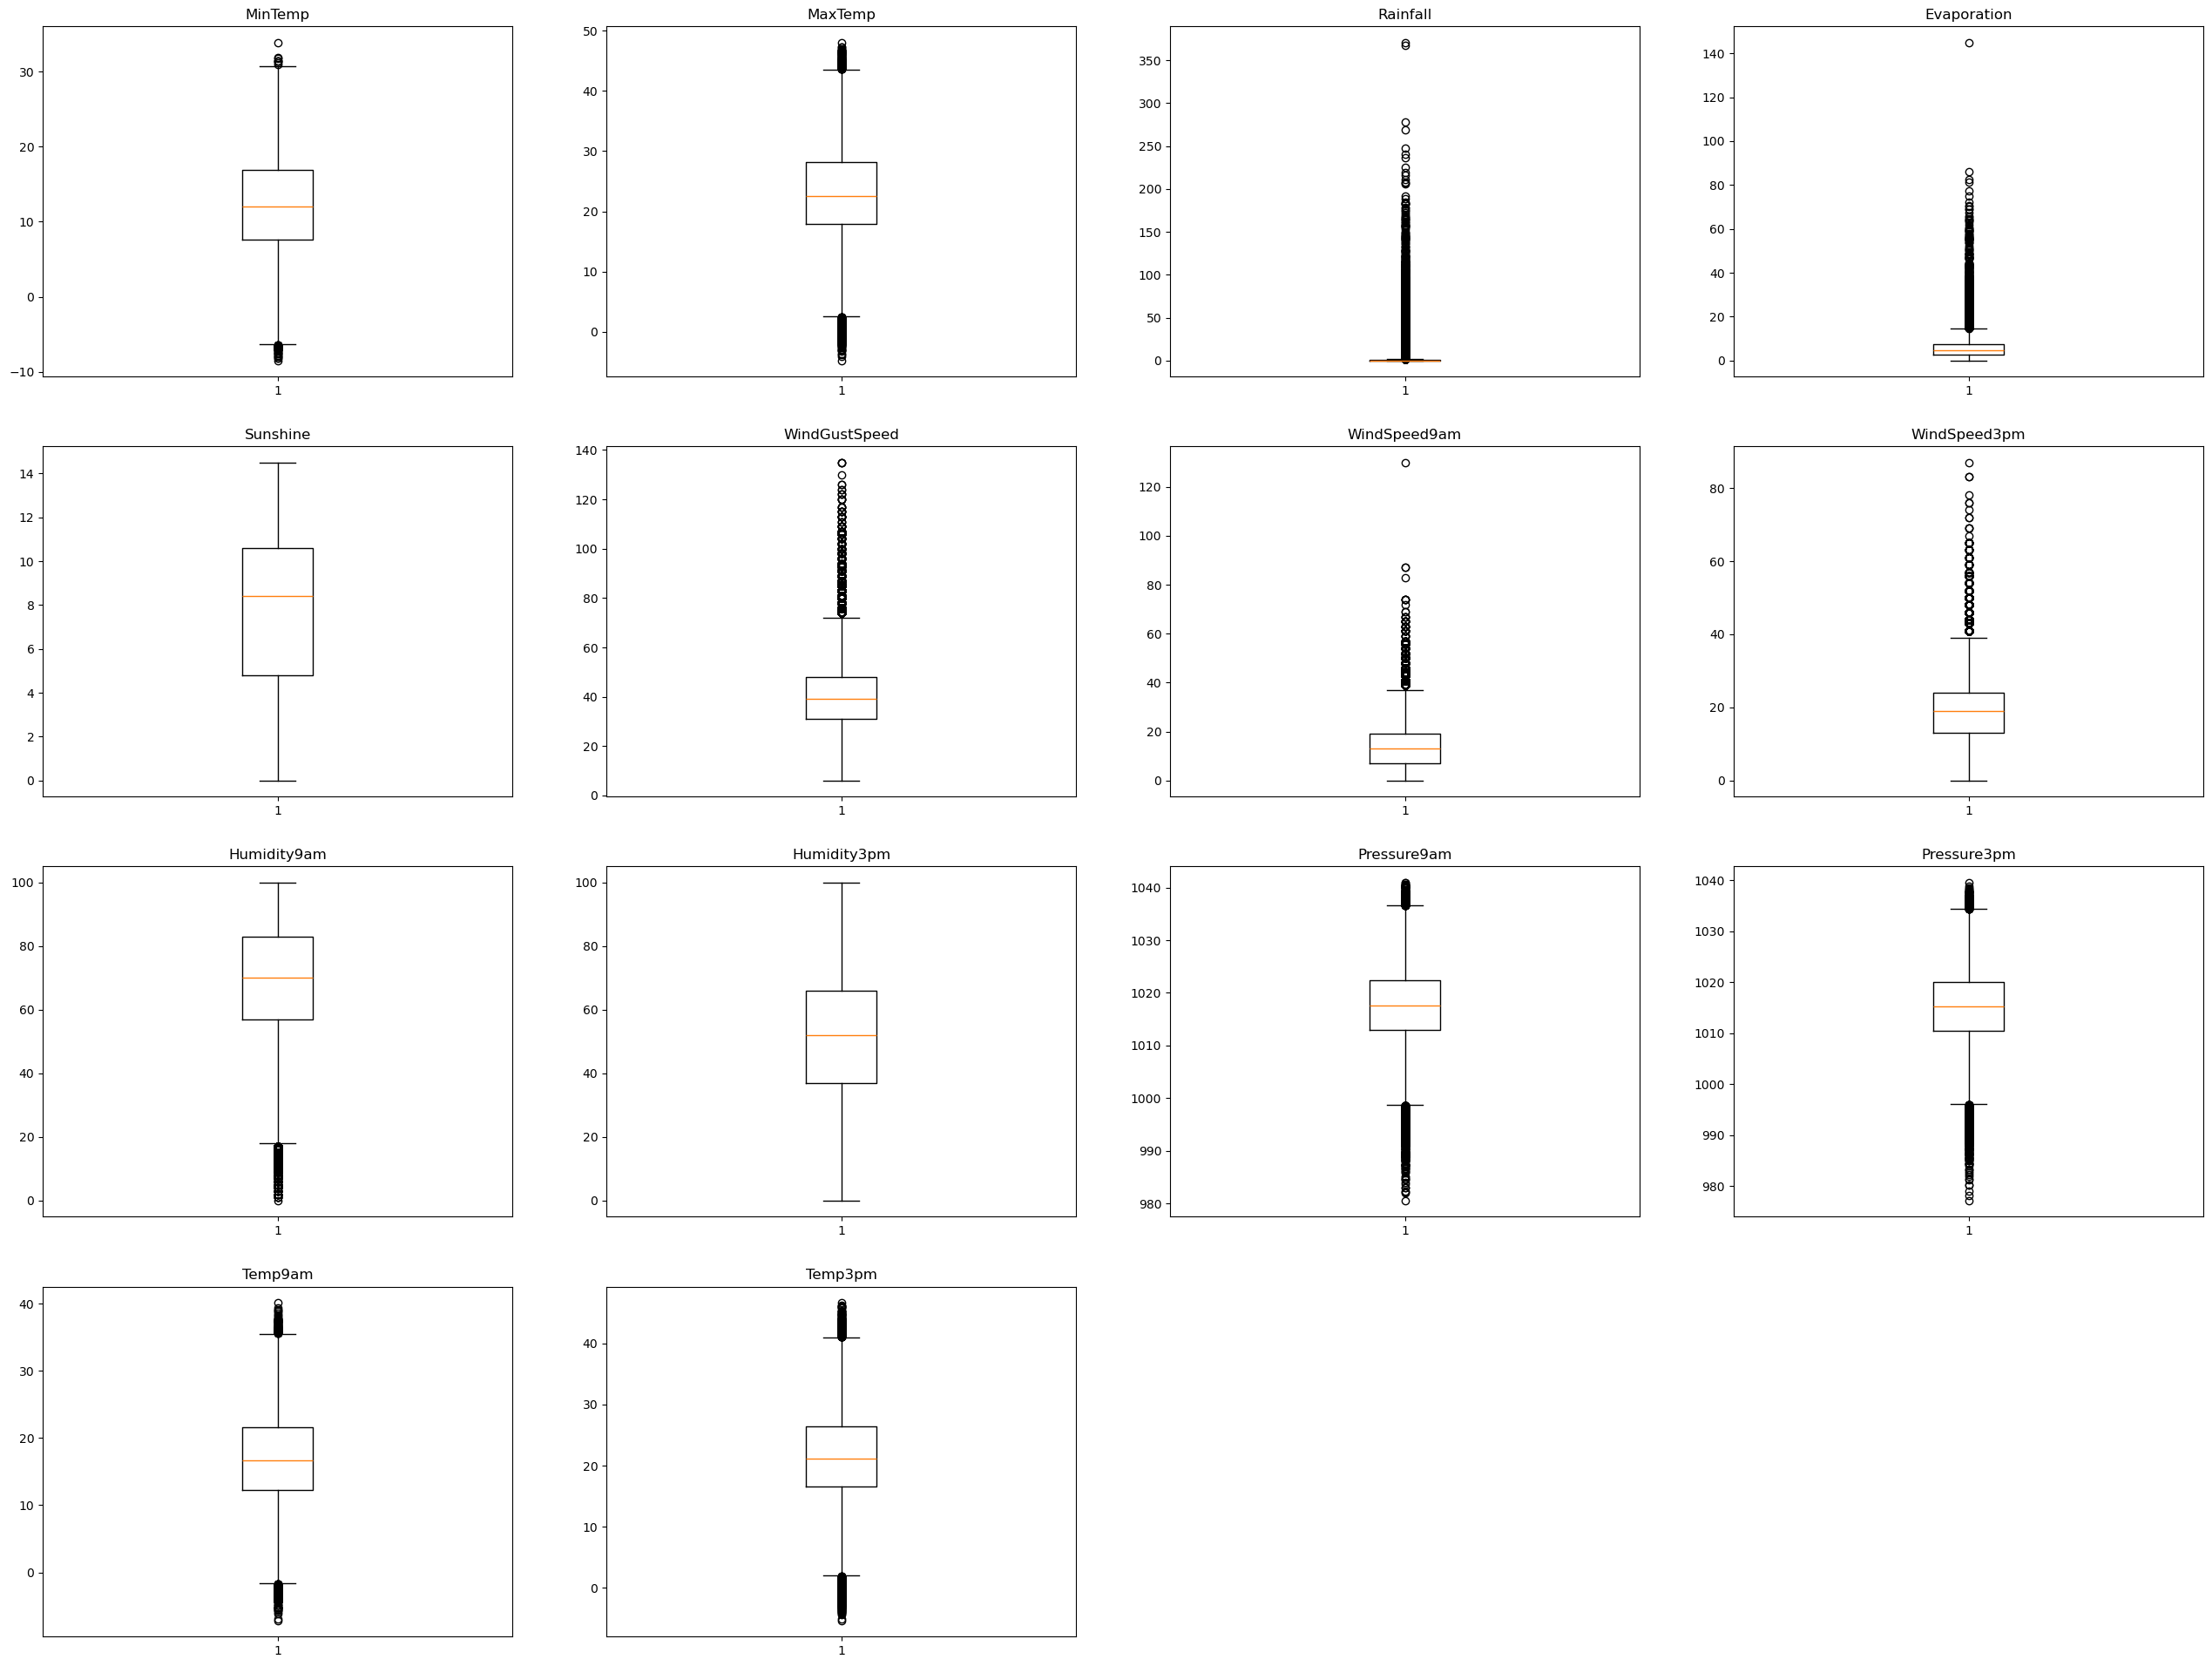

In [21]:
# Prints a boxplot matrix 4 by 4
boxplot_matrix(df_eda, 4, 4)

### 3.2 Univariate Analysis

#### Target Variable
The target variable RainTomorrow exhibits a clear imbalance, with approximately 75.8% of observations labeled as No rain and 21.9% as Rain (2.25% of values are missing). This distribution reflects typical meteorological conditions, where there are substantially more non-rainy days than rainy days. We therefore assume a realistic measurement process and rather little amount of artifacts. The relatively small proportion of missing values suggests that the target variable is largely complete. However, these observations should be handled during preprocessing.

Furthermore the above mentioned imbalance between the two categories has important implications for the modeling and accuracy evaluation. A model with such imbalance would already achieve a high accuracy (75,8 %), by just predicting No Rain for every single day. Consequently, evaluation should rely on imbalance-aware metrics such as F1-score. In addition, stratification should be applied when splitting the data into train and test sets. This is essential to obtain stable performance estimates and to avoid biased model evaluation.

=== Target report: RainTomorrow ===
Rows: 145460
Missing: 3267 (2.25%)

Counts:
RainTomorrow
No     110316
Yes     31877
NaN      3267
Name: count, dtype: int64

Percentages:
RainTomorrow
No     75.84%
Yes    21.91%
NaN     2.25%
Name: count, dtype: object


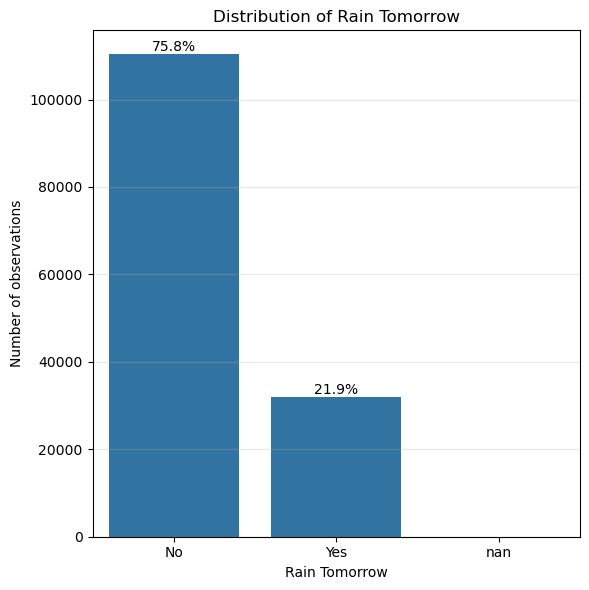

In [22]:
# Calls the function for the target variable report
univariate_target_report(df_eda, target)

#### Feature Distribution Overview

The histogram matrix shows meteorologically plausible distribution patterns across all numerical features. In the following, all distrbutions are shortly described.

Temperature variables (MinTemp, Temp9am, Temp3pm, MaxTemp) are approximately symmetric and unimodal, resemble near-normal distributions with moderate spread. This indicates stable measurement behavior and gradual variability across seasons.

Rainfall is strongly right-skewed with a large mass near zero and a long tail of extreme values, confirming its episodic nature and explaining its high outlier share.

Evaporation shows a moderately right-skewed distribution with most observations at low values and occasional higher extremes.

Sunshine shows a bounded, asymmetric distribution with higher density toward larger values, reflecting the natural upper limit of daily sunshine hours. The shape suggests a smooth transition between cloudy and clear days rather than sharp extremes.

Wind-related variables (WindGustSpeed, WindSpeed9am, WindSpeed3pm) are right-skewed with long but thinning tails. Most observations cluster at lower to moderate wind speeds, while high-speed events occur infrequently but remain meaningful. Wind gusts speed shows the widest spread, consistent with their higher variability and outlier share. Wind speed observations in the morning (9am) tend to be lower, while wind speed observations in the afternoon (3pm) tend to be more moderate. This pattern indicates a systematic increase in wind speed throughout the day.

Humidity variables (Humidity9am, Humidity3pm) are bounded between 0 and 100 (%) and show moderately skewed distributions, with higher densities at mid-to-high humidity levels. The shape reflects diurnal differences and saturation effects, while the absence of heavy tails is consistent with their low outlier rates. The shift from rather high humidity values in the morning (9am), to rather moderate humidity values in the afternoon (3pm), indicates that a systematic decrease in humidity happens throughout the day.

Pressure variables (Pressure9am, Pressure3pm) exhibit very narrow, near-normal distributions centered around standard atmospheric pressure. The tight clustering and minimal tails indicate high measurement stability and explain the extremely low proportion of detected outliers. There is an almost imperceptible shift from higher to more moderate values between the pressure observations in the morning (9am) and the pressure readings in the afternoon (3pm).

Overall, the histogram matrix confirms that most variables are well-behaved and physically constrained, while rainfall and wind-related features exhibit naturally skewed distributions driven by episodic extreme events. This supports feature-specific preprocessing strategies rather than uniform transformations or outlier removal.

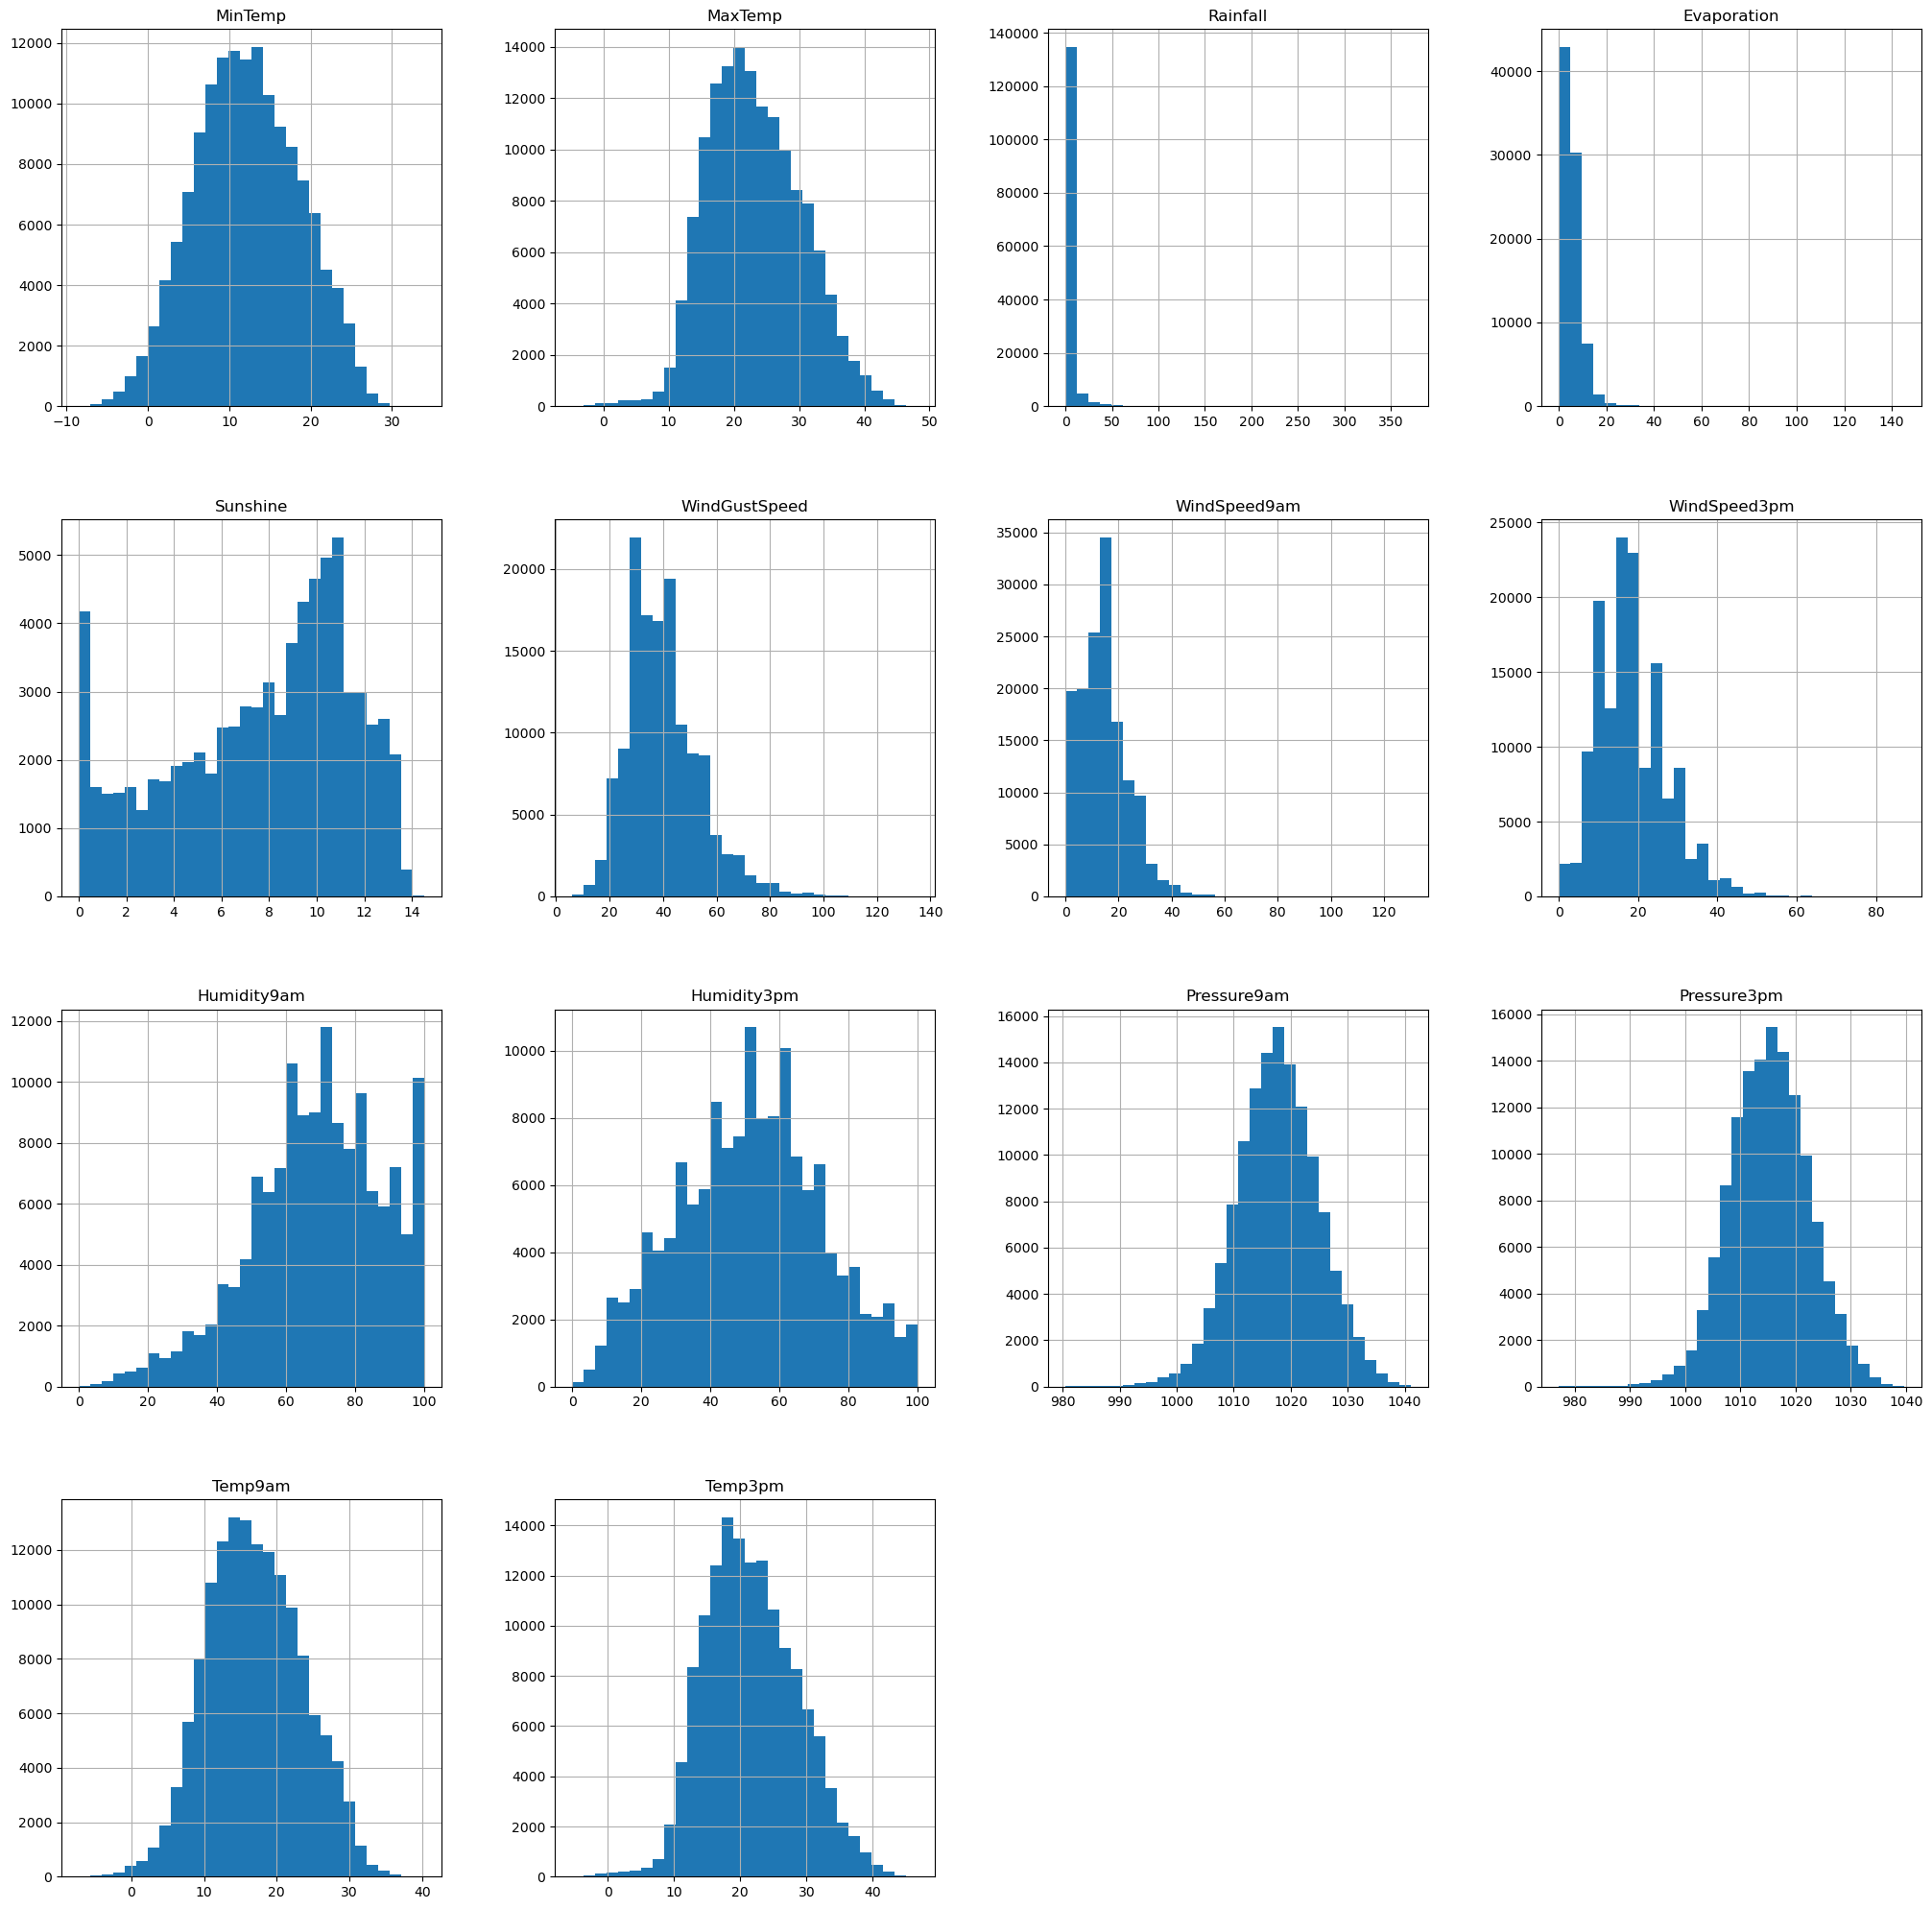

In [23]:
# Prints a histogram matrix, to show all distributions in an overview.
df.hist(figsize=(25, 25),bins=30)
plt.show()

To allow an even better comparison between intraday changes within feature groups (wind, humidity, pressure, cloud, temp), we visualize again in a second plot. This visualization groups numerical diurnal pair, defines the same scale and arranges them column-wise to ensure comparability.

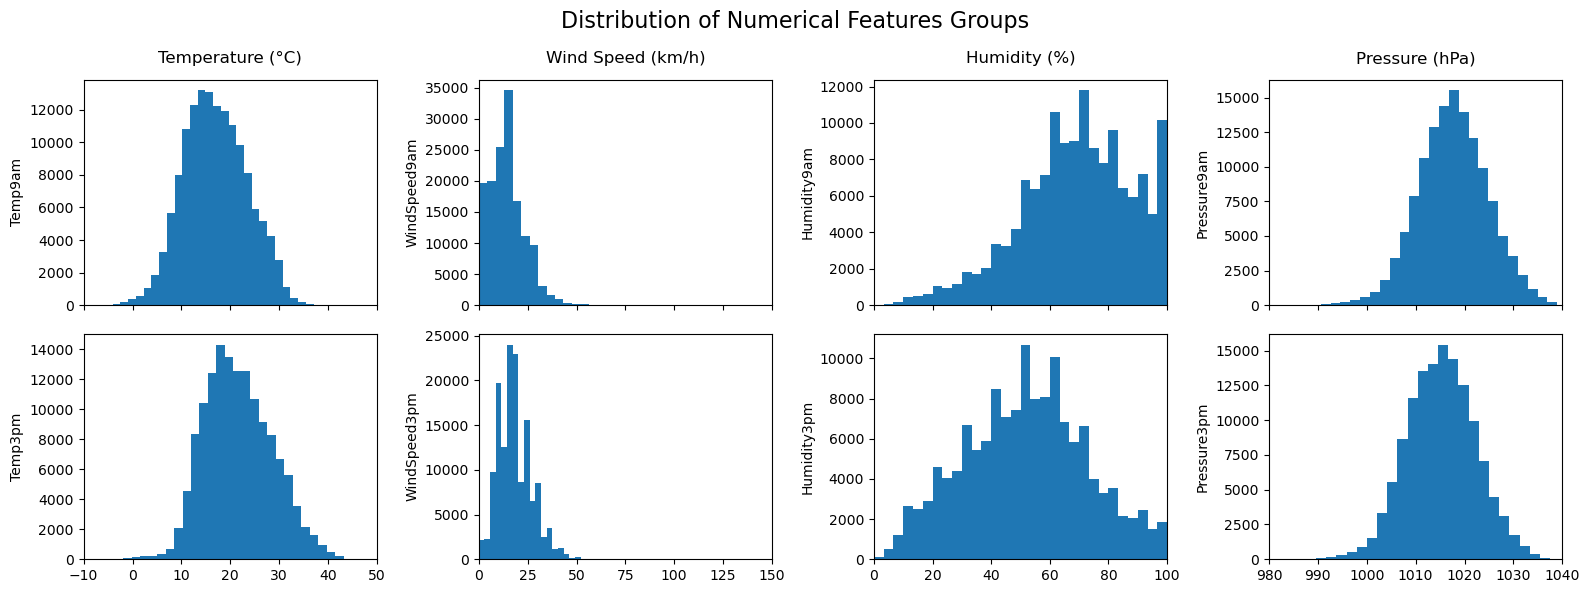

In [24]:
# This combines the diurnal pairs and shows a comparable matrix plot. Each column represents one feature group, while rows represent the specific daytime (9am and 3pm). Axis scales are shared within each column to avoid misleading visual effects due to automatic scaling.

# Defines the diurnal variable pairs.
groups = {
    "Temperature (°C)": {
        "cols": ["Temp9am", "Temp3pm"],
        "xlim": (-10, 50)
    },
    "Wind Speed (km/h)": {
        "cols": ["WindSpeed9am", "WindSpeed3pm"],
        "xlim": (0, 150)
    },
    "Humidity (%)": {
        "cols": ["Humidity9am", "Humidity3pm"],
        "xlim": (0, 100)
    },
    "Pressure (hPa)": {
        "cols": ["Pressure9am", "Pressure3pm"],
        "xlim": (980, 1040)
    }
}

# Determines grid dimensions. The number of columns equals the number of variable groups, while the number of rows equals the maximum group size.
n_cols = 4
max_rows = 2

# Creates a grid of subplots.
# sharex="col" ensures that all plots within a group use the same x-axis scale.
fig, axes = plt.subplots(
    nrows=max_rows,
    ncols=n_cols,
    figsize=(4 * n_cols, 3 * max_rows),
    sharex="col"
)

# Iterate over each variable group and fills one column at a time.
for col_idx, (group_name, cfg) in enumerate(groups.items()):
    cols = cfg["cols"]
    xlim = cfg["xlim"]

    # Assigns the group title to the first row of each column. This visually separates the physical variable groups.
    axes[0, col_idx].set_title(group_name, fontsize=12, pad=12)

    # Plot histograms for each feature within the current group.
    for row_idx in range(max_rows):
        ax = axes[row_idx, col_idx]

        if row_idx < len(cols):
            feature = cols[row_idx]

            # Plot histogram of the current feature. Missing values are dropped to avoid plotting artefacts.
            ax.hist(df[feature].dropna(), bins=30)

            # Set a fixed x-axis range for the entire group. This ensures direct comparability across features in the same group.
            ax.set_xlim(xlim)

            # Use the y-axis label to indicate the feature name.
            ax.set_ylabel(feature)

            # Remove x-axis labels for a cleaner layout; scale interpretation is provided via axis limits and group titles.
            ax.set_xlabel("")

# Adds a global title to contextualize the visualization.
plt.suptitle(
    "Distribution of Numerical Features Groups",
    fontsize=16
)

# Adjusts spacing to prevent overlap between subplots and titles.
plt.tight_layout()
plt.show()

#### Categorical Variables Analysis
Categorical variable analysis aims to understand the distribution, prevalence, and data quality of non-numeric features within the dataset. By examining category frequencies, missing values, and class imbalances, this step provides insights into dominant patterns, potential biases, and limitations that may deliver implication for further analysis and model strategies.

##### Location
Location shows that weather stations are not evenly distributed across Australia. Observations are strongly concentrated along the coastal and urban regions, particularly in the east, southeast, southwest, and northern coastline, while large parts of the central and inland areas are sparsely covered or not represented.

This spatial pattern reflects population density and infrastructure availability rather than climatic conditions. As a result, the dataset exhibits a geographical sampling bias, which should be considered when interpreting spatial patterns and model results, especially for inland regions with limited sensor coverage.

=== Location (categorical) ===
Rows: 145460
Missing: 0 (0.0%)
Unique values: 49

Top 15 categories:
Location
Canberra        3436
Sydney          3344
Adelaide        3193
Darwin          3193
Hobart          3193
Perth           3193
Melbourne       3193
Brisbane        3193
Albury          3040
MountGinini     3040
GoldCoast       3040
Wollongong      3040
MountGambier    3040
Launceston      3040
AliceSprings    3040
Name: count, dtype: Int64


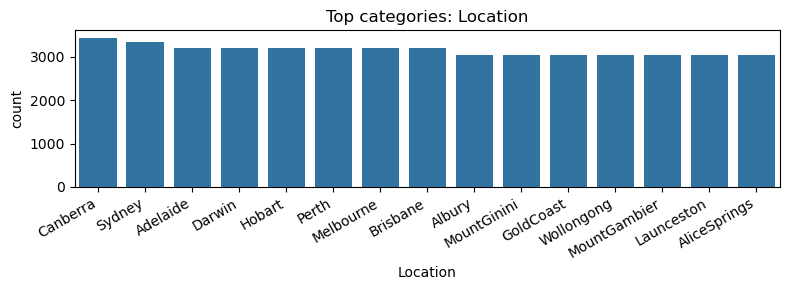

In [25]:
# Calls the function for the univariate categorical report.
univariate_report_categorical(df_eda,col="Location",top_k=15)

In [26]:
# If the previously loaded geocoded dataframe is empty (e.g., due to failed or skipped API requests), load the previously saved local CSV file as a fallback. This ensures reproducibility and avoids repeated calls to the geocoding service.
if df_geocodes.empty:
    df_geocodes = pd.read_csv("df_geocodes.csv")

In [27]:
# Removes rows without valid geographic coordinates.
# Locations with missing latitude or longitude cannot be visualized on the map.
df_geocodes = df_geocodes.dropna(subset=["Latitude", "Longitude"]).copy()

# Create a base map centered on Australia. The initial zoom level is chosen to show the full continent.
map_locations_australia = folium.Map(location=[-25.2744, 133.7751], zoom_start=5)

# Add each location as a marker on the map.
# Tooltip shows the location name on hover, while the popup displays the location name and the corresponding average rainfall value.
for _, row in df_geocodes.iterrows():
    folium.Marker(
        location=[row["Latitude"], row["Longitude"]],
        tooltip=row["Location"],
        popup=(
            f"<strong>{row["Location"]}</strong><br>"
            f"Rainfall: {row["Rainfall"]:.2f}"
        ),
        icon=folium.Icon(color = "red", icon="map-marker", prefix="fa")
    ).add_to(map_locations_australia)

# Save the interactive map as an HTML file for later use (e.g., presentation).
map_locations_australia.save("locations.html")

# Display the map in the notebook.
map_locations_australia

##### Wind Gust Direction
WindGustDir are not evenly distributed across directions but are instead concentrated in specific sectors. Westerly and southerly directions occur most frequently, while easterly and north-easterly directions are comparatively less common. Overall, the univariate analysis indicates that wind gust directions exhibit a clear directional structure.

=== WindGustDir (categorical) ===
Rows: 145460
Missing: 10326 (7.1%)
Unique values: 17

Top 17 categories:
WindGustDir
<NA>    10326
W        9915
SE       9418
N        9313
SSE      9216
E        9181
S        9168
WSW      9069
SW       8967
SSW      8736
WNW      8252
NW       8122
ENE      8104
ESE      7372
NE       7133
NNW      6620
NNE      6548
Name: count, dtype: Int64


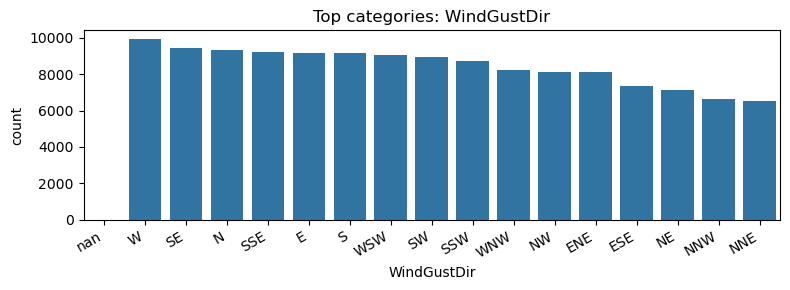

In [28]:
# Calls the function for the univariate categorical report.
univariate_report_categorical(df_eda,col="WindGustDir",top_k=17)

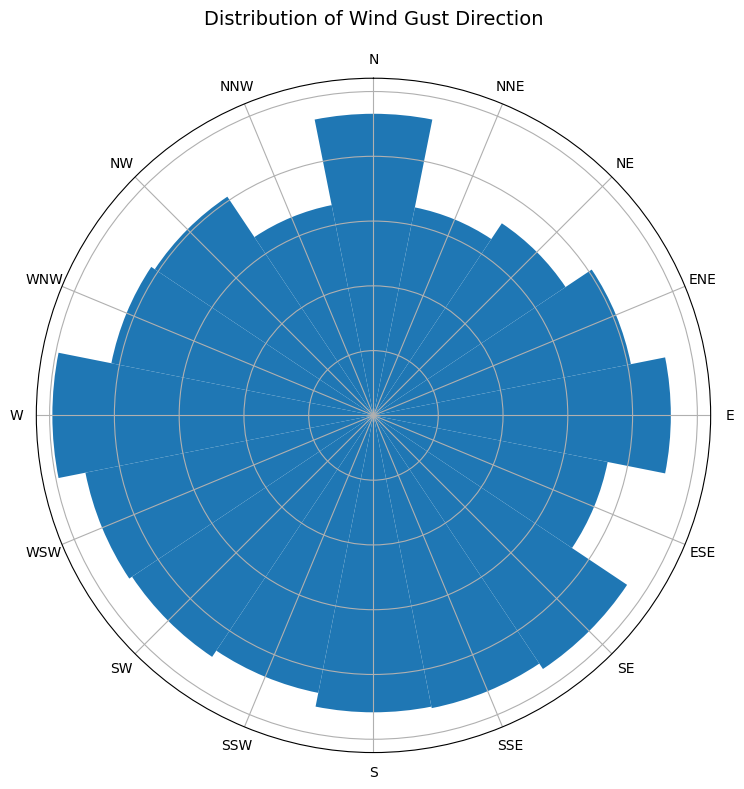

In [29]:
# Define compass order for wind directions
WindGustDir_order = [
    "N", "NNE", "NE", "ENE",
    "E", "ESE", "SE", "SSE",
    "S", "SSW", "SW", "WSW",
    "W", "WNW", "NW", "NNW"
]

# Count occurrences of each wind gust direction
dir_counts = (
    df_eda["WindGustDir"]
    .value_counts()
    .reindex(WindGustDir_order)
    .fillna(0)
)

# Prepare polar coordinates
n_dirs = len(WindGustDir_order)
angles = np.linspace(0, 2 * np.pi, n_dirs, endpoint=False)
heights = dir_counts.values
width = 2 * np.pi / n_dirs

# Create polar plot
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

ax.bar(angles, heights, width=width, align="center")

# Compass-style orientation
ax.set_theta_zero_location("N")   # North at the top
ax.set_theta_direction(-1)        # Clockwise rotation

ax.set_xticks(angles)
ax.set_xticklabels(WindGustDir_order)
ax.set_yticklabels([])

ax.set_title(
    "Distribution of Wind Gust Direction",
    fontsize=14,
    pad=20
)

plt.tight_layout()
plt.show()

##### Wind Direction 9am
WindDir9am shows a clear directional structure rather than a uniform pattern. Winds are most frequently observed from the northern sector. Subsequently eastern, and southern sectors are most frequently observed, while north-easterly and west-south-westerly directions occur less often. Overall, the univariate analysis indicates that morning wind directions follow stable prevailing patterns, likely driven by meterological reasons rather than random variation.

=== WindDir9am (categorical) ===
Rows: 145460
Missing: 10566 (7.3%)
Unique values: 17

Top 17 categories:
WindDir9am
N       11758
<NA>    10566
SE       9287
E        9176
SSE      9112
NW       8749
S        8659
W        8459
SW       8423
NNE      8129
NNW      7980
ENE      7836
NE       7671
ESE      7630
SSW      7587
WNW      7414
WSW      7024
Name: count, dtype: Int64


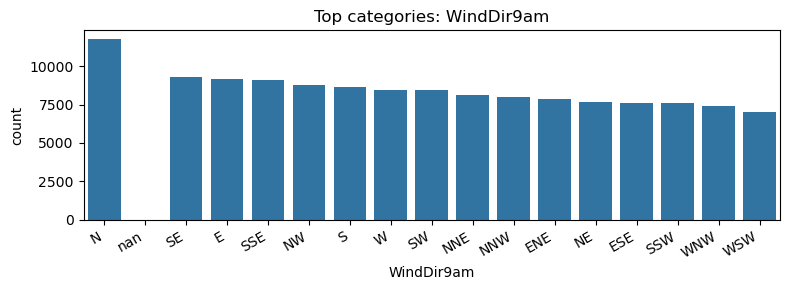

In [30]:
# Calls the function for the univariate categorical report.
univariate_report_categorical(df_eda,col="WindDir9am",top_k=17)

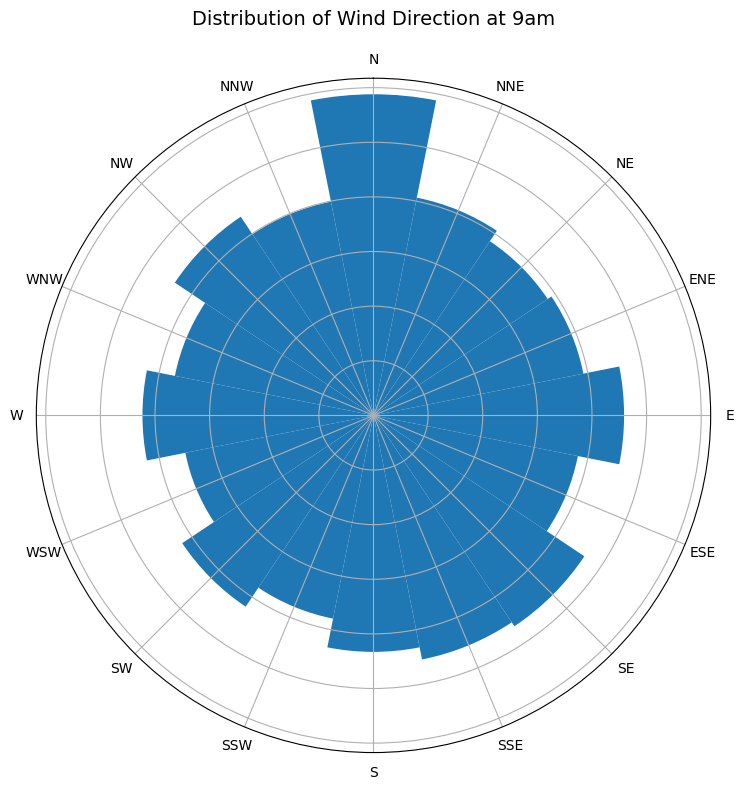

In [31]:
# Define compass order for wind directions
WindDir9am_order = [
    "N", "NNE", "NE", "ENE",
    "E", "ESE", "SE", "SSE",
    "S", "SSW", "SW", "WSW",
    "W", "WNW", "NW", "NNW"
]

# Count occurrences of each wind gust direction
dir_counts = (
    df_eda["WindDir9am"]
    .value_counts()
    .reindex(WindDir9am_order)
    .fillna(0)
)

# Prepare polar coordinates
n_dirs = len(WindDir9am_order)
angles = np.linspace(0, 2 * np.pi, n_dirs, endpoint=False)
heights = dir_counts.values
width = 2 * np.pi / n_dirs

# Create polar plot
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

ax.bar(angles, heights, width=width, align="center")

# Compass-style orientation
ax.set_theta_zero_location("N")   # North at the top
ax.set_theta_direction(-1)        # Clockwise rotation

ax.set_xticks(angles)
ax.set_xticklabels(WindDir9am_order)
ax.set_yticklabels([])

ax.set_title(
    "Distribution of Wind Direction at 9am",
    fontsize=14,
    pad=20
)

plt.tight_layout()
plt.show()

##### Wind Direction 3pm
WindDir3pm shows a stronger concentration in the southern, south-eastern, and western sectors. Compared to the morning distribution, wind directions in the afternoon appear more focused and intensified, with a noticeable shift toward southerly and westerly flows. Furthermore, the 9am wind directions are more evenly spread across directions. This comparison suggests a systematic diurnal shift in wind patterns, where winds tend to rotate and strengthen toward southern and western directions as the day progresses, likely driven by daytime heating and atmospheric mixing.

=== WindDir3pm (categorical) ===
Rows: 145460
Missing: 4228 (2.9%)
Unique values: 17

Top 17 categories:
WindDir3pm
SE      10838
W       10110
S        9926
WSW      9518
SSE      9399
SW       9354
N        8890
WNW      8874
NW       8610
ESE      8505
E        8472
NE       8263
SSW      8156
NNW      7870
ENE      7857
NNE      6590
<NA>     4228
Name: count, dtype: Int64


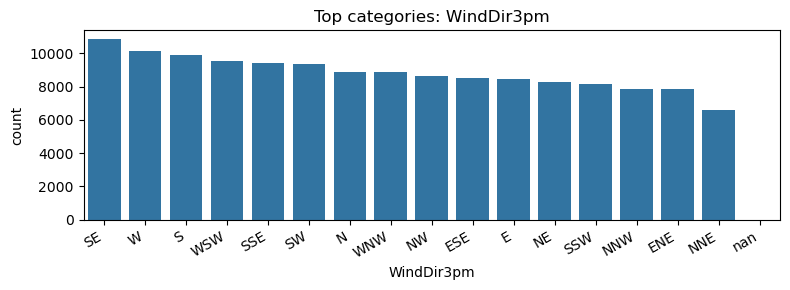

In [32]:
# Calls the function for the univariate categorical report.
univariate_report_categorical(df_eda,col="WindDir3pm",top_k=17)

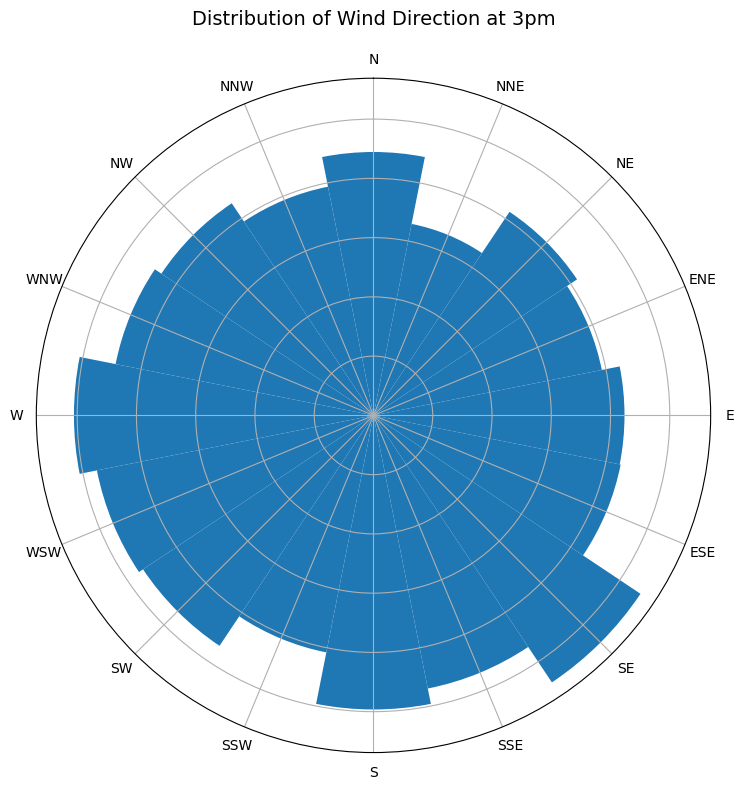

In [33]:
# Define compass order for wind directions
WindDir3pm_order = [
    "N", "NNE", "NE", "ENE",
    "E", "ESE", "SE", "SSE",
    "S", "SSW", "SW", "WSW",
    "W", "WNW", "NW", "NNW"
]

# Count occurrences of each wind gust direction
dir_counts = (
    df_eda["WindDir3pm"]
    .value_counts()
    .reindex(WindDir3pm_order)
    .fillna(0)
)

# Prepare polar coordinates
n_dirs = len(WindDir3pm_order)
angles = np.linspace(0, 2 * np.pi, n_dirs, endpoint=False)
heights = dir_counts.values
width = 2 * np.pi / n_dirs

# Create polar plot
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

ax.bar(angles, heights, width=width, align="center")

# Compass-style orientation
ax.set_theta_zero_location("N")   # North at the top
ax.set_theta_direction(-1)        # Clockwise rotation

ax.set_xticks(angles)
ax.set_xticklabels(WindDir3pm_order)
ax.set_yticklabels([])

ax.set_title(
    "Distribution of Wind Direction at 3pm",
    fontsize=14,
    pad=20
)

plt.tight_layout()
plt.show()

##### Rain Today
RainToday shows a clear class imbalance, with the majority of observations labeled as No rain (approximately three quarters of the data), while Rain occurs substantially less frequently. A small proportion of values is missing (around 2%), indicating that the variable is largely complete. This distribution reflects typical weather patterns, where dry days are more common than rainy ones.

=== RainToday (categorical) ===
Rows: 145460
Missing: 3261 (2.2%)
Unique values: 3

Top 10 categories:
RainToday
No      110319
Yes      31880
<NA>      3261
Name: count, dtype: Int64


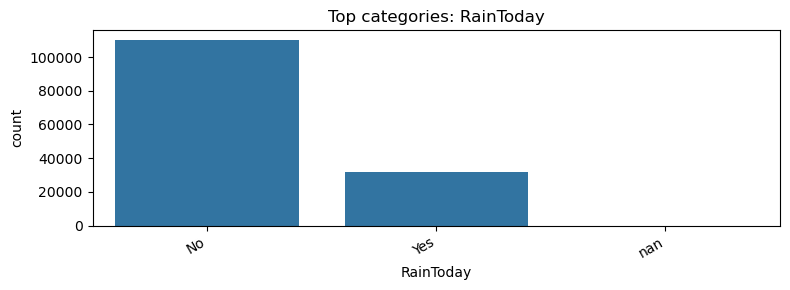

In [34]:
# Calls the function for the univariate categorical report.
univariate_report_categorical(df_eda,col="RainToday")

##### Cloud 9am
Cloud9am shows a substantial proportion of missing values, indicating that early-morning cloud cover measurements are not consistently available across all observations. Among the recorded values, higher cloud cover levels (notably categories around 7–8 oktas) occur more frequently than very low values, suggesting that mornings are often partially to heavily overcast rather than completely clear. Overall, the distribution reflects both data availability limitations and a tendency toward moderate to high cloudiness in the morning hours.

=== Cloud9am (categorical) ===
Rows: 145460
Missing: 55888 (38.4%)
Unique values: 11

Top 10 categories:
Cloud9am
<NA>    55888
7.0     19972
1.0     15687
8.0     14697
0.0      8642
6.0      8171
2.0      6500
3.0      5914
5.0      5567
4.0      4420
Name: count, dtype: Int64


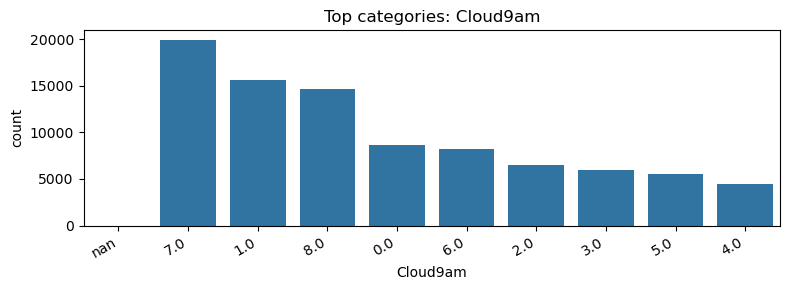

In [35]:
# Calls the function for the univariate categorical report.
univariate_report_categorical(df_eda,col="Cloud9am")

#### Numerical Variables Analysis
Numerical variable analysis focuses on examining the distribution, range, and variability of continuous features in the dataset. By assessing central tendencies, missingness, skewness, and the presence of outliers, this step helps identify underlying data structures, detect anomalies, and delivers implications for further analysis and model strategies.

##### MinTemp
MinTemp shows that the variable is almost fully complete, with nearly no missing values. The distribution is approximately symmetric and bell-shaped, indicating a well-behaved temperature pattern. The boxplot confirms a low presence of extreme values, with no outliers detected under the IQR rule, suggesting high data quality and suitability for direct use in modeling.

=== MinTemp (numeric) ===
Rows: 145460
Missing: 1485 (1.0%)

Descriptive statistics:
count    143975.000000
mean         12.194034
std           6.398495
min          -8.500000
25%           7.600000
50%          12.000000
75%          16.900000
max          33.900000
Name: MinTemp, dtype: float64

Skewness: 0.02


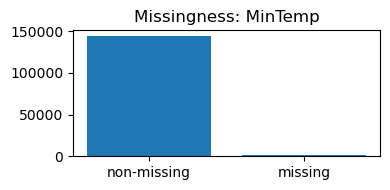

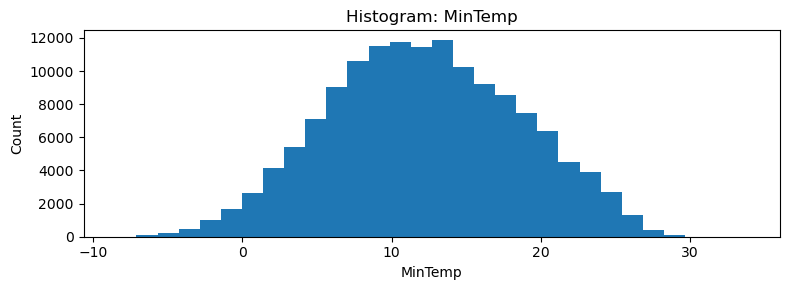

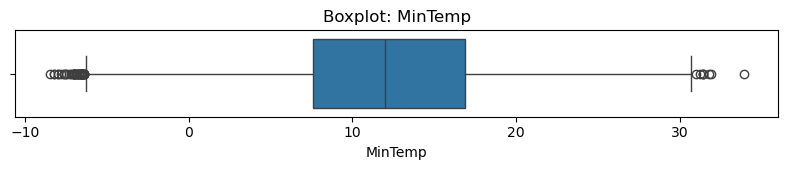

Outliers (IQR rule): 0.0%


In [36]:
# Calls the function for the univariate numerical report.
univariate_report_numerical(df_eda,col="MinTemp")

##### Maximum Temperature
MaxTemp shows that the variable is almost fully complete, with nearly no missing values. The distribution is approximately symmetric and bell-shaped, indicating a well-behaved temperature pattern. The boxplot confirms a low presence of extreme values, with almost no outliers detected under the IQR rule, suggesting high data quality and suitability for direct use in modeling.

=== MaxTemp (numeric) ===
Rows: 145460
Missing: 1261 (0.9%)

Descriptive statistics:
count    144199.000000
mean         23.221348
std           7.119049
min          -4.800000
25%          17.900000
50%          22.600000
75%          28.200000
max          48.100000
Name: MaxTemp, dtype: float64

Skewness: 0.22


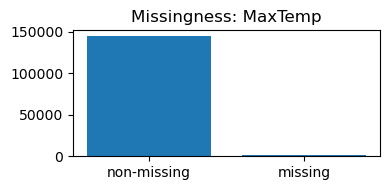

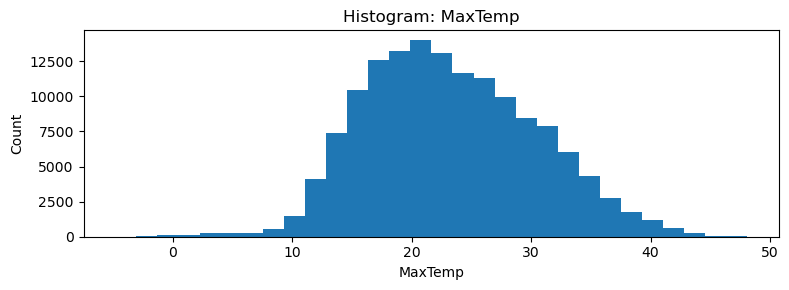

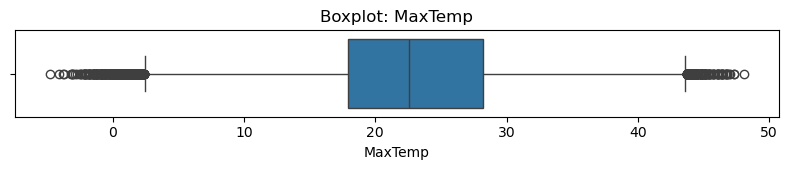

Outliers (IQR rule): 0.3%


In [37]:
# Calls the function for the univariate numerical report.
univariate_report_numerical(df_eda,col="MaxTemp")

##### Rainfall
Rainfall shows a highly right-skewed distribution, with most observations concentrated at very low or zero values and a small number of extreme rainfall events extending far into the upper range. This is reflected in the high skewness and the large maximum value. While missing values are negligible, a substantial proportion of observations (about 18%) are classified as outliers under the IQR rule, indicating that extreme rainfall events are a structural characteristic of the variable. Consequently, rainfall requires special handling in modeling, such as transformation or separate treatment of zero and extreme values.

=== Rainfall (numeric) ===
Rows: 145460
Missing: 3261 (2.2%)

Descriptive statistics:
count    142199.000000
mean          2.360918
std           8.478060
min           0.000000
25%           0.000000
50%           0.000000
75%           0.800000
max         371.000000
Name: Rainfall, dtype: float64

Skewness: 9.84


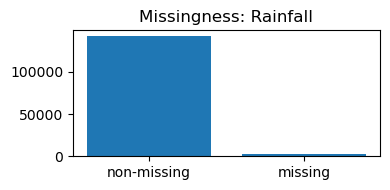

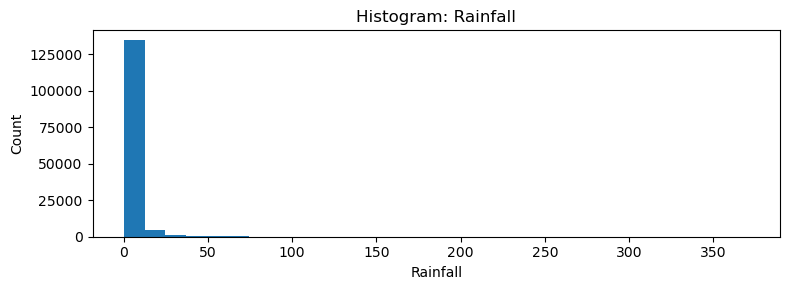

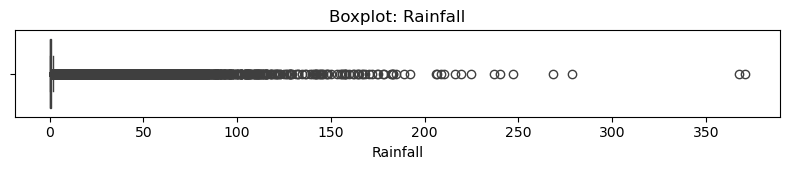

Outliers (IQR rule): 17.6%


In [38]:
# Calls the function for the univariate numerical report.
univariate_report_numerical(df_eda,col="Rainfall")

=== Rainfall (numeric) ===
Rows: 116621
Missing: 0 (0.0%)

Descriptive statistics:
count    116621.000000
mean          0.155433
std           0.392923
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           2.000000
Name: Rainfall, dtype: float64

Skewness: 2.99


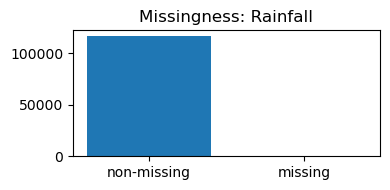

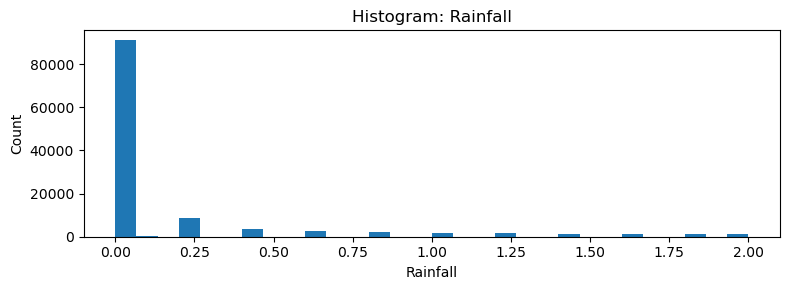

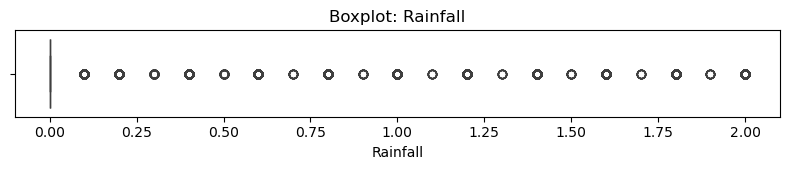

IQR is zero → outlier detection not meaningful.


In [39]:
# Since the outlier share of the Rainfall variable exceeds the predefined 2% threshold (as defined in the EDA introduction), IQR-based capping is applied for visualization purposes. To improve interpretability, extreme rainfall values are identified using the one-sided 1.5 × IQR rule and observations above the upper threshold are excluded from the plot. This step affects only the visualization and does not modify the original dataset.

# Computes first and third quartiles and the IQR for Rainfall.
q1 = df["Rainfall"].quantile(0.25)
q3 = df["Rainfall"].quantile(0.75)
iqr = q3 - q1

# Defines the upper bound for extreme rainfall values (one-sided IQR capping).
upper = q3 + 1.5 * iqr

# Runs the univariate report on the capped dataset to obtain a more interpretable distribution.
univariate_report_numerical(df_eda[df_eda["Rainfall"] <= upper],col="Rainfall")

##### Evaporation
Evaporation reveals a right-skewed distribution, with most observations concentrated at low to moderate values and a long tail of higher evaporation levels. This is reflected in the positive skewness and the presence of several extreme values visible in the boxplot. A noticeable proportion of values is missing, indicating incomplete measurement coverage. While most evaporation values lie within a plausible range, the heavy tail suggests that extreme evaporation events are a recurring but infrequent phenomenon and should be treated carefully in modeling.

=== Evaporation (numeric) ===
Rows: 145460
Missing: 62790 (43.2%)

Descriptive statistics:
count    82670.000000
mean         5.468232
std          4.193704
min          0.000000
25%          2.600000
50%          4.800000
75%          7.400000
max        145.000000
Name: Evaporation, dtype: float64

Skewness: 3.76


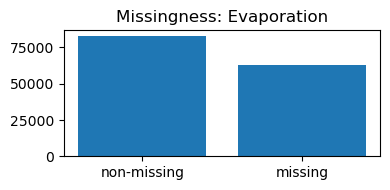

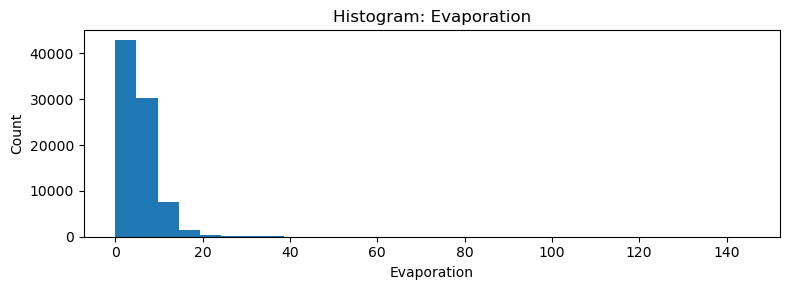

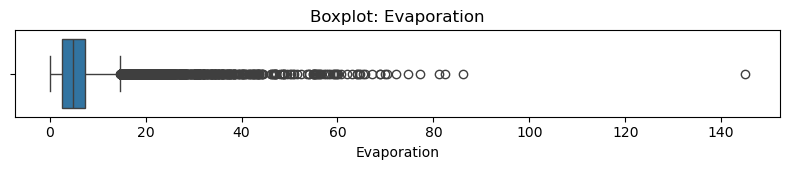

Outliers (IQR rule): 1.4%


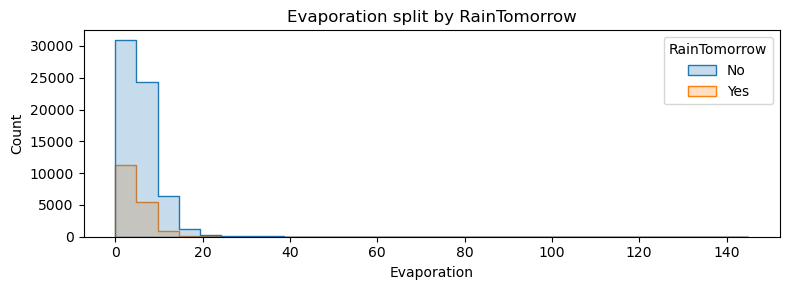

In [40]:
# Calls the function for the univariate numerical report.
univariate_report_numerical(df_eda, col="Evaporation", target="RainTomorrow")

##### Sunshine
Sunshine shows a largely well-behaved distribution, with values concentrated between moderate to high sunshine hours. The histogram indicates a slight left skew, suggesting that days with higher sunshine duration are more common than very low-sunshine days. Although a noticeable share of observations is missing, the recorded values exhibit no outliers under the IQR rule. Overall, sunshine appears to be a reliable numerical variable with a clear central tendency and limited extreme behavior.

=== Sunshine (numeric) ===
Rows: 145460
Missing: 69835 (48.0%)

Descriptive statistics:
count    75625.000000
mean         7.611178
std          3.785483
min          0.000000
25%          4.800000
50%          8.400000
75%         10.600000
max         14.500000
Name: Sunshine, dtype: float64

Skewness: -0.50


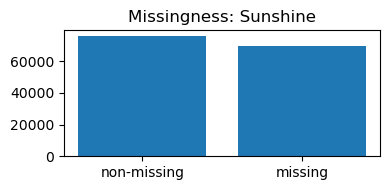

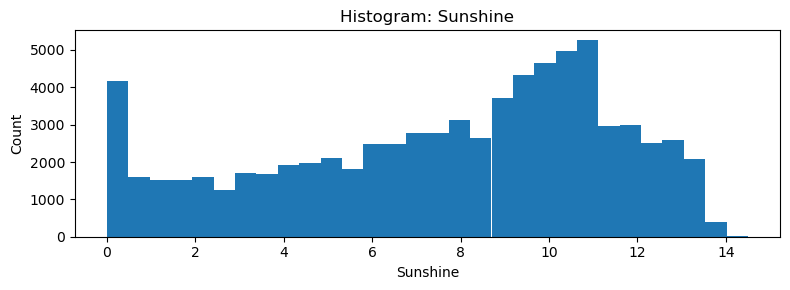

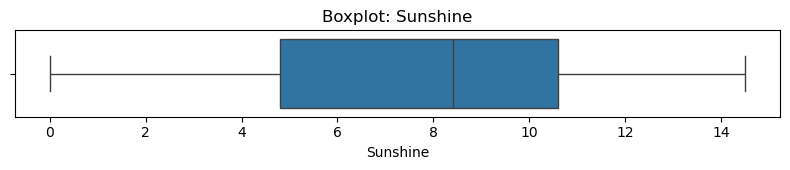

Outliers (IQR rule): 0.0%


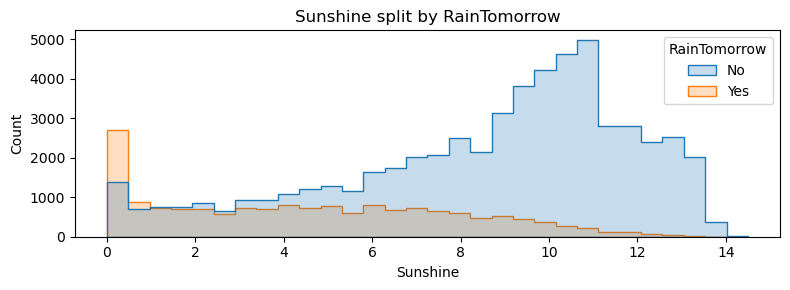

In [41]:
# Calls the function for the univariate numerical report.
univariate_report_numerical(df_eda, col="Sunshine", target="RainTomorrow")

##### Wind Gust Speed
WindGustSpeed shows a right-skewed distribution, with most observations concentrated at moderate wind gust speeds and a long tail toward higher values. Extreme gust events are present but relatively infrequent, as reflected by an outlier share of about 2% under the IQR rule. Therefore, we use IQR-based capping in a second visualization. Missing values are limited, indicating good data coverage. Overall, wind gust speed exhibits natural variability with occasional extremes that are meteorologically plausible and should be handled with robust modeling approaches rather than removed.

=== WindGustSpeed (numeric) ===
Rows: 145460
Missing: 10263 (7.1%)

Descriptive statistics:
count    135197.000000
mean         40.035230
std          13.607062
min           6.000000
25%          31.000000
50%          39.000000
75%          48.000000
max         135.000000
Name: WindGustSpeed, dtype: float64

Skewness: 0.87


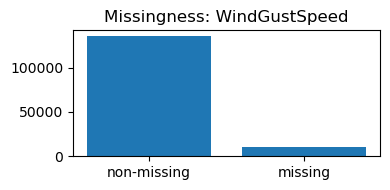

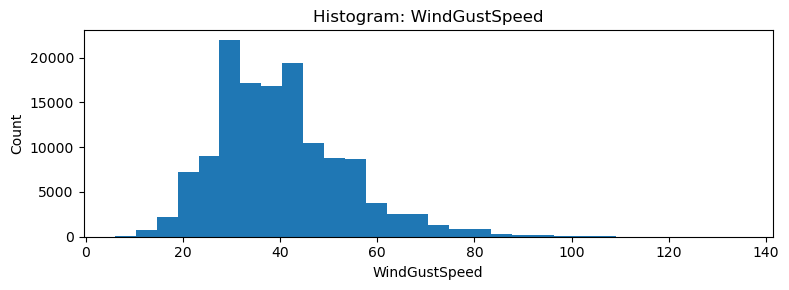

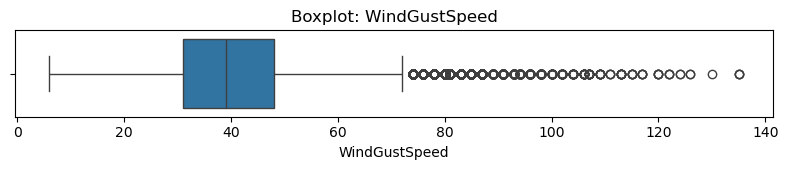

Outliers (IQR rule): 2.1%


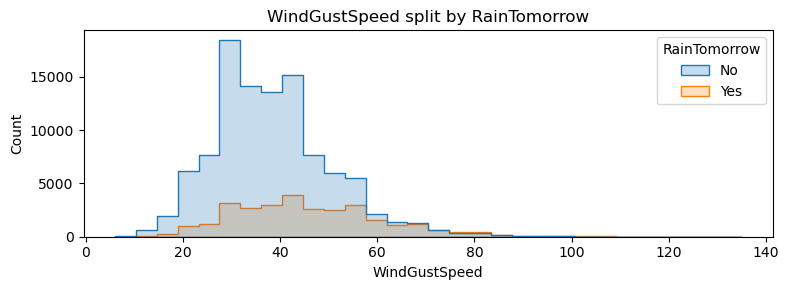

In [42]:
# Calls the function for the univariate numerical report.
univariate_report_numerical(df_eda, col="WindGustSpeed", target="RainTomorrow")

=== WindGustSpeed (numeric) ===
Rows: 132105
Missing: 0 (0.0%)

Descriptive statistics:
count    132105.000000
mean         39.049907
std          12.055309
min           6.000000
25%          31.000000
50%          37.000000
75%          46.000000
max          72.000000
Name: WindGustSpeed, dtype: float64

Skewness: 0.40


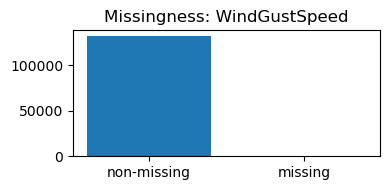

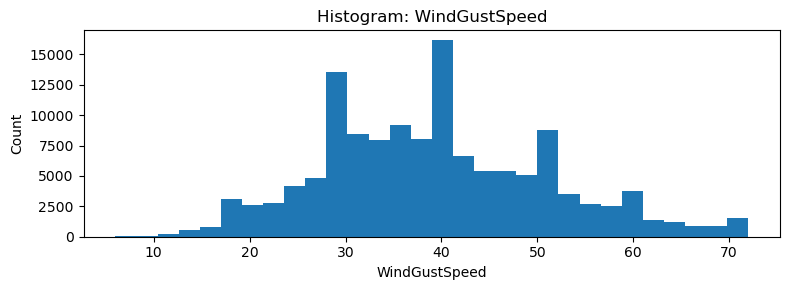

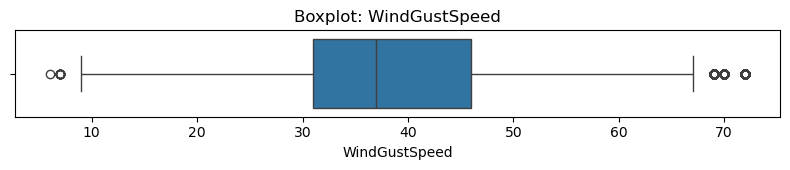

Outliers (IQR rule): 1.8%


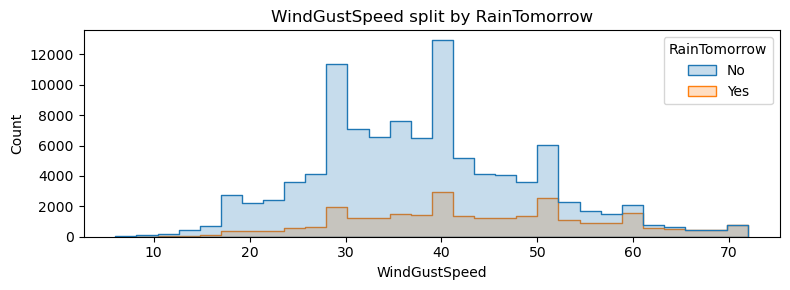

In [43]:
# Since the outlier share of the Rainfall variable exceeds the predefined 2% threshold (as defined in the EDA introduction), IQR-based capping is applied for visualization purposes. To improve interpretability, extreme rainfall values are identified using the one-sided 1.5 × IQR rule and observations above the upper threshold are excluded from the plot. This step affects only the visualization and does not modify the original dataset.

# Computes first and third quartiles and the IQR for Rainfall.
q1 = df["WindGustSpeed"].quantile(0.25)
q3 = df["WindGustSpeed"].quantile(0.75)
iqr = q3 - q1

# Defines the upper bound for extreme rainfall values (one-sided IQR capping).
upper = q3 + 1.5 * iqr

# Runs the univariate report on the capped dataset to obtain a more interpretable distribution.
univariate_report_numerical(df_eda[df_eda["WindGustSpeed"] <= upper], col="WindGustSpeed", target="RainTomorrow")

##### Wind Speed at 9am
WindSpeed9am shows a moderately right-skewed distribution, with most observations concentrated at low to moderate wind speeds typical of morning conditions. Missing values are minimal, indicating good data completeness. A small proportion of higher wind speeds is classified as outliers (about 1% under the IQR rule), reflecting occasional stronger morning winds. Overall, wind speed at 9 am appears stable with limited extremes and a clear central tendency.

=== WindSpeed9am (numeric) ===
Rows: 145460
Missing: 1767 (1.2%)

Descriptive statistics:
count    143693.000000
mean         14.043426
std           8.915375
min           0.000000
25%           7.000000
50%          13.000000
75%          19.000000
max         130.000000
Name: WindSpeed9am, dtype: float64

Skewness: 0.78


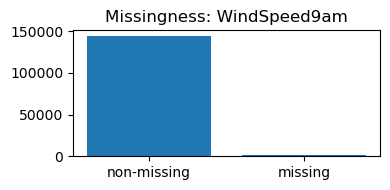

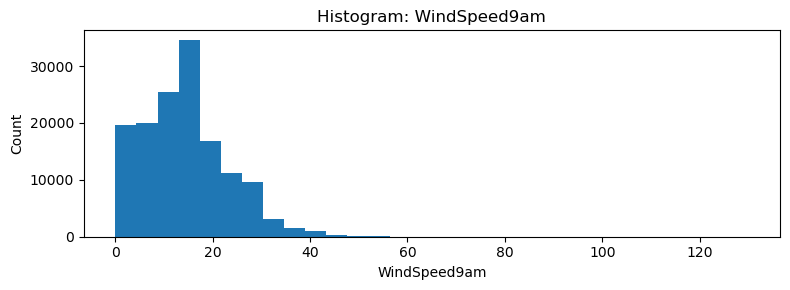

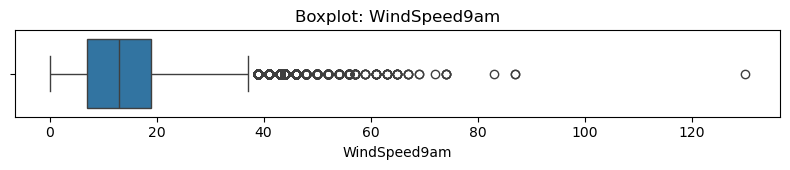

Outliers (IQR rule): 1.2%


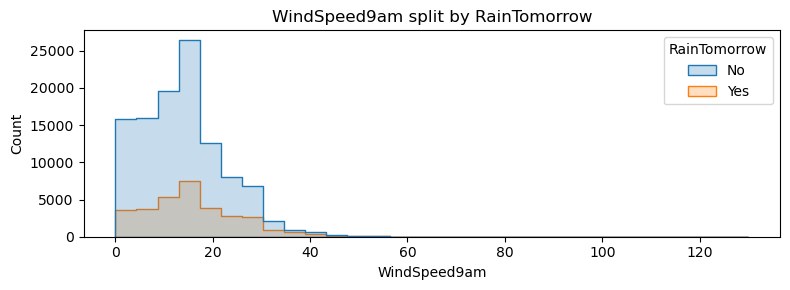

In [44]:
# Calls the function for the univariate numerical report.
univariate_report_numerical(df_eda, col="WindSpeed9am", target="RainTomorrow")

##### Wind Speed at 3pm
WindSpeed3pm shows a moderately right-skewed distribution, with most observations concentrated at higher wind speeds than in the morning, reflecting typical daytime wind intensification. Missing values are negligible, indicating good data completeness. A small share of observations (below 2%) is classified as outliers under the IQR rule, corresponding to occasional strong afternoon winds. Overall, wind speed at 3 pm is more variable than at 9 am but remains well-behaved and meteorologically plausible.

=== WindSpeed3pm (numeric) ===
Rows: 145460
Missing: 3062 (2.1%)

Descriptive statistics:
count    142398.000000
mean         18.662657
std           8.809800
min           0.000000
25%          13.000000
50%          19.000000
75%          24.000000
max          87.000000
Name: WindSpeed3pm, dtype: float64

Skewness: 0.63


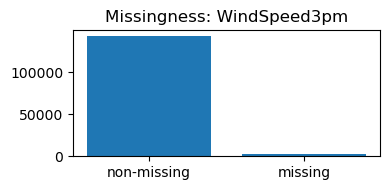

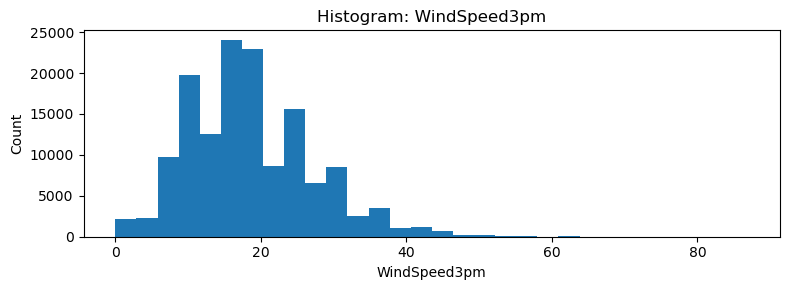

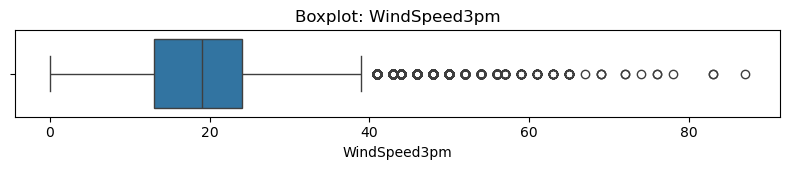

Outliers (IQR rule): 1.7%


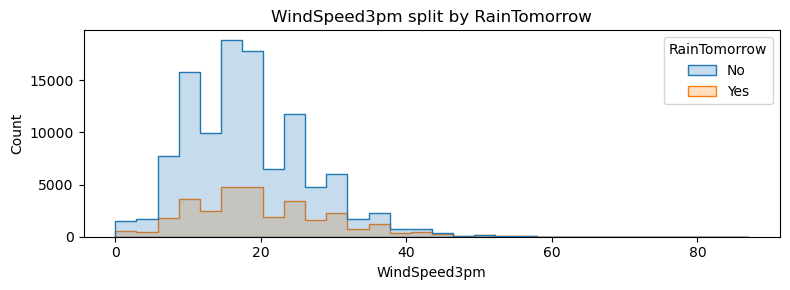

In [45]:
# Calls the function for the univariate numerical report.
univariate_report_numerical(df_eda, col="WindSpeed3pm", target="RainTomorrow")

##### Humidity 9am
Humidity9am shows a slightly left-skewed distribution, with most observations concentrated at moderate to high humidity levels typical of morning conditions. Missing values are minimal, indicating good data completeness. A small proportion of values (around 1%) is classified as outliers under the IQR rule, primarily at very low humidity levels. Overall, morning humidity appears stable, bounded, and suitable for direct use in further analysis.

=== Humidity9am (numeric) ===
Rows: 145460
Missing: 2654 (1.8%)

Descriptive statistics:
count    142806.000000
mean         68.880831
std          19.029164
min           0.000000
25%          57.000000
50%          70.000000
75%          83.000000
max         100.000000
Name: Humidity9am, dtype: float64

Skewness: -0.48


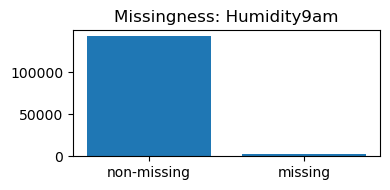

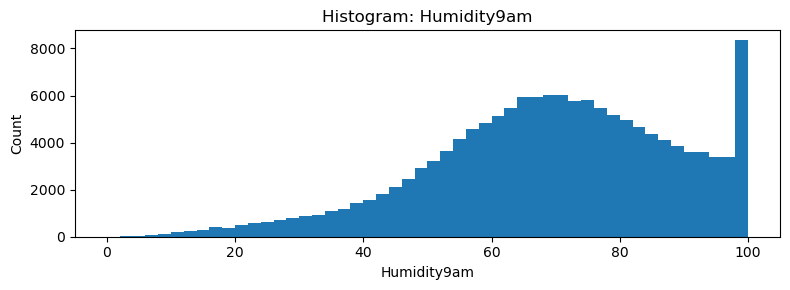

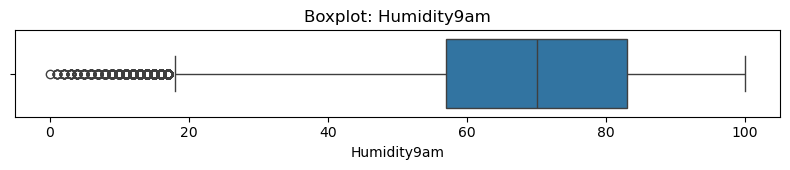

Outliers (IQR rule): 1.0%


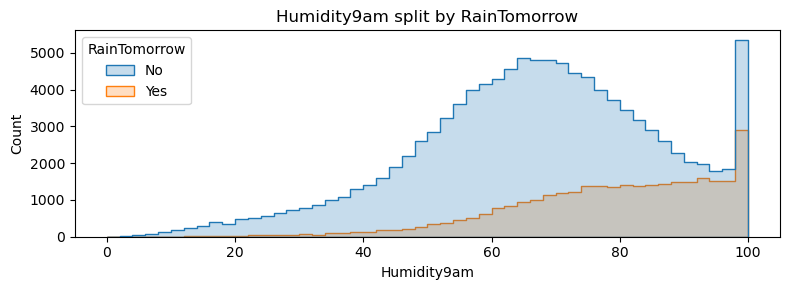

In [46]:
# Calls the function for the univariate numerical report.
univariate_report_numerical(df_eda, col="Humidity9am", target="RainTomorrow", bins = 50)

##### Humidity 3pm
Humidity3pm shows a slightly left-skewed distribution, with most observations concentrated at moderate humidity levels typical of afternoon conditions. Missing values are minimal, indicating good data completeness. A small share of observations (around 1%) is classified as outliers under the IQR rule, mainly at very low humidity values. Overall, afternoon humidity appears stable, bounded, and suitable for direct use in further analysis.

=== Humidity9am (numeric) ===
Rows: 145460
Missing: 2654 (1.8%)

Descriptive statistics:
count    142806.000000
mean         68.880831
std          19.029164
min           0.000000
25%          57.000000
50%          70.000000
75%          83.000000
max         100.000000
Name: Humidity9am, dtype: float64

Skewness: -0.48


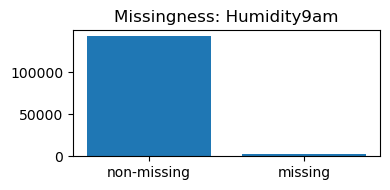

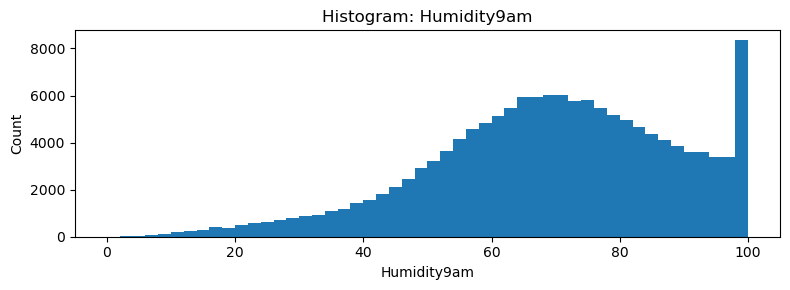

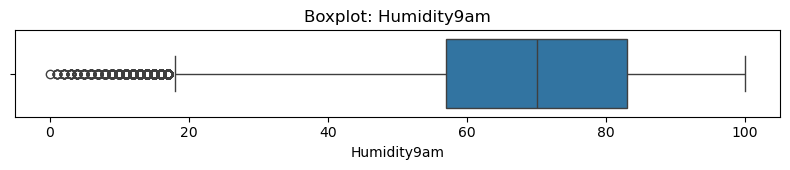

Outliers (IQR rule): 1.0%


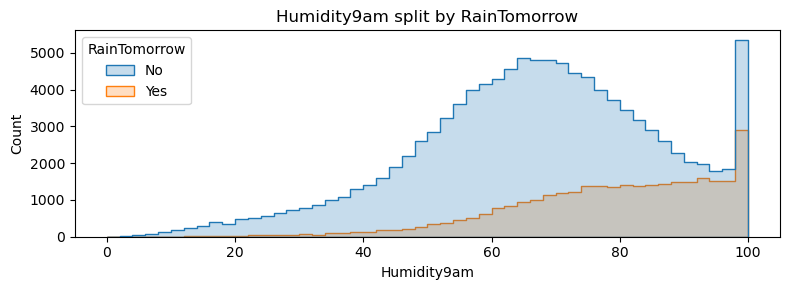

In [47]:
# Calls the function for the univariate numerical report.
univariate_report_numerical(df_eda, col="Humidity9am", target="RainTomorrow", bins = 50)

##### Pressure 9am
Pressure9am shows an approximately symmetric and bell-shaped distribution, indicating stable atmospheric pressure conditions in the morning. Missing values are limited, suggesting good data completeness. Only a very small proportion of observations (below 1%) is identified as outliers under the IQR rule, reflecting rare but plausible pressure extremes rather than measurement issues. Overall, morning pressure appears stable and well-suited for direct use in further analysis.

=== Pressure9am (numeric) ===
Rows: 145460
Missing: 15065 (10.4%)

Descriptive statistics:
count    130395.00000
mean       1017.64994
std           7.10653
min         980.50000
25%        1012.90000
50%        1017.60000
75%        1022.40000
max        1041.00000
Name: Pressure9am, dtype: float64

Skewness: -0.10


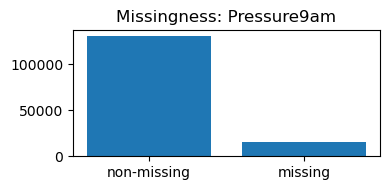

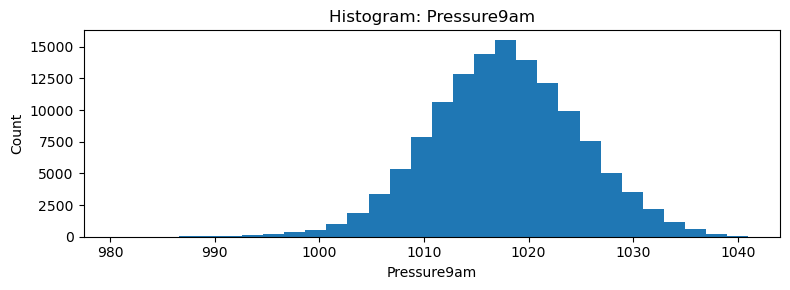

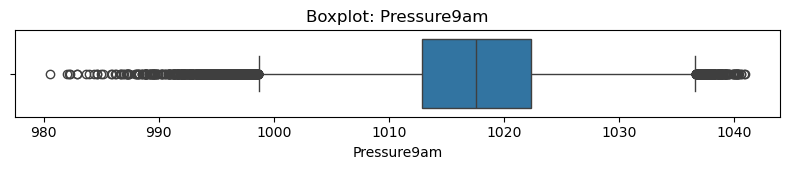

Outliers (IQR rule): 0.8%


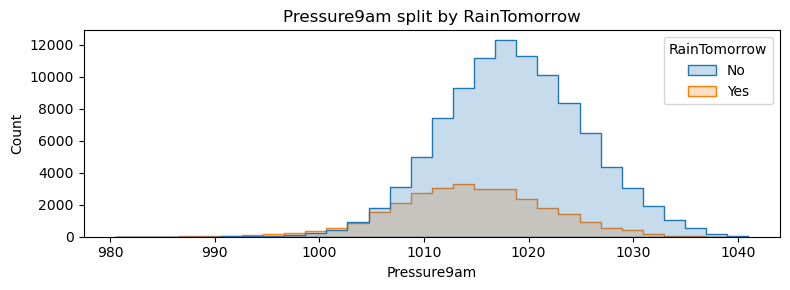

In [48]:
# Calls the function for the univariate numerical report.
univariate_report_numerical(df_eda, col="Pressure9am", target="RainTomorrow")

##### Pressure 3pm
Pressure3pm shows an approximately symmetric and bell-shaped distribution, very similar to the morning pressure values. Missing values are limited, indicating good data completeness. Only a small proportion of observations (below 1%) is identified as outliers under the IQR rule, reflecting rare but plausible pressure extremes rather than measurement issues. Overall, afternoon pressure appears stable and well-suited for direct use in further analysis.


=== Pressure3pm (numeric) ===
Rows: 145460
Missing: 15028 (10.3%)

Descriptive statistics:
count    130432.000000
mean       1015.255889
std           7.037414
min         977.100000
25%        1010.400000
50%        1015.200000
75%        1020.000000
max        1039.600000
Name: Pressure3pm, dtype: float64

Skewness: -0.05


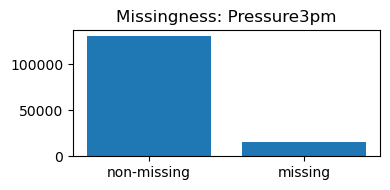

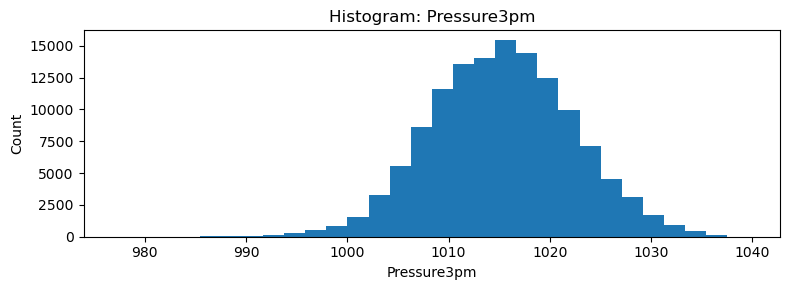

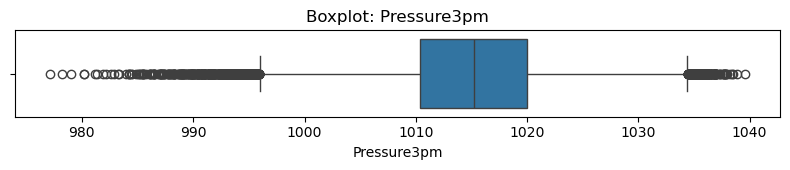

Outliers (IQR rule): 0.6%


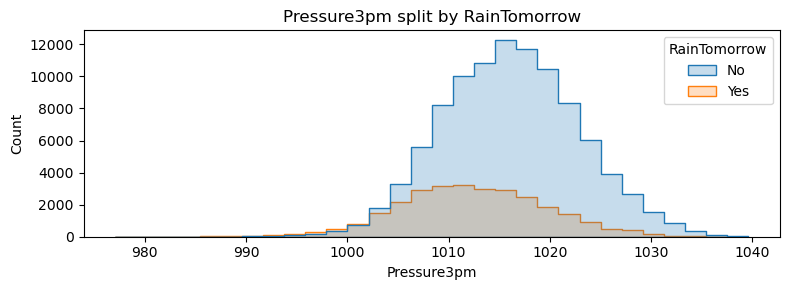

In [49]:
# Calls the function for the univariate numerical report.
univariate_report_numerical(df_eda, col="Pressure3pm", target="RainTomorrow")

##### Temperature 9am
Temp9am shows an approximately symmetric and bell-shaped distribution, indicating stable morning temperature conditions. Missing values are minimal, reflecting high data completeness. Only a very small proportion of observations (around 0.2%) is identified as outliers under the IQR rule, corresponding to rare but plausible temperature extremes. Overall, morning temperature appears stable and well-suited for direct use in further analysis.

=== Temp9am (numeric) ===
Rows: 145460
Missing: 1767 (1.2%)

Descriptive statistics:
count    143693.000000
mean         16.990631
std           6.488753
min          -7.200000
25%          12.300000
50%          16.700000
75%          21.600000
max          40.200000
Name: Temp9am, dtype: float64

Skewness: 0.09


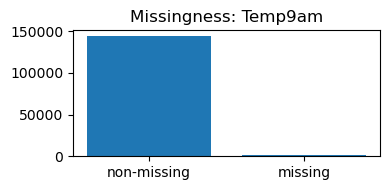

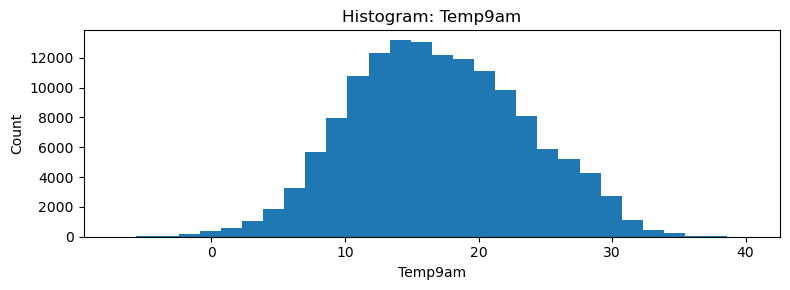

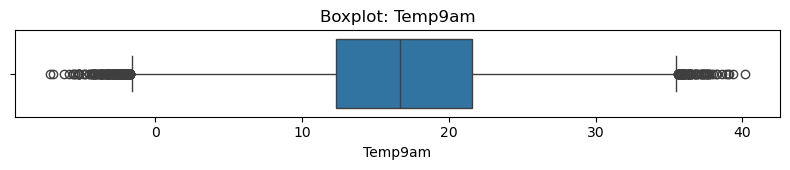

Outliers (IQR rule): 0.2%


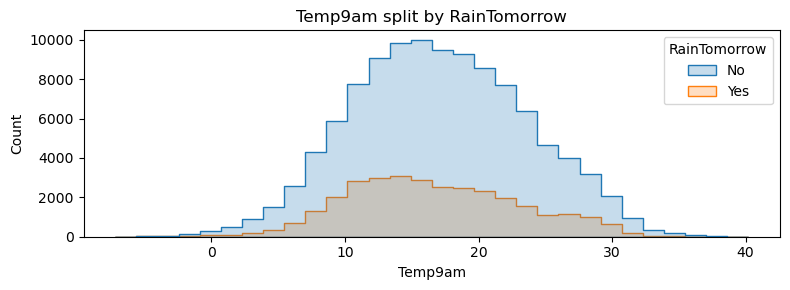

In [50]:
# Calls the function for the univariate numerical report.
univariate_report_numerical(df_eda, col="Temp9am", target="RainTomorrow")

##### Temperature 3pm
Temp3pm shows an approximately symmetric and slightly right-skewed distribution, reflecting typical afternoon temperature conditions. Missing values are minimal, indicating high data completeness. Only a very small proportion of observations (around 0.5%) is classified as outliers under the IQR rule, corresponding to rare but plausible temperature extremes. Overall, afternoon temperature appears stable and well-suited for direct use in further analysis.

=== Temp3pm (numeric) ===
Rows: 145460
Missing: 3609 (2.5%)

Descriptive statistics:
count    141851.00000
mean         21.68339
std           6.93665
min          -5.40000
25%          16.60000
50%          21.10000
75%          26.40000
max          46.70000
Name: Temp3pm, dtype: float64

Skewness: 0.24


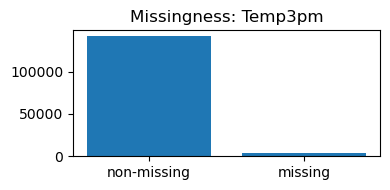

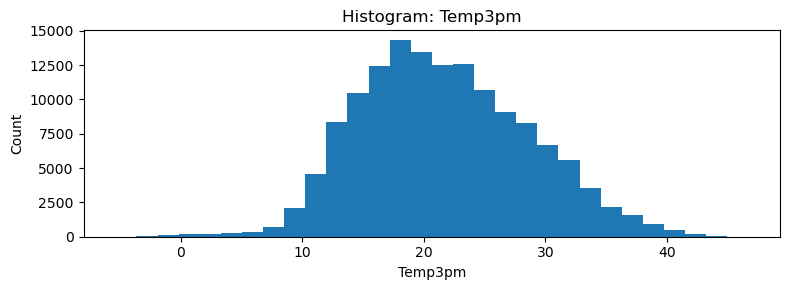

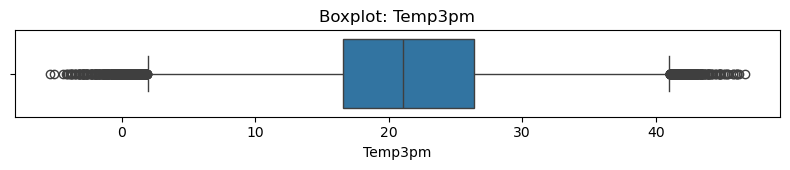

Outliers (IQR rule): 0.5%


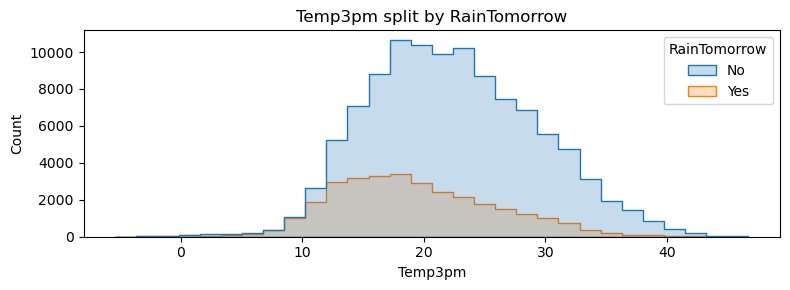

In [51]:
# Calls the function for the univariate numerical report.
univariate_report_numerical(df_eda, col="Temp3pm", target="RainTomorrow")

### Bivariate Analysis

##### Rainfall by Location
The spatial visualization reveals a clear geographical pattern in rainfall amount across Australia. Larger bubbles are predominantly concentrated along the coastal regions, particularly in the north, east, and southeast, indicating higher rainfall levels in these areas. In contrast, central and inland regions show fewer and smaller bubbles, reflecting substantially lower precipitation.

This pattern is consistent with Australia’s climatic characteristics, where coastal zones are more strongly influenced by oceanic moisture and weather systems, while the interior remains comparatively dry. The map therefore confirms that rainfall is not uniformly distributed but strongly shaped by geographic location and proximity to the coast.

Furthermore, the sensor locations are not evenly distributed across Australia. Observations are clearly clustered along coastal and urban regions, while large parts of the inland, central areas and northwest are sparsely covered or not represented. This suggests that the dataset reflects a measurement density bias, likely driven by population distribution and infrastructure availability, which should be considered when interpreting spatial rainfall patterns.

In [52]:
# If the geocoded dataframe is empty (e.g., because the geocoding step was skipped or API requests failed), load the previously saved local CSV file. This fallback ensures reproducibility and prevents repeated geocoding requests.
if df_geocodes.empty:
    df_geocodes = pd.read_csv("df_geocodes.csv")

In [53]:
# Creates a working copy of the geocoded dataframe for spatial rainfall analysis.
df_rain_by_location = df_geocodes.copy()

# Removes locations without valid geographic coordinates. Only locations with latitude and longitude can be visualized on the map.
df_rain_by_location_clean = (
    df_rain_by_location
    .dropna(subset=["Latitude", "Longitude"])
    .copy()
)

# Normalizes rainfall values to control bubble sizes on the map. Min–max scaling ensures visual comparability while avoiding extreme marker sizes.
scaler = MinMaxScaler(feature_range=(4, 30))
df_rain_by_location_clean["Rainfall_norm"] = scaler.fit_transform(
    df_rain_by_location_clean[["Rainfall"]]
)

# Creates a base map centered on Australia.
map_australia = folium.Map(
    location=[-25.2744, 133.7751],
    zoom_start=5
)

# Adds rainfall-dependent circle markers to the map. Bubble radius reflects normalized rainfall intensity at each location.
for _, row in df_rain_by_location_clean.iterrows():
    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=row["Rainfall_norm"],
        fill=True,
        fill_opacity=0.7,
        weight=1,
        popup=(
            f"{row["Location"]}<br>"
            f"Rainfall: {row["Rainfall"]:.2f}"
        )
    ).add_to(map_australia)

# Saves the interactive map as an HTML file for use in presentations.
map_australia.save("rain_by_location.html")

# Display the map in the notebook.
map_australia

##### RainTomorrow Rate by Location

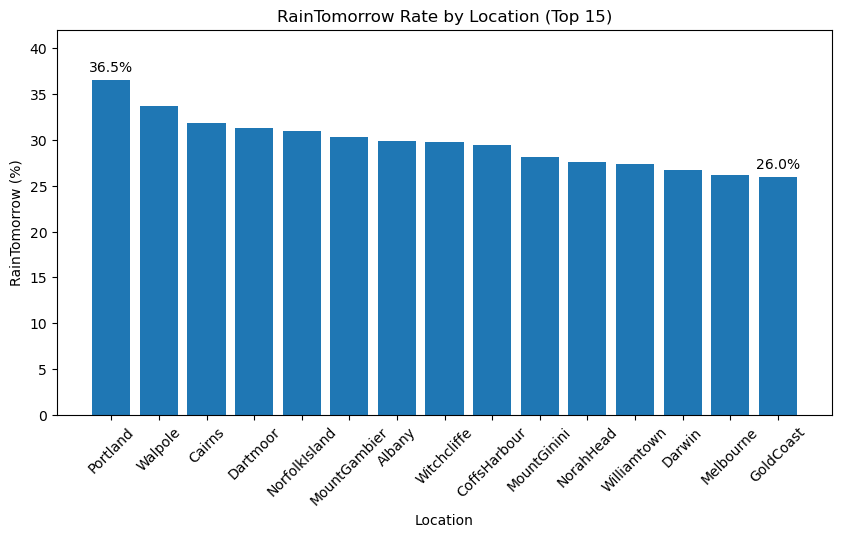

,Location,count,rain_rate,rain_rate_pct
33,Portland,2996,0.365487,36.548732
43,Walpole,2819,0.336644,33.664420
8,Cairns,2988,0.317938,31.793842
12,Dartmoor,2943,0.313286,31.328576
27,NorfolkIsland,2964,0.310054,31.005398
22,MountGambier,3030,0.303630,30.363036
1,Albany,3016,0.299072,29.907162
46,Witchcliffe,2952,0.297764,29.776423
11,CoffsHarbour,2953,0.294277,29.427701
23,MountGinini,2907,0.281734,28.173375


In [54]:
# ============================
# Step 1: Compute RainTomorrow rate by Location
# ============================

cat_col = "Location"
target_col = "RainTomorrow_bin"

d = df_eda[[cat_col, target_col]].copy()

# Convert target to binary 0/1 if needed
if d[target_col].dtype == "O":
    d[target_col] = (
        d[target_col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({"yes": 1, "no": 0})
    )
else:
    d[target_col] = pd.to_numeric(d[target_col], errors="coerce")

# Drop missing values
d = d.dropna(subset=[cat_col, target_col])

# Compute count and rain rate
loc_rate_all = (
    d.groupby(cat_col)[target_col]
     .agg(
         count="size",
         rain_rate="mean"
     )
     .reset_index()
)

# ============================
# Step 2: Select top 15 locations by rain rate
# ============================

loc_rate = (
    loc_rate_all
    .sort_values(["rain_rate", "Location"], ascending=[False, True])
    .head(15)
    .copy()
)

# Convert rate to percentage for plotting
loc_rate["rain_rate_pct"] = loc_rate["rain_rate"] * 100

# Lock x-axis order explicitly
loc_rate["Location"] = pd.Categorical(
    loc_rate["Location"],
    categories=loc_rate["Location"].tolist(),
    ordered=True
)

# ============================
# Step 3: Plot bar chart
# ============================

x = loc_rate["Location"].astype(str).to_numpy()
y = loc_rate["rain_rate_pct"].to_numpy()

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x, y)
ax.set_title("RainTomorrow Rate by Location (Top 15)")
ax.set_xlabel("Location")
ax.set_ylabel("RainTomorrow (%)")
ax.tick_params(axis="x", rotation=45)
ax.set_ylim(0, max(1, np.nanmax(y) * 1.15))

# Annotate min and max values
if len(y) > 0 and not np.all(np.isnan(y)):
    i_min = int(np.nanargmin(y))
    i_max = int(np.nanargmax(y))
    for i in {i_min, i_max}:
        ax.annotate(
            f"{y[i]:.1f}%",
            (i, y[i]),
            textcoords="offset points",
            xytext=(0, 6),
            ha="center"
        )

plt.show()

# inspect the table
loc_rate

##### RainTomorrow rate (%) by location

This map shows the geographic distribution of the probability that it will rain tomorrow across Australian weather stations. Each point corresponds to a location, and the color represents the average RainTomorrow rate, with green indicating lower probabilities and red indicating higher probabilities. We observe clear spatial patterns: coastal regions—particularly in the southeast and parts of the east coast—exhibit higher rain probabilities, while inland and central regions tend to have lower values. This suggests that geographic location and proximity to the coast play an important role in rainfall occurrence. These spatial differences motivate further analysis of location-specific effects in the predictive modeling stage.

In [55]:
# ============================
# Prepare location-level RainTomorrow rates for mapping
# ============================

# Select only the location identifier and the binary RainTomorrow outcome,
# and remove rows with missing values to ensure valid probability estimates.
df_rt_by_location = (
    df_eda[["Location", "RainTomorrow_bin"]]
    .dropna()
    # Aggregate at the location level:
    # the mean of a binary variable represents the empirical probability
    # of RainTomorrow at each location.
    .groupby("Location", as_index=False)["RainTomorrow_bin"]
    .mean()
)

# Convert rain probability from proportion (0–1) to percentage (0–100)
# for easier interpretation and labeling in visualizations.
df_rt_by_location["RainTomorrow_pct"] = (
    df_rt_by_location["RainTomorrow_bin"] * 100
)

# Merge geographic coordinates (latitude and longitude) for each location.
# A left join is used to preserve all computed rain-rate locations,
# even if some locations do not have available geocoding information.
df_rt_by_location = df_rt_by_location.merge(
    df_geocodes[["Location", "Latitude", "Longitude"]],
    on="Location",
    how="left",
)

# Remove locations for which geographic coordinates are missing,
# as they cannot be plotted on a map.
# A copy is created to avoid chained-assignment warnings in downstream steps.
df_rt_by_location_clean = (
    df_rt_by_location
    .dropna(subset=["Latitude", "Longitude"])
    .copy()
)

# Preview the cleaned, map-ready dataset.
df_rt_by_location_clean.head()

,Location,RainTomorrow_bin,RainTomorrow_pct,Latitude,Longitude
0,Adelaide,0.222654,22.265372,-34.928181,138.599931
1,Albany,0.299072,29.907162,-35.024782,117.883608
2,Albury,0.205247,20.524743,-36.080477,146.916280
5,Ballarat,0.257926,25.792602,-37.562301,143.860565
6,Bendigo,0.185234,18.523401,-36.759018,144.282672


In [56]:
# ============================
# Geographic visualization: Color-encoded RainTomorrow map
# ============================

# Import branca's colormap utility to create a continuous color scale.
# This allows RainTomorrow probability to be encoded via color intensity
# rather than marker size.
import branca.colormap as cm

# Define a linear color map spanning from low to high rain probability.
# Green → low probability, Yellow → medium, Red → high probability.
# The scale is normalized using the observed min/max values in the dataset
# to fully utilize the available color range.
colormap = cm.LinearColormap(
    colors=["green", "yellow", "red"],
    vmin=df_rt_by_location_clean["RainTomorrow_pct"].min(),
    vmax=df_rt_by_location_clean["RainTomorrow_pct"].max(),
)

# Add a caption so viewers can interpret the color scale quantitatively.
colormap.caption = "RainTomorrow (%)"

# Initialize a Folium map centered on Australia.
# The zoom level is chosen to show the full continent while retaining
# station-level spatial resolution.
m = folium.Map(
    location=[-25.2744, 133.7751],
    zoom_start=5
)

# Iterate over each location and add a fixed-radius circle marker.
# In this variant:
#   - Marker size is constant (radius=8) to avoid perceptual bias from area scaling
#   - Marker color encodes RainTomorrow probability via the colormap
for _, r in df_rt_by_location_clean.iterrows():

    # Extract rain probability as a float for consistent color mapping.
    pct = float(r["RainTomorrow_pct"])

    folium.CircleMarker(
        location=[float(r["Latitude"]), float(r["Longitude"])],  # geographic position
        radius=8,                                                 # fixed size
        color=colormap(pct),                                      # outline color
        fill=True,
        fill_color=colormap(pct),                                 # fill color
        fill_opacity=0.85,
        popup=f"{r["Location"]}<br>RainTomorrow: {pct:.1f}%",     # interactive label
    ).add_to(m)

# Add the color legend to the map so the color encoding is interpretable.
colormap.add_to(m)

# Render the interactive map.
m

##### Rain Tomorrow Rate by Wind

The three polar plots suggest that wind direction has only a weak relationship with next-day rain in this dataset. Across WindGustDir, WindDir9am, and WindDir3pm, the RainTomorrow rates are fairly similar across directions, with only small fluctuations between the highest and lowest sectors. While a few directions appear slightly higher or lower, the differences are not large enough to claim that westerly or north-westerly winds strongly increase rain probability here. The similarity between the 9am and 3pm plots also indicates that time-of-day wind direction does not substantially improve discrimination for RainTomorrow on its own. Overall, these plots imply that wind direction alone is not a strong standalone predictor of next-day rainfall, and any directional effect is likely secondary compared with variables like humidity, pressure, cloud, or RainToday.

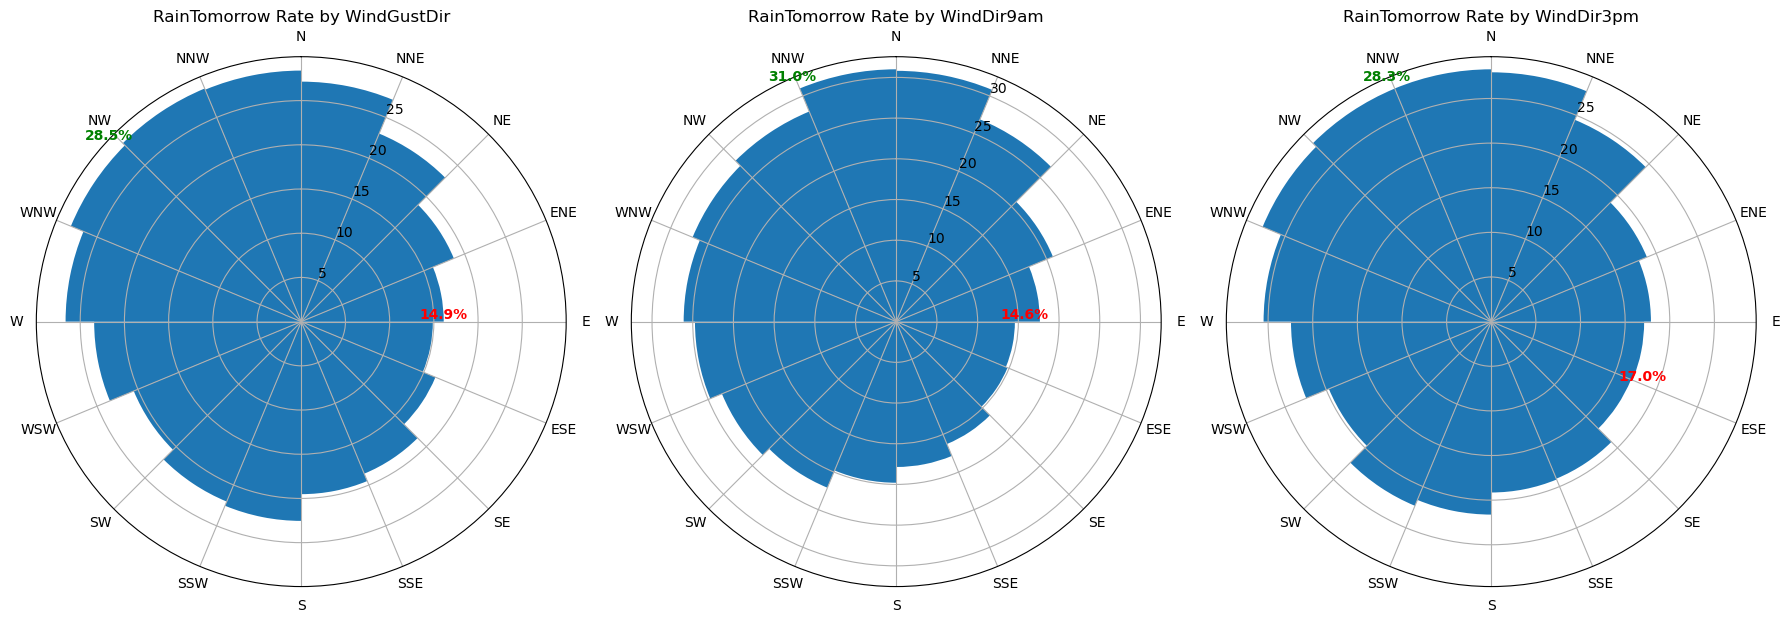

In [57]:
# Target variable: binary indicator of whether it rains tomorrow (0/1)
TARGET = "RainTomorrow_bin"

# Each tuple defines:
# (1) the wind-direction feature to analyze
# (2) the title shown on the corresponding subplot
features = [
    ("WindGustDir", "RainTomorrow Rate by WindGustDir"),
    ("WindDir9am",  "RainTomorrow Rate by WindDir9am"),
    ("WindDir3pm",  "RainTomorrow Rate by WindDir3pm"),
]

# Create a 1×3 figure with polar subplots.
# Polar projection is appropriate because wind direction is a circular variable
# (N → E → S → W → back to N).
fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6),
    subplot_kw={"projection": "polar"}
)

# Loop over subplots and corresponding wind features
for ax, (feature, title) in zip(axes, features):

    # ============================
    # Data selection and cleaning
    # ============================
    # Keep only the current wind direction and the target variable
    d = df_eda[[feature, TARGET]].copy()

    # Ensure the target is numeric (0/1).
    # This allows the group mean to be interpreted as a probability.
    if d[TARGET].dtype == "O":
        d[TARGET] = (
            d[TARGET]
            .astype(str)
            .str.strip()
            .str.lower()
            .map({"yes": 1, "no": 0})
        )
    else:
        d[TARGET] = pd.to_numeric(d[TARGET], errors="coerce")

    # Remove rows with missing wind direction or target values
    d = d.dropna(subset=[feature, TARGET])

    # ============================
    # Compute RainTomorrow rate
    # ============================
    # Group by wind direction and compute the mean of the binary target.
    # mean(0/1) = empirical probability of rain tomorrow.
    # Reindex enforces a consistent compass ordering (N → NNE → ... → NW).
    rate = (
        d.groupby(feature)[TARGET]
         .mean()
         .reindex(WIND_DIR_ORDER)
         .dropna()
         * 100      # convert probability to percentage
    )

    # Extract labels and values for plotting
    labels = rate.index.astype(str).to_list()
    values = rate.to_numpy()

    # Convert categorical wind directions into evenly spaced polar angles
    n = len(labels)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)

    # ============================
    # Identify extreme values
    # ============================
    # Index of highest and lowest rain probabilities
    i_max = int(np.nanargmax(values))
    i_min = int(np.nanargmin(values))

    # ============================
    # Plot polar bars
    # ============================
    # All bars use the same color to avoid visual bias;
    # emphasis is added via numeric annotations only.
    ax.bar(
        angles,
        values,
        width=2 * np.pi / n,
        align="edge"
    )

    # ============================
    # Configure compass orientation
    # ============================
    # Place North (0°) at the top and rotate clockwise,
    # matching standard meteorological conventions.
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    # ============================
    # Axis ticks and title
    # ============================
    ax.set_xticks(angles)
    ax.set_xticklabels(labels)
    ax.set_title(title, pad=25)  # lift title above the "N" label

    # ============================
    # Annotate extreme percentages
    # ============================
    # Highest probability → green
    ax.text(
        angles[i_max],
        values[i_max] * 1.08,      # slight radial offset to avoid overlap
        f"{values[i_max]:.1f}%",
        color="green",
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold"
    )

    # Lowest probability → red
    ax.text(
        angles[i_min],
        values[i_min] * 1.08,
        f"{values[i_min]:.1f}%",
        color="red",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Adjust spacing so titles and labels do not overlap
plt.tight_layout()

# Render the figure
plt.show()

##### Rain Tomorrow Rate by Rain Today

The stacked bar chart visualizes the conditional distribution of RainTomorrow outcomes within each RainToday group. When RainToday = 0 (no rain today), RainTomorrow is predominantly 0 (dry tomorrow). When RainToday = 1 (rain today), the probability of RainTomorrow = 1 increases substantially—approximately threefold compared to dry days. However, even after a rainy day, RainTomorrow = 0 remains slightly more likely than RainTomorrow = 1, indicating short-term weather persistence but also highlighting that RainToday alone is not a sufficient predictor of next-day rainfall.

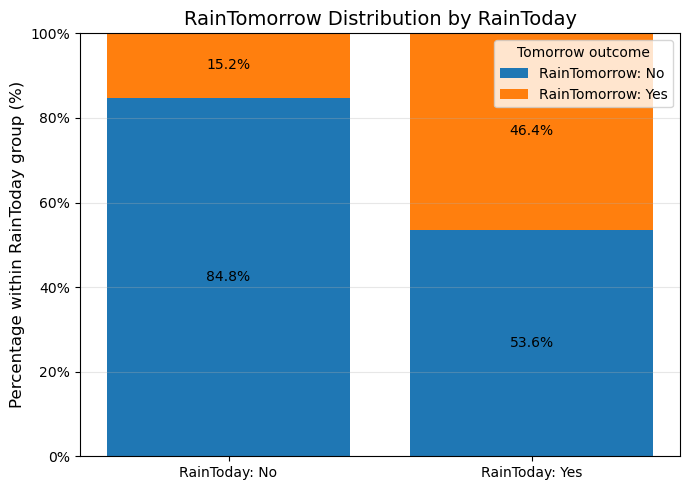

Counts (RainToday x RainTomorrow):
RainTomorrow_bin      0      1
RainToday_bin                 
0                 92728  16604
1                 16858  14597


In [58]:
# ============================
# Data preparation
# ============================
# Keep only the binary indicators and drop rows with missing values
tmp = df_eda[["RainToday_bin", "RainTomorrow_bin"]].dropna()

# Ensure both columns are numeric (defensive, in case of mixed dtypes)
tmp["RainToday_bin"] = pd.to_numeric(tmp["RainToday_bin"], errors="coerce")
tmp["RainTomorrow_bin"] = pd.to_numeric(tmp["RainTomorrow_bin"], errors="coerce")
tmp = tmp.dropna(subset=["RainToday_bin", "RainTomorrow_bin"])

# ============================
# Compute conditional percentages
# ============================
# Cross-tab counts: rows = RainToday (0/1), columns = RainTomorrow (0/1)
ct = pd.crosstab(tmp["RainToday_bin"], tmp["RainTomorrow_bin"])

# Convert counts to row-wise percentages (each row sums to 100%)
pct = ct.div(ct.sum(axis=1), axis=0) * 100

# Enforce consistent ordering for readability:
# rows: RainToday 0->1, columns: RainTomorrow 0->1
pct = pct.reindex(index=[0, 1], columns=[0, 1])

# Rename for presentation
pct.index = ["RainToday: No", "RainToday: Yes"]
pct.columns = ["RainTomorrow: No", "RainTomorrow: Yes"]

# ============================
# Plot: 100% stacked bars
# ============================
fig, ax = plt.subplots(figsize=(7, 5))

x = np.arange(len(pct.index))  # positions for the two bars
bottom = np.zeros(len(pct.index))

# Plot each segment stacked on top of the previous one
for col in pct.columns:
    values = pct[col].to_numpy()
    ax.bar(pct.index, values, bottom=bottom, label=col)
    bottom += values

# Format axes
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_ylabel("Percentage within RainToday group (%)", fontsize=12)
ax.set_title("RainTomorrow Distribution by RainToday", fontsize=14)
ax.grid(axis="y", alpha=0.3)

# Add legend
ax.legend(title="Tomorrow outcome", loc="upper right")

# Annotate percentages inside segments
for i in range(len(pct.index)):
    cum = 0
    for col in pct.columns:
        v = pct.iloc[i][col]
        if v >= 5:  # avoid clutter for tiny segments
            ax.text(i, cum + v/2, f"{v:.1f}%", ha="center", va="center", fontsize=10)
        cum += v

plt.tight_layout()
plt.show()

# ============================
# Print counts for context
# ============================
print("Counts (RainToday x RainTomorrow):")
print(ct.reindex(index=[0, 1], columns=[0, 1]))

##### Rain Tomorrow Rate by Cloud

The analysis shows that as cloud cover increases, the chance of rain on the following day also becomes higher. This is because cloudy conditions usually indicate that there is more moisture in the air and that the atmosphere is already in a state that can support rainfall. In particular, cloud cover in the afternoon (3pm) appears to be more strongly related to RainTomorrow than cloud cover in the morning, likely because it is closer in time to when rain may occur. Overall, cloud cover acts as a useful early signal of whether the weather conditions are suitable for rain on the next day.

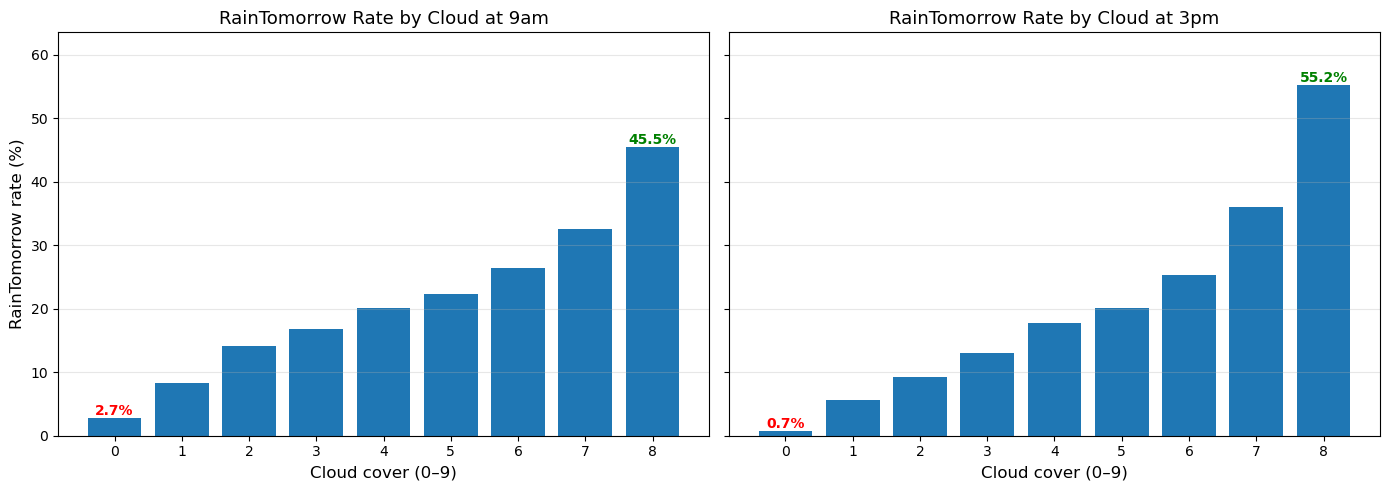

In [59]:
# Target variable: binary indicator of whether it rains tomorrow (0 = No, 1 = Yes)
TARGET = "RainTomorrow_bin" 

# Cloud cover features to analyze, paired with descriptive subplot titles
cloud_features = [
    ("Cloud9am", "RainTomorrow Rate by Cloud at 9am"),
    ("Cloud3pm", "RainTomorrow Rate by Cloud at 3pm"),
]

# Standard cloud oktas (0–8), used to enforce a consistent x-axis order
cloud_order = [0,1,2,3,4,5,6,7,8]

# Create a 1×2 figure with a shared y-axis.
# Sharing the y-axis ensures direct comparability between 9am and 3pm cloud effects.
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Loop over subplots and corresponding cloud features
for ax, (feature, title) in zip(axes, cloud_features):

    # ============================
    # Data selection and cleaning
    # ============================
    # Keep only the cloud feature and the target variable
    d = df_eda[[feature, TARGET]].copy()

    # Ensure cloud cover is numeric (it may be stored as an object in the raw data)
    d[feature] = pd.to_numeric(d[feature], errors="coerce")

    # Ensure the target is numeric (0/1).
    # If stored as strings ("Yes"/"No"), map them explicitly.
    if d[TARGET].dtype == "O":
        d[TARGET] = (
            d[TARGET]
            .astype(str)
            .str.strip()
            .str.lower()
            .map({"yes": 1, "no": 0})
        )
    else:
        d[TARGET] = pd.to_numeric(d[TARGET], errors="coerce")

    # Drop rows with missing cloud cover or target values
    d = d.dropna(subset=[feature, TARGET])

    # ============================
    # Compute RainTomorrow rate
    # ============================
    # Group by cloud cover level and compute the mean of the binary target.
    # The mean of a 0/1 variable corresponds to the empirical rain probability.
    # Reindex enforces the standard oktas order (0 → 8).
    rate_pct = (
        d.groupby(feature)[TARGET]
         .mean()
         .reindex(cloud_order)
         * 100   # convert probability to percentage
    )

    # Prepare x-axis labels (cloud oktas) and y-axis values (percentages)
    x = [str(i) for i in cloud_order]
    y = rate_pct.values

    # ============================
    # Plot
    # ============================
    # Bar chart is appropriate because cloud cover is a discrete ordinal variable
    ax.bar(x, y)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Cloud cover (0–9)", fontsize=12)

    # Add horizontal grid lines to aid comparison across cloud levels
    ax.grid(axis="y", alpha=0.3)

    # Extend y-axis slightly above the maximum value
    # so numeric annotations are not clipped
    ax.set_ylim(0, np.nanmax(y) * 1.15 if np.isfinite(np.nanmax(y)) else 1)

    # ============================
    # Annotate extremes only
    # ============================
    # Highlight the highest and lowest rain probabilities
    # without cluttering the figure with too many labels
    if len(y) > 0 and not np.all(np.isnan(y)):
        i_min = int(np.nanargmin(y))
        i_max = int(np.nanargmax(y))

        # Highest probability → green
        ax.text(
            i_max,
            y[i_max],
            f"{y[i_max]:.1f}%",
            color="green",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

        # Lowest probability → red
        ax.text(
            i_min,
            y[i_min],
            f"{y[i_min]:.1f}%",
            color="red",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

# Add a single shared y-axis label to avoid redundancy
axes[0].set_ylabel("RainTomorrow rate (%)", fontsize=12)

# Adjust layout to prevent overlap between labels and titles
plt.tight_layout()

# Render the figure
plt.show()

##### RainTomorrow Rate by Numerical Values

The rate curves show that several numerical weather variables are strongly related to the chance of rain on the following day. RainTomorrow is more likely when afternoon humidity is high, rainfall is already high, sunshine hours are low, wind gust speed is strong, and air pressure is low both in the morning and afternoon. These patterns make intuitive sense because they describe weather conditions that are already unstable, moist, and cloudy, which are typical before rainfall occurs. Many of these variables are also good indicators of rain today, suggesting that they capture the overall weather situation rather than isolated events. Overall, these numerical features help identify short-term weather conditions that increase the likelihood of rain continuing into the next day.

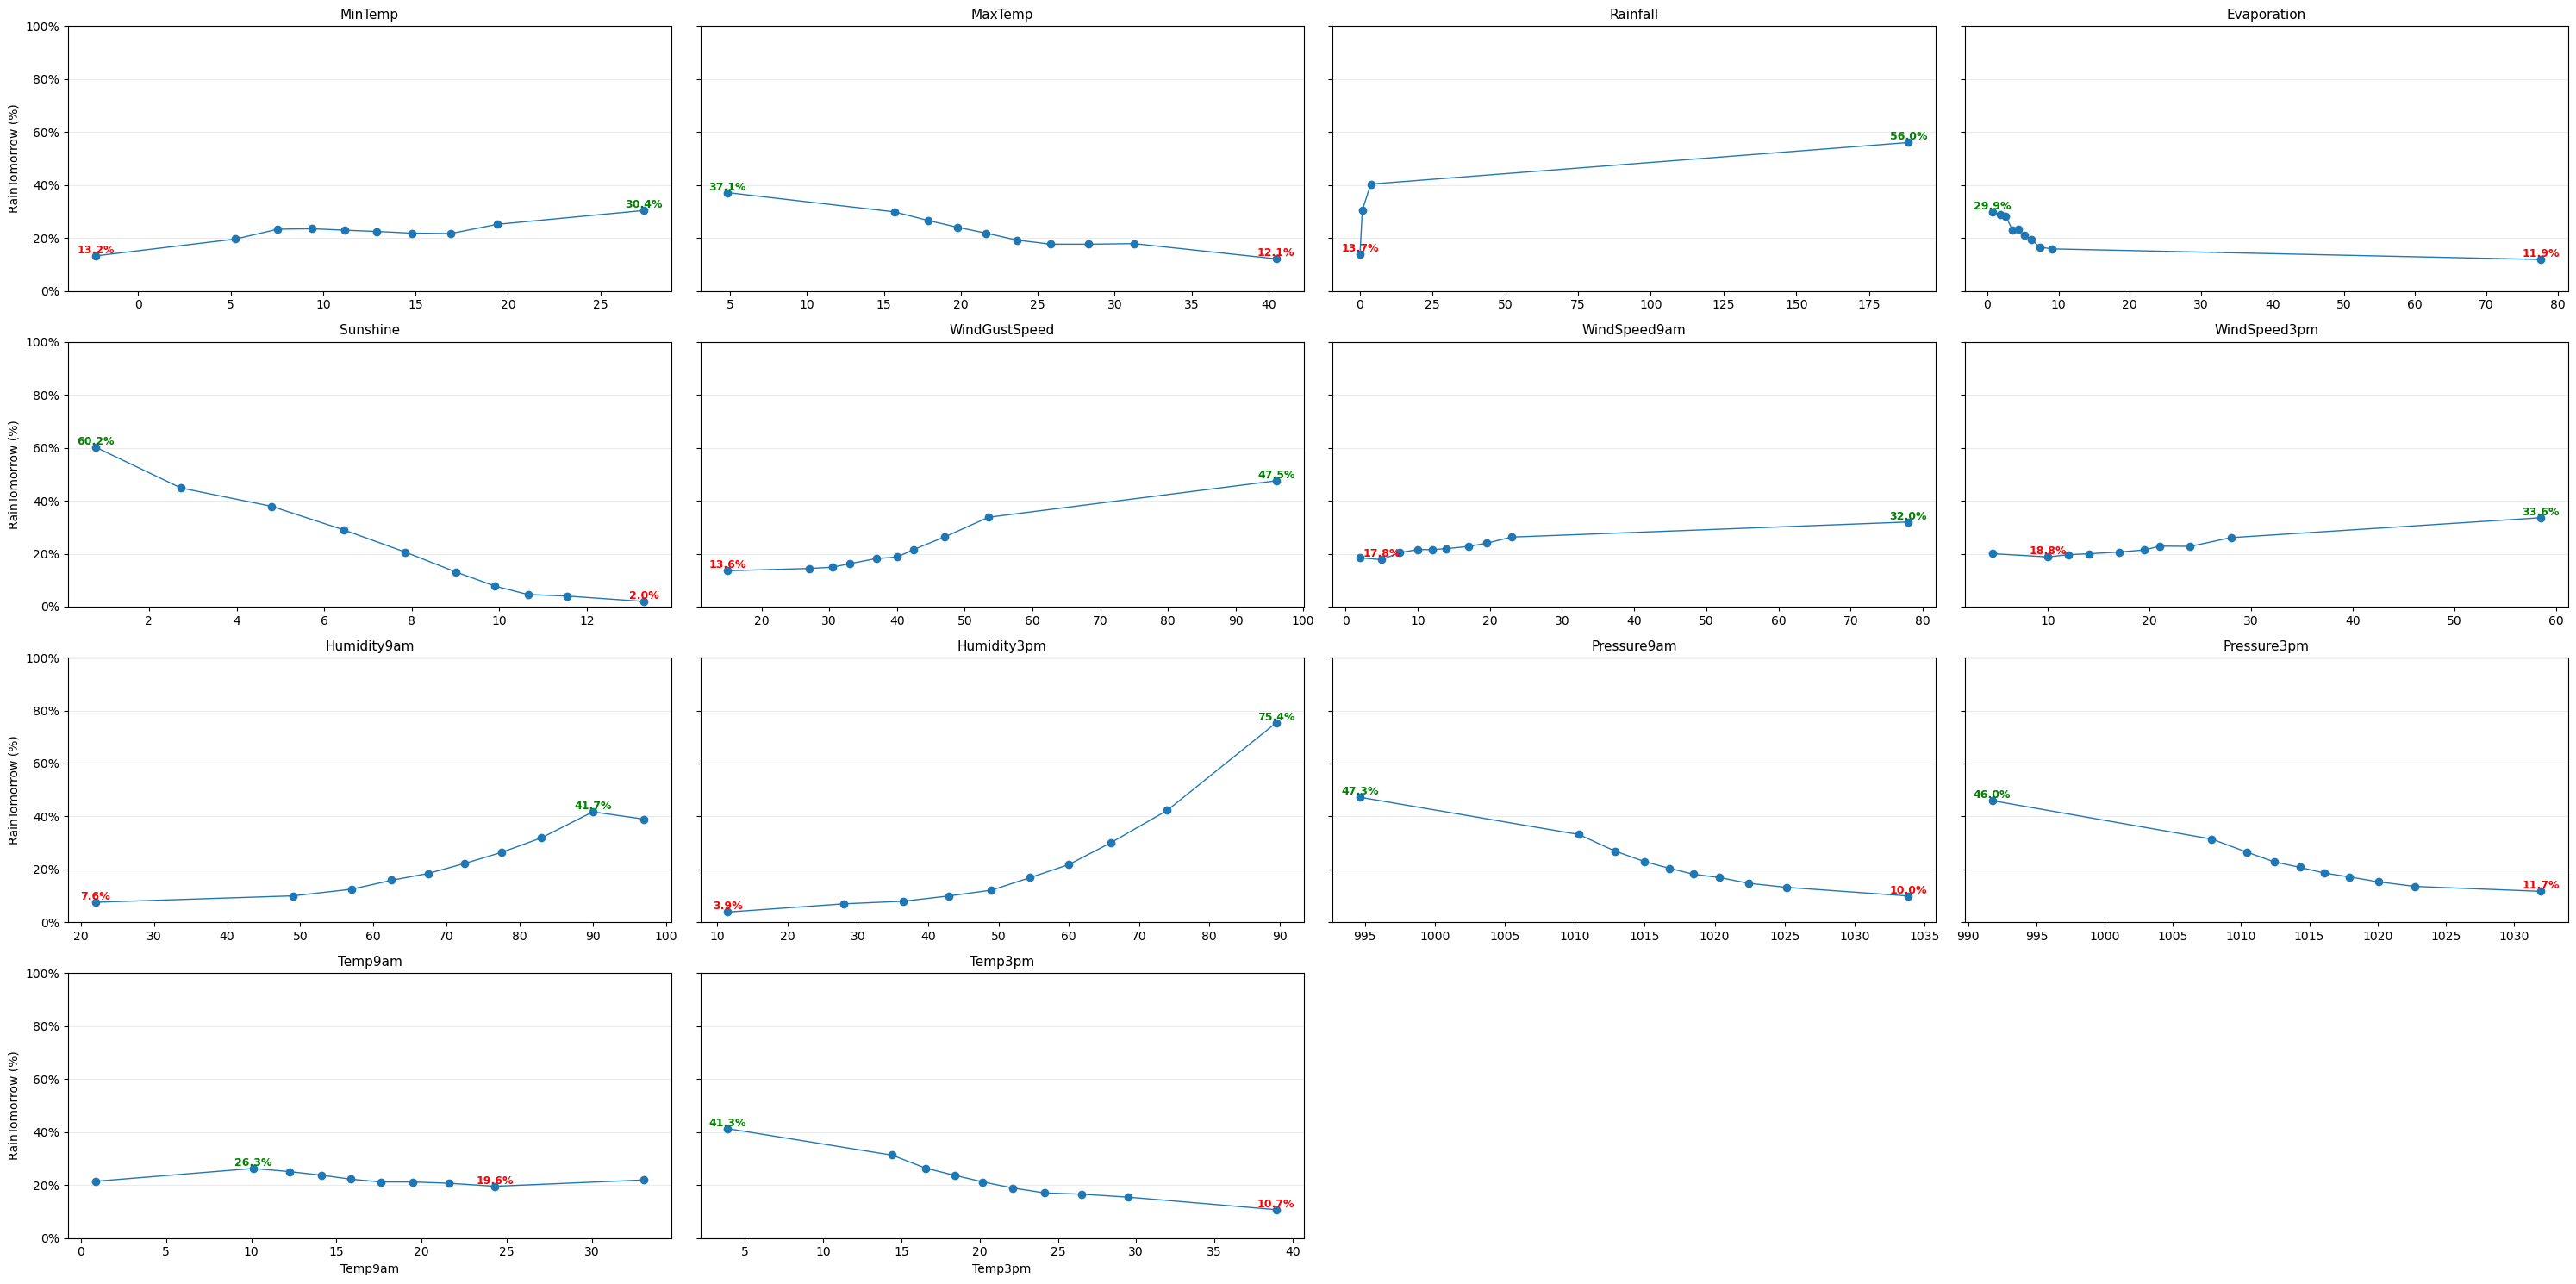

In [60]:
# ============================
# Parameters
# ============================
# Binary target variable indicating whether it rains tomorrow (0 = No, 1 = Yes)
target_col = "RainTomorrow_bin"

# Number of quantile bins used for numeric features
# q=10 corresponds to decile binning
q = 10

# Number of columns in the subplot grid
n_cols = 4

# Overall figure size; enlarged to keep each subplot readable
figsize = (30, 15)


# ============================
# 1) Choose numeric features
# ============================
# Select only numeric columns from the dataset
df_num = df_eda.select_dtypes(include=[np.number]).copy()

# Exclude variables that should not be treated as predictors:
# - target_col: outcome variable
# - RainToday_bin: conditioning variable (would cause leakage)
numeric_features = [
    c for c in df_num.columns
    if c not in {target_col, "RainToday_bin"}
]

# Optionally remove obvious non-feature numeric columns (identifiers or coordinates)
drop_if_present = {"Year", "Month", "Day", "Latitude", "Longitude"}
numeric_features = [c for c in numeric_features if c not in drop_if_present]


# ============================
# 2) Create subplot grid
# ============================
# Determine the number of rows needed given the number of features and columns
n_plots = len(numeric_features)
n_rows = int(np.ceil(n_plots / n_cols))

# Create a grid of subplots with a shared y-axis
# Sharing the y-axis ensures rain probabilities are directly comparable
fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, sharey=True)

# Flatten the axes array for simpler indexing in a single loop
axes = np.array(axes).reshape(-1)


# ============================
# 3) Loop through each numeric feature
# ============================
for i, feature in enumerate(numeric_features):
    ax = axes[i]

    # ============================
    # Data selection and cleaning
    # ============================
    # Keep only the current feature and the target variable
    d = df_eda[[feature, target_col]].copy()

    # Ensure both feature and target are numeric
    d[feature] = pd.to_numeric(d[feature], errors="coerce")
    d[target_col] = pd.to_numeric(d[target_col], errors="coerce")

    # Drop rows with missing values
    d = d.dropna(subset=[feature, target_col])

    # If too few observations remain, skip this feature
    if len(d) < 30:
        ax.set_title(f"{feature}\n(insufficient data)", fontsize=10)
        ax.axis("off")
        continue

    # ============================
    # Quantile binning
    # ============================
    # Divide the feature distribution into q quantile bins.
    # This balances sample sizes per bin and helps reveal non-linear effects.
    try:
        d["bin"] = pd.qcut(d[feature], q=q, duplicates="drop")
    except ValueError:
        # If qcut fails (e.g., too many identical values), skip gracefully
        ax.set_title(f"{feature}\n(qcut failed)", fontsize=10)
        ax.axis("off")
        continue

    # ============================
    # Compute bin-wise rain probability
    # ============================
    # Mean of a binary target equals the empirical probability of rain tomorrow
    tab = (
        d.groupby("bin")[target_col]
         .agg(count="size", rate="mean")
         .reset_index()
    )

    # Convert probability to percentage for interpretability
    tab["rate_pct"] = tab["rate"] * 100

    # Use bin midpoints as x-values for smooth curve plotting
    tab["x_mid"] = tab["bin"].apply(lambda iv: (iv.left + iv.right) / 2)

    x = tab["x_mid"].to_numpy()
    y = tab["rate_pct"].to_numpy()

    # ============================
    # Plot rate curve
    # ============================
    ax.plot(x, y, marker="o", linewidth=1)
    ax.set_title(feature, fontsize=11)
    ax.grid(axis="y", alpha=0.25)

    # Fix y-axis to 0–100% to preserve probability interpretation
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(PercentFormatter())

    # ============================
    # Annotate extreme values
    # ============================
    # Highlight the highest and lowest rain probabilities only,
    # avoiding clutter across many subplots
    if len(y) > 0 and not np.all(np.isnan(y)):
        i_min = int(np.nanargmin(y))
        i_max = int(np.nanargmax(y))

        ax.text(
            x[i_max],
            y[i_max],
            f"{y[i_max]:.1f}%",
            color="green",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

        ax.text(
            x[i_min],
            y[i_min],
            f"{y[i_min]:.1f}%",
            color="red",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

    # Add axis labels only where needed to reduce visual clutter
    if i % n_cols == 0:
        ax.set_ylabel("RainTomorrow (%)", fontsize=10)
    if i // n_cols == n_rows - 1:
        ax.set_xlabel(feature, fontsize=10)


# ============================
# 4) Hide unused axes
# ============================
# Turn off any extra subplots if the grid is larger than the number of features
for j in range(n_plots, len(axes)):
    axes[j].axis("off")

# Adjust layout so titles, labels, and curves do not overlap
plt.tight_layout()

# Render the full figure
plt.show()

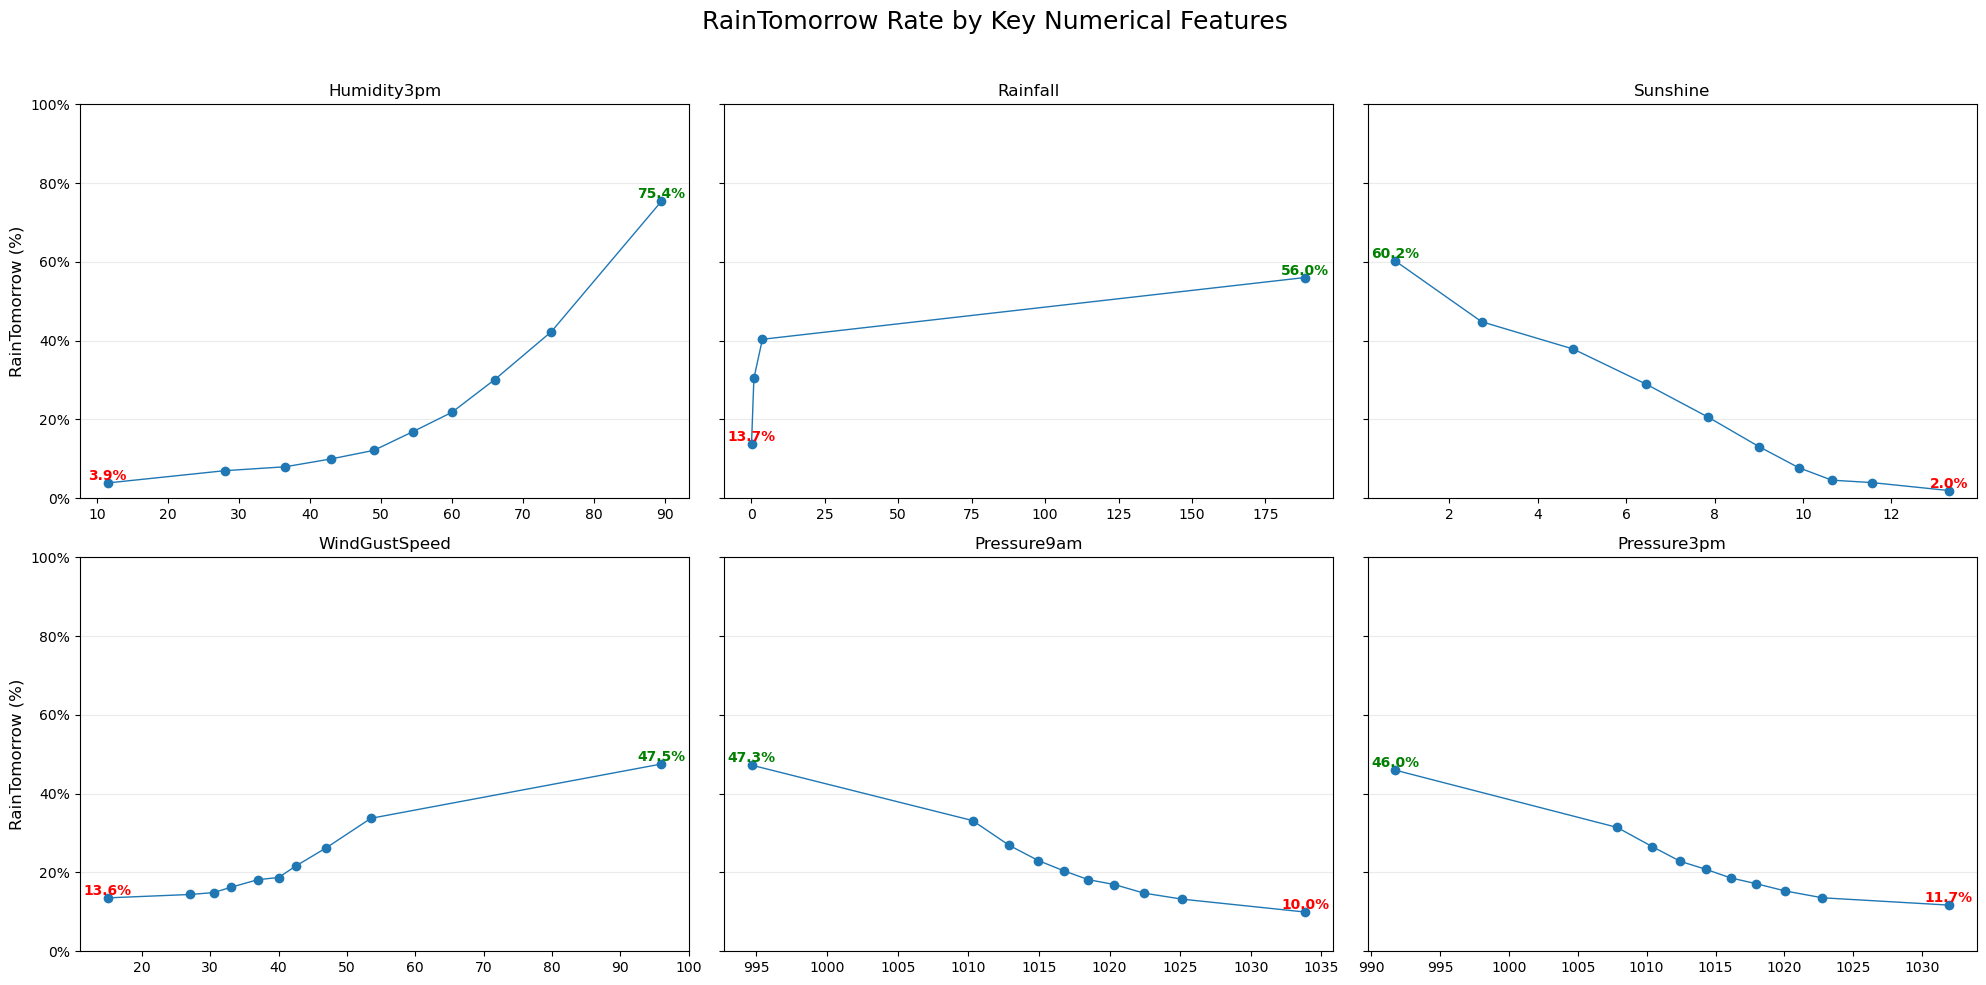

In [61]:
# ============================
# Selected key numerical predictors
# ============================
# These six variables are chosen based on meteorological relevance
# and prior knowledge about their relationship with rainfall.
TOP6_NUM_FEATURES = [
    "Humidity3pm",     # Afternoon humidity often directly precedes rainfall
    "Rainfall",        # Accumulated rainfall; strong and often zero-inflated signal
    "Sunshine",        # Inversely related to cloud cover and precipitation
    "WindGustSpeed",   # High gusts often accompany weather fronts
    "Pressure9am",     # Morning pressure reflects large-scale systems
    "Pressure3pm",     # Afternoon pressure captures short-term dynamics
]

# Binary target variable: whether it rains tomorrow (0 = No, 1 = Yes)
target_col = "RainTomorrow_bin"

# Number of quantile bins (deciles) used for each numeric feature
q = 10


# ============================
# Create subplot grid
# ============================
# A 2×3 grid is used to display all six features simultaneously.
# Sharing the y-axis ensures rain probabilities are directly comparable.
fig, axes = plt.subplots(2, 3, figsize=(20, 10), sharey=True)

# Flatten the axes array to allow simple iteration
axes = axes.flatten()


# ============================
# Loop through each feature
# ============================
for ax, feat in zip(axes, TOP6_NUM_FEATURES):

    # ============================
    # Data selection and cleaning
    # ============================
    # Retain only the current feature and the target variable
    d = df_eda[[feat, target_col]].copy()

    # Ensure both feature and target are numeric
    d[feat] = pd.to_numeric(d[feat], errors="coerce")
    d[target_col] = pd.to_numeric(d[target_col], errors="coerce")

    # Remove rows with missing values
    d = d.dropna(subset=[feat, target_col])

    # ============================
    # Quantile binning
    # ============================
    # Divide the feature distribution into q quantile bins (deciles).
    # This balances sample sizes per bin and helps reveal non-linear patterns.
    d["bin"] = pd.qcut(d[feat], q=q, duplicates="drop")

    # ============================
    # Compute binned rain probability
    # ============================
    # The mean of the binary target equals the empirical probability
    # of rain tomorrow within each bin.
    curve = (
        d.groupby("bin")[target_col]
         .agg(count="size", rate="mean")
         .reset_index()
    )

    # Convert probability to percentage for interpretability
    curve["rate_pct"] = curve["rate"] * 100

    # Use bin midpoints as x-values to produce a smooth rate curve
    curve["x_mid"] = curve["bin"].apply(lambda iv: (iv.left + iv.right) / 2)

    # Extract x- and y-values for plotting
    x = curve["x_mid"].to_numpy()
    y = curve["rate_pct"].to_numpy()

    # ============================
    # Plot the rate curve
    # ============================
    ax.plot(x, y, marker="o", linewidth=1)
    ax.set_title(feat, fontsize=12)
    ax.grid(axis="y", alpha=0.25)

    # Fix the y-axis to 0–100% to preserve probability interpretation
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(PercentFormatter())

    # ============================
    # Annotate extreme values
    # ============================
    # Highlight the highest and lowest rain probabilities only
    # to emphasize key patterns without cluttering the plot.
    if len(y) > 0 and not np.all(np.isnan(y)):
        i_min = int(np.nanargmin(y))
        i_max = int(np.nanargmax(y))

        # Highest probability → green
        ax.text(
            x[i_max],
            y[i_max],
            f"{y[i_max]:.1f}%",
            color="green",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

        # Lowest probability → red
        ax.text(
            x[i_min],
            y[i_min],
            f"{y[i_min]:.1f}%",
            color="red",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

# ============================
# Shared labels and title
# ============================
# Label only the left column to avoid redundancy
axes[0].set_ylabel("RainTomorrow (%)", fontsize=12)
axes[3].set_ylabel("RainTomorrow (%)", fontsize=12)

# Add a global title describing the purpose of the figure
fig.suptitle("RainTomorrow Rate by Key Numerical Features", fontsize=18)

# Adjust layout so subplot titles and the global title do not overlap
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Render the figure
plt.show()

### Correlation Analysis
Finally different correlation measures were considered, namely Pearson, Spearman, and Kendall correlation coefficients. Pearson correlation was selected as the primary measure because the variables represent continuous physical quantities and the analysis focuses on identifying linear relationships . Spearman and Kendall correlations were evaluated as robustness checks, as they are less sensitive to outliers and capture monotonic associations. However, their rank-based nature reduces interpretability in terms of comparability across variables. The consistency of the observed correlation patterns across all three measures supports the use of Pearson correlation in the exploratory phase.

In [62]:
# Select numerical features for correlation analysis.
# The chosen variables represent key meteorological measurements relevant for temperature, moisture, wind, pressure, and radiation.
cols_for_corr = [
    "MinTemp", "MaxTemp", "Rainfall", "Evaporation",
    "Sunshine", "WindGustSpeed", "WindSpeed9am", "WindSpeed3pm",
    "Humidity9am", "Humidity3pm", "Pressure9am", "Pressure3pm",
    "Cloud9am", "Cloud3pm",
]

# Subset the EDA dataframe to the selected numerical features.
df_corr = df_eda[cols_for_corr]


# Computes Pearson correlation to assess linear relationships between continuous meteorological variables.
corr_pearson = df_corr.corr(method="pearson")

# Computes Spearman correlation as a robustness check, capturing monotonic (rank-based) relationships and reducing sensitivity to outliers.
corr_spearman = df_corr.corr(method="spearman")

# Compute Kendall correlation as an additional robustness measure, based on concordant and discordant rank pairs.
corr_kendall = df_corr.corr(method="kendall")

<Axes: title={'center': 'Pearson Correlation'}>

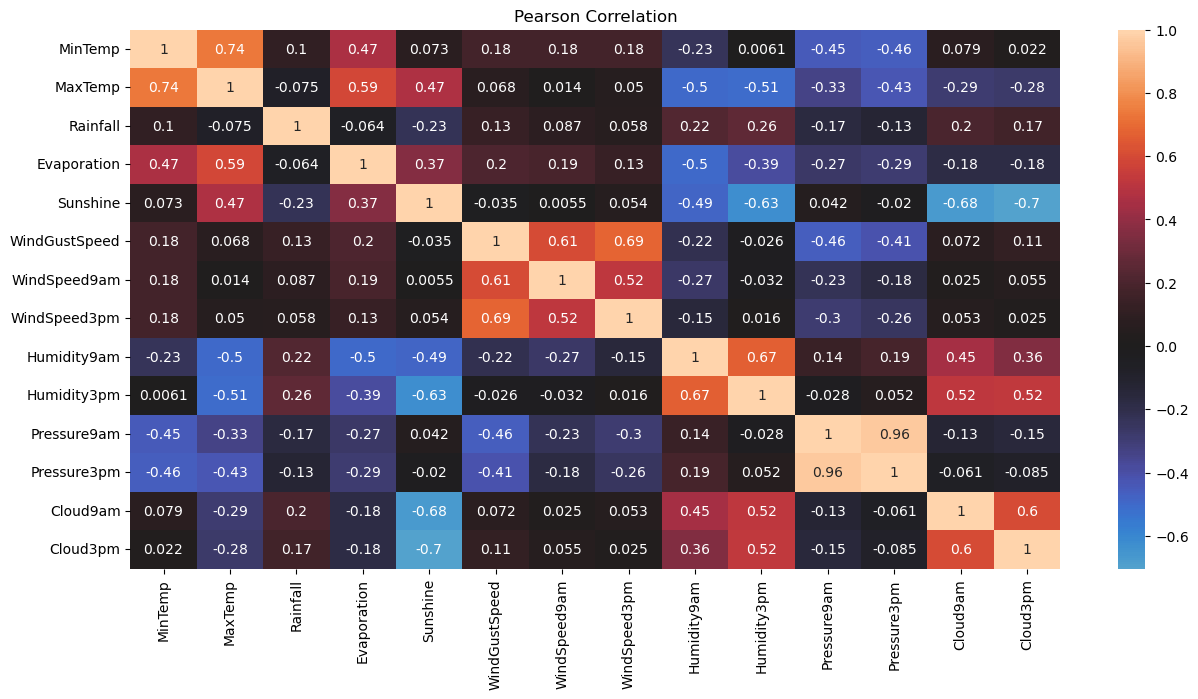

In [63]:
fig, axes = plt.subplots(figsize=(15,7))
axes.set_title("Pearson Correlation")
sns.heatmap(corr_pearson, annot=True, center=0)

The heatmap reveals strong and positive within-group correlations, such as between temperature variables, wind-related measures, and pressure at different times of day, indicating obvious internal consistency of these groups. In contrast, moisture-related variables, such as humidity and cloud show negative correlations with sunshine and pressure, highlighting atmospheric patterns that are particularly relevant for rainfall-related processes.

The consistency of correlation patterns across Pearson, Spearman, and Kendall coefficients indicates that the observed relationships are robust and not driven by outliers or non-linear effects. For completion, Spearman and Kendall are listed combined.

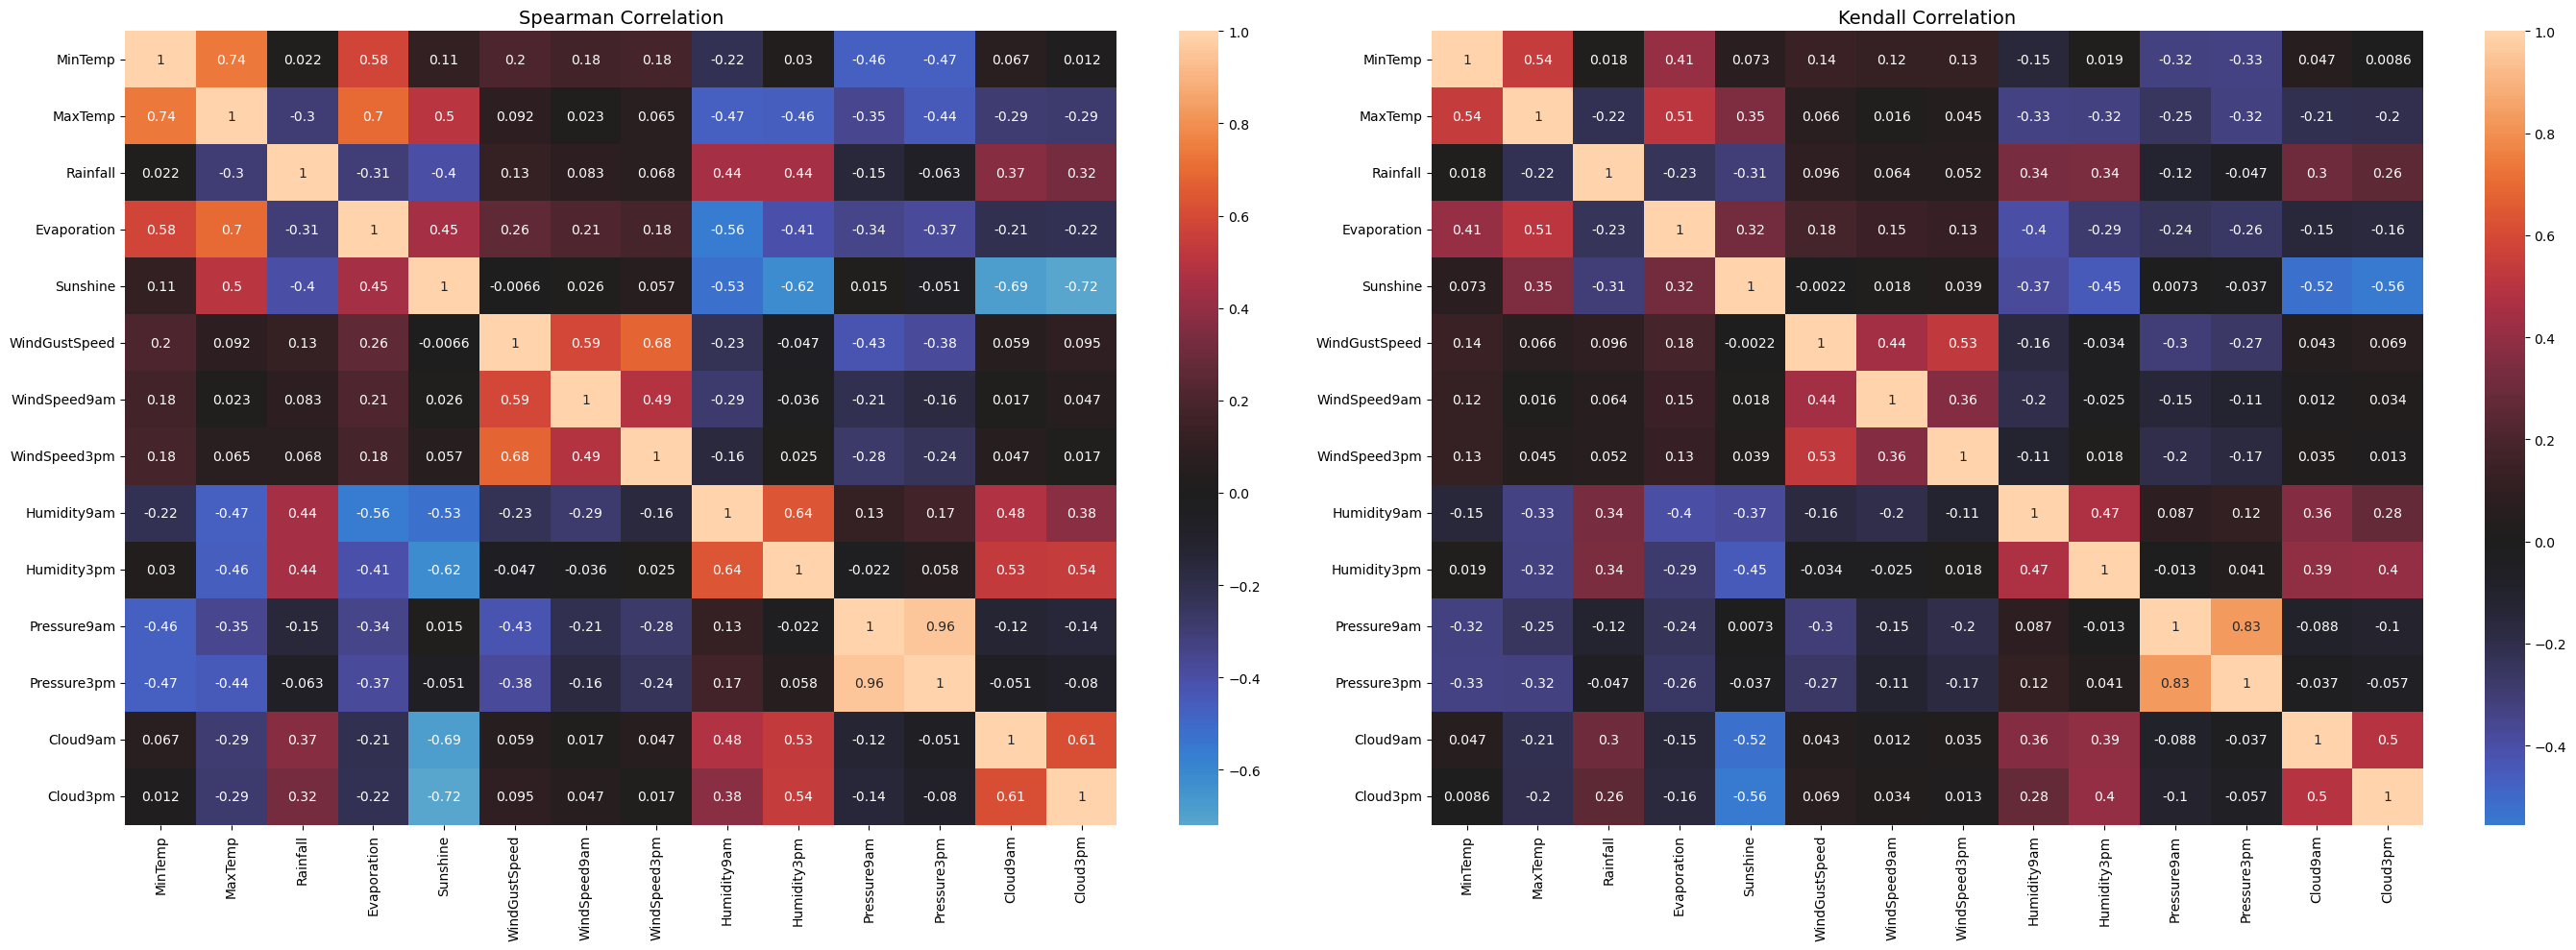

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(28, 10))

# Spearman
sns.heatmap(corr_spearman, annot=True, ax=axes[0], center=0)
axes[0].set_title("Spearman Correlation", fontsize=14)

# Kendall
sns.heatmap(corr_kendall, annot=True, ax=axes[1], center=0)
axes[1].set_title("Kendall Correlation", fontsize=14)

plt.tight_layout()
plt.show()

<a id='section4'></a>
## 4. Data Preprocessing


Contributors:
* Xinyi Li, Matriculation Number: 3814492
* Aissata Kane, Matriculation Number: 3812551

### 4.1 Experiments

#### Data Loading

In [65]:
# Reloading Data
df = pd.read_csv('weatherAUS.csv')

# Converting date to datetime format
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.weekday
df = df.drop(columns=["Date"])

# Converting Cloud columns to object data types
df[['Cloud9am', 'Cloud3pm']] = df[['Cloud9am', 'Cloud3pm']].astype('object')

# Dropping rows with missing target values
df = df.dropna(subset=['RainTomorrow']).copy()

# Detect nominal features with high-cardinality
HIGH_CARDINALITY_THRESHOLD = 10
high_card_features = [
    (col, df[col].nunique())
    for col in nominal_categorical_features
    if df[col].nunique() > HIGH_CARDINALITY_THRESHOLD
]

# Separate low/high-cardinality nominal columns
low_card_features = [col for col in categorical_features if col not in [c for c, _ in high_card_features]]
high_card_features_names = [col for col, _ in high_card_features]

print("High-cardinality features:", high_card_features_names)
print("Low-cardinality features: ",low_card_features)

High-cardinality features: ['WindDir9am', 'WindDir3pm', 'WindGustDir', 'Location']
Low-cardinality features:  ['Cloud9am', 'Cloud3pm', 'RainToday']


#### Split Data into Training, Validation & Test Sets

In [66]:
# Dropping missing values, as it lead to better model performance in preliminary experiments
# df_clean = df.dropna().reset_index(drop=True)

# Define features matrix X and target vector y
y = df[target]
X = df.drop(columns=[target])

# First split into (train + val) and test sets - 80% (train + val), 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # or use stratify=y because target is categorical/imbalanced
)

# Then split again (train + val) into train and validation sets - 75% train, 25% val of remaining 80%
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,  # 0.25 * 0.8 = 0.2 of original data for validation
    random_state=42,
    stratify=y_train_val
)


print(f"Train size: {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Train size: 85315
Validation size: 28439
Test size: 28439


#### Encode Target

In [67]:
# Target Encoding (with index reset to avoid misalignment)

X_train = X_train.reset_index(drop=True)
X_val   = X_val.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_val   = y_val.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

# Encode the target AFTER resetting indices

def encode_target(y):
    """
    Encode target labels ('Yes'/'No') into integers (0/1).
    Returns:
        - encoded labels (NumPy array)
        - fitted LabelEncoder (so we can transform val/test consistently)
    """
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    return y_encoded, le

# Fit encoder on TRAIN ONLY (to avoid leakage)
y_train_encoded, target_encoder = encode_target(y_train)

# Apply the SAME encoder to validation and test sets
y_val_encoded  = target_encoder.transform(y_val)
y_test_encoded = target_encoder.transform(y_test)

# Confirming mapping
print("Label mapping:", dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))


Label mapping: {'No': np.int64(0), 'Yes': np.int64(1)}


#### Checking Best Imputation Streategies for Numerical Features and Outlier Management

To identify the best preprocessing strategy for our rainfall prediction task, we systematically test different combinations of **missing‑value handling** and **outlier handling**.  
We use **LightGBM with 5‑fold cross‑validation** as our evaluation engine because it is fast, stable, and handles mixed feature types well.

##### 1. Missing‑Value Strategies
We compare three approaches:

- **Mean imputation**: Numeric features are filled with their mean; categorical features use the most frequent value.
- **Mode imputation**: Numeric features use the median (robust to skew), categorical features use the mode.
- **Drop rows with missing values**: Rows containing any missing values are removed. This tests whether the dataset is large enough to tolerate dropping incomplete samples.

Each strategy is wrapped into a preprocessing pipeline that also handles:
- scaling numeric features  
- ordinal encoding  
- one‑hot encoding for low‑cardinality categories  
- target encoding for high‑cardinality categories  

##### 2. Outlier‑Handling Strategies
We evaluate four different methods for dealing with outliers in numerical features:

- **none**: No outlier removal; baseline behavior.
- **z‑score filtering**: Rows are removed if any numeric feature exceeds a z‑score threshold (default: 3).
- **IQR capping**: Values outside the \([Q1 - 1.5·IQR, Q3 + 1.5·IQR]\) range are clipped. This preserves all rows while reducing extreme values.
- **Isolation Forest**: A model‑based anomaly detector removes rows flagged as outliers (contamination = 2%).

##### 3. Evaluation Procedure
For each combination of:
- **imputation strategy** ∈ {mean, mode, drop}  
- **outlier strategy** ∈ {none, zscore, iqr, isolation_forest}

we:
1. Apply the outlier‑handling method  
2. Apply the missing‑value strategy  
3. Build a preprocessing pipeline  
4. Train a **fast LightGBM model**  
5. Evaluate using **5‑fold cross‑validation** with `cross_val_predict`  
6. Compute the following metrics:
    - **F1 score**  
    - **Precision**  
    - **Recall**  
    - **Balanced Accuracy**  
    - **ROC‑AUC**
Each experiment returns a full metric set, allowing us to compare all preprocessing strategies fairly.

##### 4. Final Output
All results are collected into a single DataFrame:
```python
results_df
```
This table shows how each combination of:
- **Imputation method**
- **Outlier strategy**
affects model performance, helping us select the most effective preprocessing pipeline before full model training.

In [68]:
# Helper functions for outlier handling

def remove_outliers_zscore(df, features, threshold=3):
    df_clean = df.copy()
    z_scores = np.abs(stats.zscore(df_clean[features], nan_policy='omit'))
    mask = (z_scores < threshold).all(axis=1)
    return df_clean[mask]

def cap_outliers_iqr(df, features):
    df_clean = df.copy()
    for col in features:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_clean[col] = df_clean[col].clip(lower, upper)
    return df_clean

def isolation_forest_filter(df, features):
    iso = IsolationForest(contamination=0.02, random_state=42)
    mask = iso.fit_predict(df[features]) == 1
    return df[mask]

# Build preprocessing pipeline generator

def build_preprocessor(impute_strategy):
    
    # Numeric transformer
    if impute_strategy == "mean":
        num_imputer = SimpleImputer(strategy='mean')
    else:
        num_imputer = SimpleImputer(strategy='median')

    numeric_transformer = Pipeline([
        ('imputer', num_imputer),
        ('scaler', StandardScaler())
    ])

    # Ordinal transformer
    ordinal_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)) #avoid crash if unknown category
    ])

    # Low-cardinality nominal
    low_card_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    # High-cardinality nominal
    high_card_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', TargetEncoder())
    ])

    transformers = [
        ('num', numeric_transformer, numerical_features),
        ('ord', ordinal_transformer, ordinal_categorical_features)
    ]

    if low_card_features:
        transformers.append(('low_card', low_card_transformer, low_card_features))

    if high_card_features_names:
        transformers.append(('high_card', high_card_transformer, high_card_features_names))

    return ColumnTransformer(transformers=transformers)

# Experiment runner

def evaluate_strategy(X_train, y_train, impute_strategy, outlier_strategy):

    # --- Outlier handling ---
    if outlier_strategy == "none":
        X_clean = X_train.copy()
        y_clean = y_train.copy()

    elif outlier_strategy == "zscore":
        df = X_train.copy()
        df["target"] = y_train
        df = remove_outliers_zscore(df, numerical_features)
        y_clean = df["target"]
        X_clean = df.drop(columns=["target"])

    elif outlier_strategy == "iqr":
        df = X_train.copy()
        df["target"] = y_train
        df = cap_outliers_iqr(df, numerical_features)
        y_clean = df["target"]
        X_clean = df.drop(columns=["target"])

    elif outlier_strategy == "isolation_forest":
        df = X_train.copy()
        df["target"] = y_train
        df = isolation_forest_filter(df, numerical_features)
        y_clean = df["target"]
        X_clean = df.drop(columns=["target"])

    # --- Missing value handling ---
    if impute_strategy == "drop":
        df = X_clean.copy()
        df["target"] = y_clean
        df = df.dropna()
        y_clean = df["target"]
        X_clean = df.drop(columns=["target"])
        preprocessor = build_preprocessor("median")
    else:
        preprocessor = build_preprocessor(impute_strategy)
    
    fast_lgbm = LGBMClassifier(
        n_estimators=200,        # still fast, but more stable than 50
        learning_rate=0.05,     # small LR for stability
        max_depth=-1,           # let LGBM choose optimal depth
        num_leaves=31,          # default, fast and robust
        subsample=0.8,          # row sampling for speed
        colsample_bytree=0.8,   # feature sampling for speed
        n_jobs=-1,              # use all CPU cores
        random_state=42,
        force_row_wise=True # avoids feature-name checks
    )

    model = Pipeline([
        ('preprocessor', preprocessor),
        ('clf', fast_lgbm) # Faster than RandomForest
    ])

    # --- Cross-validation ---
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Only ONE cross_val_predict call
    probas = cross_val_predict(model, X_clean, y_clean, cv=cv, method="predict_proba")
    preds = (probas[:, 1] >= 0.5).astype(int)

    y_binary = y_clean

    metrics = {
        "F1": f1_score(y_binary, preds),
        "Precision": precision_score(y_binary, preds),
        "Recall": recall_score(y_binary, preds),
        "BalancedAccuracy": balanced_accuracy_score(y_binary, preds),
        "ROC_AUC": roc_auc_score(y_binary, probas[:, 1])
    }

    return metrics


# Run all experiments

imputation_methods = ["mean", "mode", "drop"]
outlier_methods = ["none", "zscore", "iqr", "isolation_forest"]

results = []

for imp in imputation_methods:
    for out in outlier_methods:
        metrics = evaluate_strategy(X_train, y_train_encoded, imp, out)
        results.append({
            "Imputation": imp,
            "Outliers": out,
            **metrics
        })

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
results_df


[LightGBM] [Info] Number of positive: 15300, number of negative: 52952
[LightGBM] [Info] Total Bins 2677
[LightGBM] [Info] Number of data points in the train set: 68252, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.224169 -> initscore=-1.241533
[LightGBM] [Info] Start training from score -1.241533
[LightGBM] [Info] Number of positive: 15301, number of negative: 52951
[LightGBM] [Info] Total Bins 2671
[LightGBM] [Info] Number of data points in the train set: 68252, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.224184 -> initscore=-1.241449
[LightGBM] [Info] Start training from score -1.241449
[LightGBM] [Info] Number of positive: 15301, number of negative: 52951
[LightGBM] [Info] Total Bins 2676
[LightGBM] [Info] Number of data points in the train set: 68252, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.224184 -> initscore=-1.241449
[LightGBM] [Info] Start training from score -1.241449
[Lig

,Imputation,Outliers,F1,Precision,Recall,BalancedAccuracy,ROC_AUC
10,drop,iqr,0.652804,0.758154,0.573161,0.760983,0.901581
8,drop,none,0.652134,0.757760,0.572352,0.760560,0.901626
1,mean,zscore,0.631798,0.749383,0.546108,0.749074,0.896656
5,mode,zscore,0.631798,0.749383,0.546108,0.749074,0.896656
4,mode,none,0.631099,0.759903,0.539632,0.745182,0.886055
11,drop,isolation_forest,0.630522,0.737536,0.550627,0.749098,0.896079
0,mean,none,0.630214,0.759098,0.538743,0.744670,0.887493
9,drop,zscore,0.628467,0.749016,0.541342,0.746983,0.896496
2,mean,iqr,0.627953,0.755757,0.537122,0.743481,0.887283
6,mode,iqr,0.627194,0.757193,0.535292,0.742846,0.885776


##### **Summary of Results**

The cross‑validation experiments show that the choice of imputation strategy has a noticeable impact on model performance, with **dropping rows containing missing values** consistently outperforming both mean and mode imputation. Because the dataset is large, removing incomplete rows does not significantly reduce training size, and it avoids introducing noise or bias from imputed values. This leads to the highest F1‑scores (≈0.65), the strongest balanced accuracy (≈0.76), and the best ROC‑AUC values (≈0.90), making it the most effective approach for this task.

Outlier handling has a smaller effect overall. Both **no outlier removal** and **IQR capping** produce similar and strong results, while **Isolation Forest consistently reduces performance**, likely because it removes legitimate extreme weather observations that are important for predicting rainfall. Mean and mode imputation behave similarly across all outlier strategies, confirming that LightGBM is robust to moderate noise in the input features.

Overall, the best preprocessing configuration for predicting *RainTomorrow* is to **drop missing rows and avoid aggressive outlier removal**, allowing the model to learn from clean, representative data without discarding meaningful variability. This combination provides the strongest generalization performance across all evaluated metrics.

With this information, we can move on to the final preprocessing pipeline: split data into training/data/test sets, encode targetand preprocess features.

<a id="split-data"></a>
### 4.2 Split Data into Test and Validation Sets

#### Preliminary Operations: Data Reloading, Feature Engineering, and High-Cardinality Categorical Feature Handling

In [69]:
# Reloading Data
df = pd.read_csv("weatherAUS.csv")
# Converting date to datetime format
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.weekday
df = df.drop(columns=["Date"])
# Converting Cloud columns to object data types
df[["Cloud9am", "Cloud3pm"]] = df[["Cloud9am", "Cloud3pm"]].astype("object")
# Dropping rows with missing target values
df = df.dropna(subset=["RainTomorrow"]).copy()

# Detect nominal features with high-cardinality
HIGH_CARDINALITY_THRESHOLD = 10
high_card_features = [
    (col, df[col].nunique())
    for col in nominal_categorical_features
    if df[col].nunique() > HIGH_CARDINALITY_THRESHOLD
]

# Separate low/high-cardinality nominal columns
low_card_features = [col for col in categorical_features if col not in [c for c, _ in high_card_features]]
high_card_features_names = [col for col, _ in high_card_features]

print("High-cardinality features:", high_card_features_names)
print("Low-cardinality features: ",low_card_features)

High-cardinality features: ['WindDir9am', 'WindDir3pm', 'WindGustDir', 'Location']
Low-cardinality features:  ['Cloud9am', 'Cloud3pm', 'RainToday']


We first reloaded and preprocessed the raw data. We used pd.read_csv('weatherAUS.csv') to load the dataset, converted Date to datetime format (with errors="coerce" to avoid errors caused by invalid dates), and extracted four time features from it, including Year, Month, Day, and Weekday, to capture possible seasonal and periodic effects. Then we dropped the original Date column to reduce redundancy. At the same time, we explicitly converted Cloud9am and Cloud3pm to the object type so that they would be treated as categorical variables and encoded as such in later steps. We also removed samples with missing target values in RainTomorrow to ensure the labels are complete for supervised learning.

Next, to avoid a very large feature space caused by One-Hot encoding on nominal categorical variables, we set a high-cardinality threshold HIGH_CARDINALITY_THRESHOLD = 10 and grouped nominal categorical features based on the number of unique values. If a feature has nunique() > 10, we treat it as a high-cardinality feature. The results show that the high-cardinality features are ['Location', 'WindGustDir', 'WindDir3pm', 'WindDir9am'], and the low-cardinality features are ['Cloud9am', 'Cloud3pm', 'RainToday']. This grouping supports our later encoding strategy. Low-cardinality features are suitable for One-Hot or ordinal encoding, while high-cardinality features are better handled with Target Encoding. In this way, we can control the feature dimension while keeping useful information, and also improve training efficiency and model stability.

#### Splitting data

In [70]:
# Dropping missing values, as it lead to better model performance in preliminary experiments
df_clean = df.dropna().reset_index(drop=True)

# Define features matrix X and target vector y
y = df_clean[target]
X = df_clean.drop(columns=[target])

# First split into (train + val) and test sets - 80% (train + val), 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # or use stratify=y because target is categorical/imbalanced
)

# Then split again (train + val) into train and validation sets - 75% train, 25% val of remaining 80%
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,  # 0.25 * 0.8 = 0.2 of original data for validation
    random_state=42,
    stratify=y_train_val
)


print(f"Train size: {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Train size: 33852
Validation size: 11284
Test size: 11284


Before splitting the data, we chose a drop-missing strategy based on our pilot results. We applied df.dropna() to the full dataset and reset the index (reset_index(drop=True)) to obtain a clean dataset df_clean without missing values. Then we extracted the target variable RainTomorrow as the label vector y, and used all remaining columns as the feature matrix X.

For dataset splitting, we used a two-step stratified split to handle the class imbalance issue. In the first step, we split the data into 80% (train+val) and 20% (test), where test_size = 0.2 and stratify = y ensure that the “rain / no rain” ratio in the training and test sets is consistent with the overall dataset. We also set random_state = 42 for reproducibility. In the second step, we further split the 80% train+val part into 75% (train) and 25% (validation), which correspond to 60% / 20% of the original dataset. We again used stratify = y_train_val to keep the class ratio stable.

Finally, the dataset sizes are Train = 33,852, Validation = 11,284, and Test = 11,284. This splitting strategy keeps training, tuning, and final generalization evaluation independent, and stratified sampling improves the reliability of evaluation under an imbalanced classification setting.

### 4.2 Encoding Target

In [71]:
# Target Encoding (with index reset to avoid misalignment)

# ⚠️ IMPORTANT:
# After train/val/test split, X and y keep their original dataframe indices.
# Example:
#   X_train.index → [5, 7, 10, 11, ...]
#   y_train.index → [5, 7, 10, 11, ...]
#
# But when we encode y using LabelEncoder, it becomes a NumPy array:
#   y_train_encoded → [0, 1, 0, 0, ...]
#
# NumPy arrays do NOT keep the original indices.
# This causes X and y to become MISALIGNED during cross‑validation.
# Models then learn from the wrong labels → predict only zeros → F1 = NaN.
#
# ✔ Fix: reset indices BEFORE encoding so X and y stay aligned by position.

X_train = X_train.reset_index(drop=True)
X_val   = X_val.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_val   = y_val.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

# Encode the target AFTER resetting indices

def encode_target(y):
    """
    Encode target labels ('Yes'/'No') into integers (0/1).
    Returns:
        - encoded labels (NumPy array)
        - fitted LabelEncoder (so we can transform val/test consistently)
    """
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    return y_encoded, le

# Fit encoder on TRAIN ONLY (to avoid leakage)
y_train_encoded, target_encoder = encode_target(y_train)

# Apply the SAME encoder to validation and test sets
y_val_encoded  = target_encoder.transform(y_val)
y_test_encoded = target_encoder.transform(y_test)

# Optional sanity check: confirm mapping
print("Label mapping:", dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))


Label mapping: {'No': np.int64(0), 'Yes': np.int64(1)}


After splitting the dataset into training, validation, and test sets, we first applied reset_index(drop=True) to X_train, X_val, X_test and the corresponding y_train, y_val, y_test. This ensures that features and labels stay strictly aligned by row order in later modeling steps, especially during cross-validation and operations such as cross_val_predict. This is important because pandas objects usually keep the original index after splitting, while later encoding or transformations may produce NumPy arrays without an index. If we do not reset the index, X and y can become misaligned, which may cause the model to learn incorrect labels and lead to abnormal results (for example, predicting all zeros or getting an unusual F1 score).

Next, we defined an encode_target(y) function and used LabelEncoder to convert the target labels from strings ('Yes'/'No') into binary integers (0/1). The function also returns the fitted encoder so that we can apply the same mapping to validation and test sets. To avoid information leakage, we followed the rule of fitting the encoder only on the training set. We first applied fit_transform on y_train to get y_train_encoded, and then used the same target_encoder to apply transform on y_val and y_test. This guarantees that all three sets use exactly the same encoding rule.

Finally, we printed the label mapping to check consistency. The output was {'No': 0, 'Yes': 1}, which clearly encodes “no rain” as 0 and “rain” as 1. This also provides a consistent standard for computing metrics such as F1, Precision, and Recall with the positive class defined as Yes = 1.

### 4.4 Preprocessing Pipeline

The preprocessing pipeline prepares the dataset by applying the appropriate transformations to each feature type before feeding the data into the model.  
Numeric features are standardized using **`StandardScaler`**, ensuring all continuous variables share a comparable scale.  
Ordinal categorical features are first imputed with the most frequent value and then encoded using **`OrdinalEncoder`**, which preserves their inherent ordering while safely handling unseen categories.  
Low‑cardinality nominal features are transformed with **one‑hot encoding**, creating binary indicator columns for each category.  
High‑cardinality categorical features use **target encoding**, replacing categories with their mean target value to avoid excessive dimensionality.  
All these transformations are combined using a **`ColumnTransformer`**, ensuring each feature receives the correct preprocessing step in a single, unified pipeline.

In [72]:
# --- Define transformers ---

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

ordinal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

low_card_transformer = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

high_card_transformer = Pipeline([
    ('encoder', TargetEncoder())
])

transformers = [
    ('num', numeric_transformer, numerical_features),
    ('ord', ordinal_transformer, ordinal_categorical_features)
]

if low_card_features:
    transformers.append(('low_card', low_card_transformer, low_card_features))

if high_card_features_names:
    transformers.append(('high_card', high_card_transformer, high_card_features_names))

preprocessor = ColumnTransformer(transformers=transformers)

<a id='section5'></a>
## 5. Model Selection and Hyperparameter Tuning


Contributors: Aissata Kane, Matriculation Number: 3812551

### 5.1 Models Definition

This project evaluates several machine‑learning models with different inductive biases and strengths.  
Each model brings a unique approach to handling nonlinear relationships, feature interactions, and class imbalance.  
Below is a structured overview of the selected models and how they compare.

---

**Random Forest**

Random Forest is an ensemble of decision trees trained on bootstrapped samples with random feature selection.  
It captures nonlinear relationships and complex interactions automatically, is robust to noise, and handles mixed feature types well.  
However, it can become computationally heavy with many trees and may struggle with very high‑cardinality categorical features unless encoded carefully.

**Logistic Regression**

Logistic Regression is a linear classifier that models the log‑odds of the target as a linear combination of features.  
It is fast, interpretable, and performs well when the true decision boundary is approximately linear.  
Its main limitation is that it cannot naturally capture nonlinear patterns unless feature engineering or polynomial expansions are added.

**LightGBM**

LightGBM is a gradient‑boosting framework based on decision trees, optimized for speed and performance.  
It handles nonlinearities, interactions, missing values, and large feature spaces extremely well.  
It is typically one of the strongest baseline models for tabular data and often outperforms Random Forest due to boosting’s ability to correct errors iteratively.

**Neural Network (MLP)**

A multilayer perceptron (MLP) learns hierarchical representations through stacked dense layers.  
It can approximate highly nonlinear functions but requires careful tuning, scaling, and regularization.  
On tabular data, neural networks often underperform tree‑based models unless the dataset is very large or features are highly engineered.

**Stacking Ensemble**

The stacking model combines predictions from multiple base learners (e.g., Random Forest, LightGBM, Logistic Regression) using a meta‑model such as Logistic Regression.  
This approach leverages the strengths of each model and often yields the best overall performance.  
Stacking reduces variance and bias simultaneously, making it a powerful final model when base learners are diverse.

---

**Model Comparison Table:**

| Model               | Type                     | Strengths | Weaknesses | Typical Performance on Tabular Data |
|---------------------|--------------------------|-----------|------------|--------------------------------------|
| **Random Forest**   | Bagging ensemble of trees | Robust, handles nonlinearities, low tuning effort | Can be slow with many trees, less accurate than boosting | Strong baseline |
| **Logistic Regression** | Linear classifier | Fast, interpretable, stable | Cannot model nonlinear patterns | Moderate unless data is linearly separable |
| **LightGBM**        | Gradient boosting trees | High accuracy, fast, handles missing values | Sensitive to hyperparameters | Often best single model |
| **Neural Network (MLP)** | Deep learning | Flexible, powerful for complex patterns | Requires tuning, may overfit, weaker on tabular data | Variable |
| **Stacking Ensemble** | Meta‑ensemble | Combines strengths of all models, often best | More complex, slower to train | Typically highest |

In [73]:
# Create model dictionary
models = {}

# Random Forest (classification)
models["Random Forest"] = Pipeline([
    ("preprocess", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=42))
])

# Logistic Regression
models["Logistic Regression"] = Pipeline([
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(
        max_iter=2000,
        solver='saga',
        multi_class='multinomial',
        C=1.0,
        random_state=42
    ))
])

# LightGBM
models["LightGBM"] = Pipeline([
    ("preprocess", preprocessor),
    ("clf", LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=42
    ))
])

# Deep Learning Model (MLPClassifier)
models["Neural Network (MLP)"] = Pipeline([
    ("preprocess", preprocessor),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=0.001,
        max_iter=50,              # keep small for speed
        random_state=42
    ))
])

# Ensemble Model (Stacking)
stack_estimators = [
    ("rf", RandomForestClassifier(n_estimators=150, random_state=42)),
    ("lgbm", LGBMClassifier(n_estimators=150, learning_rate=0.05, random_state=42)),
]

models["Stacking Ensemble"] = Pipeline([
    ("preprocess", preprocessor),
    ("clf", StackingClassifier(
        estimators=stack_estimators,
        final_estimator=LogisticRegression(max_iter=2000),
        n_jobs=-1
    ))
])


### 5.2 Model Hyperparameter Tuning

To maximize model performance, we tune **hyperparameters**—settings such as the number of trees, learning rate, or neural‑network layer sizes. These values are not learned from the data but have a major impact on predictive accuracy, especially for a task like rainfall forecasting.

We first define a hyperparameter grid comprising every combination of hyperparameters we wish to test.

In [74]:
# ---------------------- Hyperparameter grids ----------------------
param_grids = {
    # Random Forest
    "Random Forest": {
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [10, 20, None],
        "clf__max_features": ["sqrt", "log2"],
        "clf__min_samples_split": [2, 5],
        "clf__min_samples_leaf": [1, 3]
    },

    # LightGBM
    "LightGBM": {
        "clf__n_estimators": [100, 200],
        "clf__learning_rate": [0.05, 0.1],
        "clf__num_leaves": [20, 31, 50],
        "clf__max_depth": [-1, 5, 10],
        "clf__subsample": [0.7, 0.9],
        "clf__colsample_bytree": [0.7, 0.9]
    },

    # Logistic Regression
    "Logistic Regression": {
        "clf__C": [0.1, 1, 3],
        "clf__penalty": ["l2"],
        "clf__solver": ["saga"],
        "clf__max_iter": [2000]
    },

    # Neural Network (MLP)
    "Neural Network (MLP)": {
        "clf__hidden_layer_sizes": [(64, 32), (128, 64)],
        "clf__activation": ["relu"],
        "clf__alpha": [1e-4, 1e-3],
        "clf__learning_rate_init": [0.001, 0.01],
        "clf__max_iter": [50]   # keep small for speed
    },

    # Stacking Ensemble
    "Stacking Ensemble": {
        # Only tune the final estimator to keep runtime reasonable
        "clf__final_estimator__C": [0.1, 1, 3],
        "clf__final_estimator__penalty": ["l2"]
    }
}


We use **Randomized Search** because it is more efficient than Grid Search. Instead of exhaustively testing every combination, it samples a limited number of random configurations, making it:

- **Efficient:** much faster than full grid search  
- **Effective:** quickly identifies promising parameter regions  
- **Scalable:** works well even when models have many hyperparameters  

This approach delivers strong performance without unnecessary computation.

**Implementation Details:**

For each model, we defined a hyperparameter search space and ran RandomizedSearchCV with:

- 10 sampled combinations (`n_iter=10`)  
- 5‑fold cross‑validation (`cv=5`)  
- F1 score as the optimization metric, focusing on the positive class *“Rain Tomorrow = Yes”*  
- Parallel processing to speed up evaluation  

Randomized Search trains the model multiple times with different hyperparameter sets, evaluates each using cross‑validation, and selects the configuration that achieves the highest F1 score.

In [ ]:
# ---------------------- Hyperparameter tuning ----------------------

# F1 scorer for the positive class ("Yes" encoded as 1)
f1_scorer = make_scorer(
    f1_score,
    pos_label=1,
    zero_division=0
)

best_models = {}
best_params = {}          # <--- store raw best params
clean_best_params = {}    # <--- store only clf__ parameters
cv_results = []

for name, pipeline in models.items():
    print(f"\n--- Tuning {name} ---")

    param_grid = param_grids.get(name, {})

    if not param_grid:
        print(f"No hyperparameter grid defined for {name}, skipping.")
        continue

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grid,
        n_iter=10,
        scoring=f1_scorer,
        cv=5,
        verbose=1,
        n_jobs=-1,
        random_state=42
    )

    search.fit(X_train, y_train_encoded)

    # Store tuned model
    best_models[name] = search.best_estimator_

    # Store raw best params
    best_params[name] = search.best_params_

    # Extract only classifier parameters (remove preprocess params)
    clean_best_params[name] = {
        k.replace("clf__", ""): v
        for k, v in search.best_params_.items()
        if k.startswith("clf__")
    }

    print(f"Best params for {name}: {search.best_params_}")
    print(f"Best CV F1 for {name}: {search.best_score_:.4f}")

    # Evaluate on validation set
    y_pred_val = search.predict(X_val)

    metrics = evaluate_model(
        model_name=name,
        y_true=y_val_encoded,
        y_pred=y_pred_val,
    )

    cv_results.append(metrics)


--- Tuning Random Forest ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params for Random Forest: {'clf__n_estimators': 200, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_features': 'log2', 'clf__max_depth': None}
Best CV F1 for Random Forest: 0.6195

--- Tuning Logistic Regression ---
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best params for Logistic Regression: {'clf__solver': 'saga', 'clf__penalty': 'l2', 'clf__max_iter': 2000, 'clf__C': 0.1}
Best CV F1 for Logistic Regression: 0.6193

--- Tuning LightGBM ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [ ]:
cv_results_df = pd.DataFrame(cv_results).sort_values("F1", ascending=False)
cv_results_df

In [ ]:
# Create a clean DataFrame of best classifier parameters for each model
clean_params_df = pd.DataFrame([
    {"Model": model_name, **params}
    for model_name, params in clean_best_params.items()
])

# Create one DataFrame per model
model_param_dfs = {}

for model_name, params in clean_best_params.items():
    df = pd.DataFrame.from_dict(params, orient="index", columns=["Value"])
    df.index.name = "Parameter"
    model_param_dfs[model_name] = df

# Print best hyperparameters for each model
for model_name, df in model_param_dfs.items():
    print(f"\n--- Best Hyperparameters for {model_name} ---")
    print(df)

<a id='section6'></a>
## 6. Final Models Training & Evaluation

Contributors: Aissata Kane, Matriculation Number: 3812551

In [ ]:
# ---------------------- Retrain all best models on train + val ----------------------

X_train_val = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_train_val_encoded = np.concatenate([y_train_encoded, y_val_encoded])

final_test_results = []

for name, model in best_models.items():
    print(f"\n=== Retraining {name} on train + val ===")
    
    # Fit model on combined training data
    model.fit(X_train_val, y_train_val_encoded)
    
    # Evaluate on test set
    y_pred_test = model.predict(X_test)
    
    metrics = evaluate_model(
        model_name=name,
        y_true=y_test_encoded,
        y_pred=y_pred_test
    )
    
    final_test_results.append(metrics)


In [ ]:
final_results_df = pd.DataFrame(final_test_results).sort_values("F1", ascending=False)
final_results_df

The final evaluation shows that all models achieve reasonably strong performance, but with different strengths depending on the metric.
- The **Stacking Ensemble** delivers the best overall F1 score (0.651), indicating the most balanced trade‑off between precision and recall.
- The **Neural Network (MLP)** performs almost identically in F1 but achieves the highest recall (0.642) and the strongest balanced accuracy (0.774), meaning it detects positive rainfall cases more effectively.
- **LightGBM** also performs competitively, with high precision (0.760) and a solid F1 score, making it a reliable single‑model alternative.
- **Random Forest** and **Logistic Regression** trail slightly behind, with lower recall and F1 scores, though both maintain strong precision.

Overall, the ensemble approach provides the most robust performance, while the MLP offers the best sensitivity to positive cases.

<a id='section7'></a>
## 7. Feature Importance / Explainability


Contributors: Xinyi Li, Matriculation Number: 3814492

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, f1_score
import pandas as pd
import matplotlib.pyplot as plt

# Scorer for permutation importance
f1_scorer = make_scorer(f1_score, pos_label=1, zero_division=0)

# Dictionary to store importance results for each model
all_importances = {}

for name, model in best_models.items():
    print(f"\n=== Permutation Importance for {name} ===")

    # Compute permutation importance on the TEST set
    perm = permutation_importance(
        estimator=model,          # full pipeline (preprocessing + model)
        X=X_test,
        y=y_test_encoded,
        scoring=f1_scorer,
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )

    # Convert to DataFrame
    fi_df = pd.DataFrame({
        "Feature": X_test.columns,
        "Importance_Mean": perm.importances_mean,
        "Importance_Std": perm.importances_std
    }).sort_values("Importance_Mean", ascending=False)

    all_importances[name] = fi_df

    print(fi_df.head(15))

    # Plot Top-15 features
    import matplotlib.pyplot as plt
    import numpy as np

    top_k = 10

    # Use a rainbow-style colormap
    cmap = plt.cm.rainbow   # or plt.cm.gist_rainbow
    colors = cmap(np.linspace(0, 1, top_k))

    plt.figure(figsize=(8, 6))

    plt.barh(
        fi_df["Feature"].head(top_k)[::-1],
        fi_df["Importance_Mean"].head(top_k)[::-1],
        color=colors[::-1]   # reverse so colors match feature order
    )

    plt.xlabel("Permutation Importance (ΔF1)")
    plt.ylabel("Feature")
    plt.title(f"Top {top_k} Feature Importances for {name} (Permutation, Test Set)")
    plt.tight_layout()
    plt.show()

#### **Model choice**
The key idea of Permutation Importance is: on the test set, we randomly shuffle one feature column (so the link between this feature and the target is broken), and then we observe how much the model performance drops (in this study, we use F1 for the positive class). A larger drop means the model depends more on this feature, so the feature is more important. This method works on the full Pipeline, so it can output feature importance for the original feature columns while keeping preprocessing consistent. This makes the results easier to interpret and compare.

#### **Experiment setup**
We use the test set for evaluation and use the 5 models that are retrained on Train + Val. Since “rain tomorrow” is usually the minority class, F1 can better reflect the detection quality for rainy days, so we use ΔF1 as the evaluation metric. We set n_repeats = 10. For each feature, we repeat the permutation 10 times and take the average to reduce fluctuations caused by randomness.

#### **Result analysis**
Across all five models, the feature-importance patterns are highly consistent. Humidity3pm is always the most critical predictor: once we permute this feature, the model’s F1 drops sharply. The next most important variables are typically Pressure3pm, Sunshine, WindGustSpeed, and Cloud3pm. This indicates that regardless of the modeling approach, predicting RainTomorrow relies on the same core weather signals—how moist the air is, how the pressure system evolves, how much sunshine and cloud cover there is, and how strong the winds are. This is also intuitively consistent: higher humidity, more pronounced pressure changes, heavier cloud cover with less sunshine, and stronger winds are all conditions that are often associated with rainfall.

The main differences across models lie in how they use these signals. Logistic Regression and MLP tend to rely more heavily on a small set of strong predictors (especially pressure), which makes Pressure3pm appear particularly influential for these models. In contrast, tree-based models such as Random Forest and LightGBM split decisions into many conditional rules, so the same underlying pattern can be represented by multiple correlated features; as a result, importance tends to be more dispersed or partially substitutable across top variables. Stacking effectively combines the information learned by Random Forest and LightGBM, so its importance ranking often reflects a compromise between the two.

Finally, time features such as Month/Day/Weekday have near-zero importance in some models, suggesting that the seasonal or calendar information they provide is largely captured indirectly by meteorological variables (e.g., temperature, humidity, and sunshine), and therefore adds limited additional predictive value.

The figure for Stacking shows the top 15 features by permutation importance on the test set. Humidity3pm is much more important than all other variables. This means that shuffling only the Humidity3pm column causes the model’s F1 to drop by about 0.20 on average. It shows that the model strongly depends on “humidity at 3 pm” to predict the probability of rain on the next day. From a meteorology view, humidity directly reflects the amount of water vapor. Humidity in the afternoon can reflect cloud and rain development later in the day and how close the air is to saturation, so it provides a strong signal for predicting next-day rainfall.

Sunshine, WindGustSpeed, and Pressure3pm have clear predictive value for RainTomorrow because they capture complementary background conditions for rainfall formation from different angles. Lower Sunshine typically indicates thicker cloud cover and weaker solar radiation, which often corresponds to a more humid or unstable atmospheric setup and therefore a higher likelihood of subsequent rainfall. WindGustSpeed reflects the strength of the wind field and the activity of weather systems; stronger gusts are often associated with fronts, low-pressure systems, or convective activity, signaling stronger disturbances and moisture transport that can precede rainfall. Pressure3pm provides a broader “synoptic background” signal: lower pressure levels or pronounced pressure changes are commonly linked to rising air and unstable conditions that favor cloud development and precipitation. As a result, permuting these three variables leads to a noticeable drop in F1, indicating that they provide important and mutually complementary information for predicting next-day rainfall.

A third group of features Cloud3pm, Rainfall, and Location—shows medium but clearly non-zero importance, meaning these variables still contribute meaningfully to predictive performance. Cloud3pm directly describes cloud cover and is closely connected to precipitation formation. Rainfall represents today’s rain amount and can serve as persistence information: if it rains today, the likelihood of rain tomorrow often increases. Finally, Location is encoded using Target Encoding into a continuous value that reflects the historical rain tendency of each region, capturing geographic climate differences (e.g., coastal vs. inland areas). As a result, Location provides a stable performance gain even though it is not as dominant as the key meteorological variables above.
#### **Robustness analysis**
The standard deviation of importance for the top features is generally small (about 0.001 to 0.005). This shows that under 10 repeated permutations, the importance estimates are stable, so the conclusions are reliable. In particular, Humidity3pm, Sunshine, and Pressure3pm have both high mean importance and low variation, which suggests they contribute consistently and robustly to the model’s predictions.

<a id='section8'></a>
## 8. Conclusions & Next Steps

Contributors: Xinyi Li, Matriculation Number: 3814492

#### **Summary of overall process**
This project builds a binary classification framework to predict RainTomorrow (whether it will rain tomorrow) based on historical weather observations in Australia. The overall workflow has five stages: **EDA** → **data processing and feature engineering** → **modeling and tuning** → **final evaluation** → **interpretability analysis**.
##### 1.**EDA**
In the EDA stage, we systematically checked data quality and distribution patterns, including the class ratio of the target, missing value patterns, distributions and skewness of key weather features (such as humidity, pressure, sunshine, and rainfall), relationships between variables and the target, and differences across categorical features such as Location. The main EDA findings guided later modeling. For example, the dataset has clear missing values (especially in some weather variables), so we needed a clear missing-value strategy. The target class (**RainTomorrow**) is somewhat imbalanced, so evaluation should focus on **F1, Recall, and Balanced Accuracy**. Variables like humidity, pressure, sunshine, and cloud cover are strongly related to rainfall. Location reflects regional climate differences and is a high-cardinality categorical feature, so it needs proper encoding.
##### 2.**Data cleaning and feature engineering**
After loading the data, we decomposed the date into time features such as **Year, Month, Day, and Weekday**. We set cloud-related variables as categorical features and removed samples with missing target values. Then we identified high-cardinality categorical features (such as Location and wind directions) and low-cardinality categorical features (such as RainToday and some cloud-related variables), and designed the encoding strategy based on this.
##### 3.**Data splitting and target encoding**
We used stratified sampling to split the data into **Train, Validation, and Test sets**. Before target encoding, we reset the index to avoid misalignment between features and labels during cross-validation, which helps ensure reliable evaluation.
##### 4.**Preprocessing pipeline and model comparison**
We built a unified preprocessing pipeline using **Pipeline + ColumnTransformer**, including numeric standardization, One-Hot encoding for low-cardinality features, Target Encoding for high-cardinality features, and ordinal encoding for ordered categorical variables. Under this unified input setting, we trained and compared several models, including **Random Forest, Logistic Regression, LightGBM, MLP, and Stacking**.
##### 5.**Hyperparameter tuning, final training, and test evaluation**
We used RandomizedSearchCV (5-fold cross-validation, optimizing positive-class F1) for tuning and selected the best model based on validation results. The final model is **Stacking**. After retraining it on the combined Train+Val data, we achieved the following results on the test set: **F1 = 0.651, Precision = 0.757, Recall = 0.571, and Balanced Accuracy = 0.759**.
##### 6.**Interpretability analysis**
On the test set, we used permutation importance (ΔF1) to evaluate feature importance. The results show that **Humidity3pm, Sunshine,WindgustSpeed and Pressure3pm** are the most important features, and this is consistent with the weather patterns observed in the EDA stage.

#### **What worked well**
##### 1.**EDA guided our modeling decisions like a “navigation tool”**
EDA helped us identify the main challenges in the data, including missing values, class imbalance, and high-cardinality categorical features. It also highlighted strong signal variables such as humidity, pressure, sunshine, and cloud cover. Based on these findings, we made several key decisions. We used a more robust missing-value strategy (finally choosing dropna or a robust imputation approach). We focused on metrics that fit imbalanced data better, such as positive-class F1 and Balanced Accuracy. We also applied Target Encoding to high-cardinality features like Location to avoid a large feature space caused by One-Hot encoding.

##### 2.**Stacking performed best on this tabular task and generalized well**
After hyperparameter tuning, Stacking achieved the highest cross-validation F1 score, and its test performance stayed at a similar level (F1 about 0.651). This suggests the model is stable and works well on unseen data.

##### 3.**A unified preprocessing Pipeline improved fairness, reproducibility, and reduced leakage risk**
By wrapping preprocessing and the model into one Pipeline, we ensured that cross-validation and test evaluation followed the same process. This reduces bias caused by manual differences and also lowers the risk of data leakage.

##### 4.**Interpretability results matched the EDA observations and increased trust in the model**
Permutation importance shows that Humidity3pm (ΔF1 about 0.196) is the most important feature by a large margin, followed by Sunshine and Pressure3pm. This is consistent with the EDA findings that humidity, pressure, and sunshine are strongly related to rainfall. This agreement suggests the model learned reasonable patterns and makes the results more trustworthy.

#### **Project limitations and improvements**
##### 1.**Class imbalance still limits Recall**
Although Precision is high (0.757), Recall is 0.571. This means the model still misses some rainy days. In risk-sensitive settings, this may require further improvement. 

**Action**: Add imbalance handling in LightGBM, such as scale_pos_weight = (#negative / #positive) or is_unbalance = True, to increase the learning focus on the positive class.

##### 2.**Random splitting may underestimate the difficulty of time generalization**
Weather data has clear seasonality and time dependence. A random split may make the training and test sets too similar, so the evaluation can be too optimistic.  

**Action**: Use TimeSeriesSplit for cross-validation and report performance changes across different time folds. Maybe can also add seasonal feature interactions (such as Month × Location) and check whether they improve stability across years.

##### 3.**Permutation importance alone cannot explain the direction of effects**
Permutation importance can show whether a feature is important, but it cannot directly tell whether a higher feature value increases or decreases the rain probability. Also, correlated features can replace each other, which may make importance values look smaller.  

**Action**: Add SHAP analysis (both global and local) to provide direction and contribution explanations.